# Hogescholen Content Project
# 
## Clustering Study Programmes
#### Maastricht University | School of Business and Economics | The Research Centre for Education and the Labour Market (ROA)
##
### Group:
#### Laurence Nickel, M.Sc. (ROA | laurence.nickel@maastrichtuniversity.nl)
#### Dr. Barbara Belfi (ROA | b.belfi@maastrichtuniversity.nl) 
#### Dr. Zsuzsa Bakk (Leiden University | z.bakk@fsw.leidenuniv.nl) 
<br></br>

__Libraries used:__ 
* argostranslate (version: '1.9.6')
* collections (version: '3.12.5')
* importlib (version: '3.12.5')
* json (version: '3.12.5')
* math (version: '3.12.5')
* gensim (version: '4.3.3')
* joblib (version: '1.5.1')
* matplotlib (version: '3.10.3')
* networkx (version: '3.5')
* nltk (version: '3.9.1')
* numpy (version: '1.26.4')
* os (version: '3.12.5') 
* pandas (version: '2.3.0')
* plotly (version: '6.1.2')
* pyreadstat (version: '1.3.0')
* random (version: '3.12.5')
* re (version: '3.12.5')
* scipy (version: '1.13.1')
* seaborn (version: '0.13.2')
* sentence_transformers (version: '4.1.0')
* sklearn (version: '1.7.0')
* spacy (version: '3.8.7')
* spellchecker (version: '0.8.3')
* subprocess (version: '3.12.5')
* sys (version: '3.12.5')
* torch (version: '2.7.1') 
* warnings (version: '3.12.5')
<br></br>

__Literature:__  
[1] fastText (2022). English word vectors - wiki-news-300d-1M.vec.zip. Available: https://fasttext.cc/docs/en/english-vectors.html (last accessed: 24 June 2025).<br></br>
[2] Argos Open Tech (2025). Argos Translate Package Index - translate-nl_en-1_8.argosmodel. Available: https://www.argosopentech.com/argospm/index/ (last accessed: 24 June 2025). <br></br>
[3] Argos Open Tech (2025). Argos Translate Package Index - translate-en_nl-1_8.argosmodel. Available: https://www.argosopentech.com/argospm/index/ (last accessed: 24 June 2025). <br></br>
[4] Dienst Uitvoering Onderwijs (2024). HO Erkenningen CROHO - CrohoActueel14-10-2024.xlsx. Available: https://onderwijsdata.duo.nl/datasets/overzicht-erkenningen-ho/resources/28a4d89b-c223-4dbc-8deb-9d02a533f215 (last accessed: 17 October 2024).<br></br>
[5] Centraal Bureau voor de Statistiek (2025). Beroepenclassificatie (ISCO en SBC) - codelijstenisco08.xlsx. Available: https://www.cbs.nl/nl-nl/onze-diensten/methoden/classificaties/onderwijs-en-beroepen/beroepenclassificatie--isco-en-sbc-- (last accessed: 9 July 2025).<br></br>
<br></br><br></br><br></br>

<br></br><br></br><br></br>

## 
## Importing Libraries

In [1]:
print("Starting the importing of the libraries...\n")


# Installing the library 'numpy' by choosing a version that is compatible with other packages.
import numpy as np
np.random.seed(42)


# Importing libraries that have tight numpy version requirements.
import scipy
import scipy.stats as stats
from scipy.stats import entropy
import gensim
import gensim.downloader as api
from gensim import corpora
from gensim.models import LdaModel, KeyedVectors
from gensim.models.coherencemodel import CoherenceModel
import torch


# Importing the library 'argostranslate' after having made sure that both the libraries 'numpy' and 'torch' are installed.
import argostranslate
import argostranslate.package
import argostranslate.translate


# Importing libraries that are themselves not directly used but are required by other libraries.
import joblib

#!pip install matplotlib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

import networkx as nx

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import openpyxl

import patsy
from patsy import build_design_matrices

import pandas as pd

import plotly
import plotly.graph_objects as go

import pyreadstat

import sklearn
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split

import seaborn as sns

# Defining colorblind-friendly plotting defaults used throughout the notebook.
COLORBLIND_CATEGORICAL_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # purple/pink
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#999999",  # grey
]
COLORBLIND_SEQUENTIAL_CMAP = "cividis"
COLORBLIND_DIVERGING_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "colorblind_blue_orange",
    ["#0072B2", "#F7F7F7", "#D55E00"]
)
sns.set_theme(style="white", palette=COLORBLIND_CATEGORICAL_PALETTE)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "#333333",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def get_colorblind_palette(num_colors):
    """Returns a reusable colorblind-friendly categorical palette."""
    return [
        COLORBLIND_CATEGORICAL_PALETTE[i % len(COLORBLIND_CATEGORICAL_PALETTE)]
        for i in range(num_colors)
    ]


def enforce_white_figure_background(fig):
    """Force manuscript figures to white backgrounds with black readable text."""
    fig.patch.set_facecolor("white")
    fig.patch.set_alpha(1)

    for ax in fig.get_axes():
        ax.set_facecolor("white")

        ax.title.set_color("black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.tick_params(axis="both", colors="black")

        for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
            tick_label.set_color("black")

        for spine in ax.spines.values():
            spine.set_color("#333333")

        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor("white")
            legend.get_frame().set_edgecolor("#333333")
            for text in legend.get_texts():
                text.set_color("black")
            title = legend.get_title()
            if title is not None:
                title.set_color("black")

        for text in ax.texts:
            text.set_color("black")

    return fig

import sentence_transformers
from sentence_transformers import SentenceTransformer, util

import spacy

import statannotations
from statannotations.Annotator import Annotator

import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols, quantreg
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

import spellchecker
from spellchecker import SpellChecker


# Importing libraries that are part of the set of base libraries that come pre-installed when Python is installed.
import collections
from collections import Counter
import importlib
from importlib.metadata import version
import itertools
from itertools import combinations
import json
import math
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["PYTHONHASHSEED"] = "42"
import random
random.seed(42)
import re
import subprocess
import sys
import warnings


# Manuscript artwork export settings.
# The PNG fallback uses the strictest stated full-page bitmap line-drawing width
# (7480 px); vector PDF copies are also written for plots/line drawings.
MANUSCRIPT_SINGLE_COLUMN_HALFTONE_WIDTH_PX = 1063
MANUSCRIPT_FULL_PAGE_HALFTONE_WIDTH_PX = 2244
MANUSCRIPT_SINGLE_COLUMN_COMBO_WIDTH_PX = 1772
MANUSCRIPT_FULL_PAGE_COMBO_WIDTH_PX = 3740
MANUSCRIPT_SINGLE_COLUMN_LINE_WIDTH_PX = 3543
MANUSCRIPT_FULL_PAGE_LINE_WIDTH_PX = 7480
MANUSCRIPT_EXPORT_MIN_WIDTH_PX = MANUSCRIPT_FULL_PAGE_LINE_WIDTH_PX
MANUSCRIPT_EXPORT_MIN_DPI = 500
MANUSCRIPT_EXPORT_FORMATS = ("png", "pdf")

def save_manuscript_figure(path, fig=None, formats=MANUSCRIPT_EXPORT_FORMATS,
                           min_width_px=MANUSCRIPT_EXPORT_MIN_WIDTH_PX,
                           min_dpi=MANUSCRIPT_EXPORT_MIN_DPI, **savefig_kwargs):
    """Save a figure as high-resolution PNG plus vector PDF for manuscript use.

    The PNG export is forced to at least ``min_width_px`` pixels wide. The default
    7480 px satisfies the stated full-page bitmap line-drawing minimum; halftone
    and line/halftone requirements are lower and are therefore also covered.
    """
    fig = fig or plt.gcf()
    enforce_white_figure_background(fig)
    path = os.fspath(path)
    output_dir = os.path.dirname(path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    base_path, _ = os.path.splitext(path)
    width_inches = max(float(fig.get_size_inches()[0]), 1.0)
    requested_dpi = savefig_kwargs.pop("dpi", None)
    computed_dpi = int(np.ceil(min_width_px / width_inches))
    raster_dpi = max(min_dpi, computed_dpi, requested_dpi or 0)

    common_kwargs = {
        "bbox_inches": "tight",
        "facecolor": "white",
    }
    common_kwargs.update(savefig_kwargs)

    written_paths = []
    for export_format in formats:
        export_format = export_format.lower().lstrip(".")
        export_path = f"{base_path}.{export_format}"
        if export_format in {"png", "jpg", "jpeg", "tif", "tiff"}:
            fig.savefig(export_path, dpi=raster_dpi, format=export_format, **common_kwargs)
            try:
                from PIL import Image
                with Image.open(export_path) as exported_image:
                    exported_width_px = exported_image.size[0]
                if exported_width_px < min_width_px:
                    adjusted_dpi = int(np.ceil(raster_dpi * min_width_px / max(exported_width_px, 1)))
                    fig.savefig(export_path, dpi=adjusted_dpi, format=export_format, **common_kwargs)
            except Exception as exc:
                warnings.warn(f"Could not verify manuscript raster width for {export_path}: {exc}")
        elif export_format in {"pdf", "eps"}:
            fig.savefig(export_path, format=export_format, **common_kwargs)
        else:
            raise ValueError(f"Unsupported manuscript export format: {export_format}")
        written_paths.append(export_path)

    return written_paths



print("\nFinishing the importing of the libraries.")

Starting the importing of the libraries...



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\P70086245\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Finishing the importing of the libraries.


Now that all the libraries have been imported, we can verify that these libraries have been loaded into this notebook by calling the version property of the library.

In [2]:
# Retrieving the version of the libraries to verify they have been correctly loaded into this notebook.
print("The libraries 'Counter', 'importlib', 'itertools', 'json', 'math', 'os', 'random', 're', 'sys', and 'warnings' have been loaded into the notebook with their version being:")
print(sys.version)

print("\nThe library 'argostranslate' has been loaded into the notebook with its version being:")
print(version("argostranslate"))

print("\nThe library 'gensim' has been loaded into the notebook with its version being:")
print(gensim.__version__)

print("\nThe library 'joblib' has been loaded into the notebook with its version being:")
print(joblib.__version__)

print("\nThe library 'matplotlib' has been loaded into the notebook with its version being:")
print(matplotlib.__version__)

print("\nThe library 'networkx' (nx) has been loaded into the notebook with its version being:")
print(nx.__version__)

print("\nThe library 'nltk' has been loaded into the notebook with its version being:")
print(nltk.__version__)

print("\nThe library 'numpy' (np) has been loaded into the notebook with its version being:")
print(np.__version__)

print("\nThe library 'pandas' (pd) has been loaded into the notebook with its version being:")
print(pd.__version__)

print("\nThe library 'plotly' has been loaded into the notebook with its version being:")
print(plotly.__version__)

print("\nThe library 'pyreadstat' has been loaded into the notebook with its version being:")
print(pyreadstat.__version__)

print("\nThe library 'scipy' has been loaded into the notebook with its version being:")
print(scipy.__version__)

print("\nThe library 'seaborn' (sns) has been loaded into the notebook with its version being:")
print(sns.__version__)

print("\nThe library 'sentence_transformers' has been loaded into the notebook with its version being:")
print(sentence_transformers.__version__)

print("\nThe library 'sklearn' (scikit-learn) has been loaded into the notebook with its version being:")
print(sklearn.__version__)

print("\nThe library 'spacy' has been loaded into the notebook with its version being:")
print(spacy.__version__)

print("\nThe library 'spellchecker' has been loaded into the notebook with its version being:")
print(spellchecker.__version__)

print("\nThe library 'statannotations' has been loaded into the notebook with its version being:")
print(statannotations.__version__)

print("\nThe library 'statsmodels' has been loaded into the notebook with its version being:")
print(statsmodels.__version__)

print("\nThe library 'torch' (pytorch) has been loaded into the notebook with its version being:")
print(torch.__version__)

The libraries 'Counter', 'importlib', 'itertools', 'json', 'math', 'os', 'random', 're', 'sys', and 'warnings' have been loaded into the notebook with their version being:
3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]

The library 'argostranslate' has been loaded into the notebook with its version being:
1.11.0

The library 'gensim' has been loaded into the notebook with its version being:
4.3.3

The library 'joblib' has been loaded into the notebook with its version being:
1.5.3

The library 'matplotlib' has been loaded into the notebook with its version being:
3.9.2

The library 'networkx' (nx) has been loaded into the notebook with its version being:
3.6.1

The library 'nltk' has been loaded into the notebook with its version being:
3.9.4

The library 'numpy' (np) has been loaded into the notebook with its version being:
1.26.4

The library 'pandas' (pd) has been loaded into the notebook with its version being:
3.0.2

The library 'plotl

<br></br><br></br><br></br>

## 
## Defining the Data Directory

In this section, the directory featuring the data is defined.

In [3]:
# Defining the data directory.
hogescholen_content_base_directory = os.getcwd()
data_directory = os.path.join(hogescholen_content_base_directory, 'data')
print(f"The data directory: {data_directory}")

The data directory: C:\Users\P70086245\OneDrive\Documents\Maastricht University\ROA Code\ROA_Engineering_Clusters\data


<br></br><br></br><br></br>

## 
## State Variables

In this section, variables are defined that are relevant for the entire notebook.

In [4]:
# Defining the variable featuring whether the finding the optimal number of clusters computation should be performed.
state_variable_find_optimal_num_clusters = True

# Defining the variable featuring whether the clustering results should be stored.
state_variable_storing_clustering_results = False

# Defining the variable featuring whether the clustering results should be retrieved from storage.
state_variable_loading_clustering_results = True

<br></br><br></br><br></br>

## 
## 
## Turning JSON files into a CSV document

In this section, the JSON files present in the 'JSON_files' folder are loaded into this notebook and their data is stored in a single DataFrame.

In [5]:
##########################################################
#######   Turning JSON Files into a CSV Document   #######
##########################################################
# Obtaining the working directory and the directory where the JSON files are stored.
current_working_directory = os.getcwd()
JSON_directory = current_working_directory + '\\JSON_files\\'

# Defining the structure of the DataFrame to which all the data from the JSON files in the 'JSON_directory' will be stored.
column_names = ["study_programme_name", "hogeschool", "study_programme_type", "study_programme_location", "study_programme_language", "study_programme_length", "text"]
study_programmes = pd.DataFrame(columns=column_names)

# Looping over every JSON file present within the 'JSON_directory' and extracting its data.
for filename in os.listdir(JSON_directory):
    if filename.endswith(".txt"):
        file_path = os.path.join(JSON_directory, filename)

        # Opening the JSON file stored at the 'file_path'.
        with open(file_path, 'r', encoding='utf-8') as file:
            try:
                programmes = json.load(file)

                # Checking the format of the JSON file 'programmes'.
                if isinstance(programmes, list) and all(isinstance(p, dict) for p in programmes):
                    print(f"File: {filename} contains {len(programmes)} programmes")
                else:
                    print(f"File: {filename} does not contain the expected format (a list of dictionaries).")

                # Looping over all the study programmes present within the 'programmes' file.
                for programme in programmes:
                    study_programmes_index = len(study_programmes)
                    study_programmes.loc[study_programmes_index, "study_programme_name"] = programme["study_programme_name"]
                    study_programmes.loc[study_programmes_index, "hogeschool"] = programme["hogeschool"]
                    study_programmes.loc[study_programmes_index, "study_programme_type"] = programme["study_programme_type"]
                    study_programmes.loc[study_programmes_index, "study_programme_location"] = programme["study_programme_location"]
                    study_programmes.loc[study_programmes_index, "study_programme_language"] = programme["study_programme_language"]
                    study_programmes.loc[study_programmes_index, "study_programme_length"] = programme["study_programme_length"]
                    study_programmes.loc[study_programmes_index, "study_programme_length_type"] = programme["study_programme_length_type"]
                    text = programme["study_programme_description"]

                    # Adding every piece of information to the 'text' column within the 'study_programmes' DataFrame.
                    additional_properties = ["study_programme_hard_requirements", "study_programme_soft_requirements", "study_programme_content_general", 
                     "study_programme_content_year1", "study_programme_content_year2", "study_programme_content_year3", "study_programme_content_year4", 
                     "study_programme_acquired_skills"," study_programme_future_jobs", "study_programme_future_studies"]
                    for additional_property in additional_properties:
                        if additional_property in programme:
                            text = text + " " + programme[additional_property]
                    study_programmes.loc[study_programmes_index, "text"] = text

            except json.JSONDecodeError as e:
                print(f"Error reading JSON from {filename}: {e}")
            except UnicodeDecodeError as e:
                print(f"Encoding error in file {filename}: {e}")

# Renaming a set of columns of the 'study_programmes' DataFrame.
study_programmes_hogescholen_df = study_programmes[['study_programme_name', 'hogeschool', 'study_programme_type', 'study_programme_length_type']].rename(columns={'study_programme_name': 'study_programme',
                                                                                                                                                                  'hogeschool': 'hogeschool',
                                                                                                                                                                  'study_programme_type': 'niveau',
                                                                                                                                                                  'study_programme_length_type': 'type',})

# Saving the 'study_programmes_hogescholen_df' DataFrame.
file_to_save = data_directory + '\\study_programmes_hogescholen_df.xlsx'
if not os.path.exists(file_to_save):
    study_programmes_hogescholen_df.to_excel(file_to_save, index=False)
    print("The file with the path " + file_to_save + " has been created.")
else:
    print("The file with the path " + file_to_save + " already exists.")

print(study_programmes)

File: amsterdam_study_programmes.txt contains 20 programmes
File: avans_study_programmes.txt contains 19 programmes
File: breda_university_study_programmes.txt contains 6 programmes
File: ede_study_programmes.txt contains 1 programmes
File: fontys_study_programmes.txt contains 21 programmes
File: haagse_study_programmes.txt contains 16 programmes
File: hanzehogeschool_study_programmes.txt contains 21 programmes
File: HAN_study_programmes.txt contains 24 programmes
File: HZ_study_programmes.txt contains 13 programmes
File: inholland_study_programmes.txt contains 14 programmes
File: kunsten_utrecht_study_programmes.txt contains 1 programmes
File: leiden_study_programmes.txt contains 4 programmes
File: NHL_stenden_study_programmes.txt contains 25 programmes
File: rotterdam_study_programmes.txt contains 30 programmes
File: saxion_study_programmes.txt contains 26 programmes
File: utrecht_study_programmes.txt contains 16 programmes
File: van_hall_larenstein_study_programmes.txt contains 1 pr

<br></br><br></br><br></br>

## 
## 
## Setup: Downloading & Installing Models

In this section, the translation models are downloaded and installed.
<br></br>

### Downloading Models

In this section, a set of language models and translation models are loading into this notebook either via a previously downloaded file or they are directly downloaded in this section. Therefore, running this section for the first time requires a stable internet connection.

In [6]:
################################################
#######   Loading Dutch Language Model   #######
################################################
# Loading the Dutch language model into this notebook by using the 'spacy' library.
try:
    dutch_model = spacy.load(os.path.join(data_directory, "nl_core_news_sm"))
except OSError:
    print("Downloading 'nl_core_news_sm' model...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "nl_core_news_sm"], check=True)
    print(" The 'nl_core_news_sm' model has been downloaded!")
    dutch_model = spacy.load("nl_core_news_sm")



##################################################
#######   Loading English Language Model   #######
##################################################
# Loading the English language model into this notebook by using the 'spacy' library.
try:
    english_model = spacy.load(os.path.join(data_directory, "en_core_web_sm"))
except OSError:
    print("Downloading 'en_core_web_sm' model...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    print("The 'en_core_web_sm' model has been downloaded!")
    english_model = spacy.load("en_core_web_sm")



##########################################################
#######   Creating Spellcheckers Dutch & English   #######
##########################################################
# Creating spellcheckers for both Dutch and English.
spell_nl = SpellChecker(language='nl')
spell_en = SpellChecker(language='en')



##########################################
#######   Loading English Corpus   #######
##########################################
# Loading the 'Wiki News' set of words from the file named 'wiki-news-300d-1M.bin', which was downloaded from [1].
model_word2vec = KeyedVectors.load_word2vec_format(os.path.join(data_directory, "wiki-news-300d-1M.bin"), binary=True)

# This function retrieves the vector representation of the passed on 'phrase' within the passed on 'model'.
def get_phrase_vector(phrase, model):

    # Retrieving the words present within the 'phrase'.
    words = phrase.lower().split()

    # Retrieving the vector representations the 'words' within the 'model'.
    vectors = [model[word] for word in words if word in model]

    # Averaging the representation of the 'vectors' to obtain a single vector that is returned.
    if not vectors:
        return None
    return np.mean(vectors, axis=0)



###########################################################
#######   Loading Dutch-English Translation Model   #######
###########################################################
# Loading the argosmodel featuring translations from Dutch to English from the file named 'translate-nl_en-1_8.argosmodel', which was downloaded from [2].
with open(os.path.join(data_directory, "translate-nl_en-1_8.argosmodel"), "rb") as f:
    argostranslate.package.install_from_path(os.path.join(data_directory, "translate-nl_en-1_8.argosmodel"))

# Setting up the translation model by calling the function 'get_translation()'.
installed_languages = argostranslate.translate.get_installed_languages()
nl = next(lang for lang in installed_languages if lang.code == "nl")
en = next(lang for lang in installed_languages if lang.code == "en")
translation_nl_to_en = nl.get_translation(en)



###########################################################
#######   Loading English-Dutch Translation Model   #######
###########################################################
# Loading the argosmodel featuring translations from English to Dutch from the file named 'translate-en_nl-1_8.argosmodel', which was downloaded from [3].
with open(os.path.join(data_directory, "translate-en_nl-1_8.argosmodel"), "rb") as f:
    argostranslate.package.install_from_path(os.path.join(data_directory, "translate-en_nl-1_8.argosmodel"))

# Setting up the translation model by calling the function 'get_translation()'.
installed_languages = argostranslate.translate.get_installed_languages()
nl = next(lang for lang in installed_languages if lang.code == "nl")
en = next(lang for lang in installed_languages if lang.code == "en")
translation_en_to_nl = en.get_translation(nl)



#########################################################
#######   Downloading Dutch & English Stopwords   #######
#########################################################
# Downloading the Dutch and English stopwords from the 'nltk' library and adding them to the stopwords of the 'dutch_model' and 'english_model' from the 'spacy' library.
stop_words_nl = set(stopwords.words('dutch')).union(dutch_model.Defaults.stop_words)
stop_words_en = set(stopwords.words('english')).union(english_model.Defaults.stop_words)
combined_stopwords = stop_words_nl.union(stop_words_en)

 The 'nl_core_news_sm' model has been downloaded!
The 'en_core_web_sm' model has been downloaded!


<br></br><br><br></br>

## 
## 
## Building a Domain-Specific Language Corpus

In this section, a domain-specific language corpus in English is built by creating a set of words that are similar in content to the study programme names. This results in a corpus that contains words related to technology, engineering, and data science.
<br></br>

### Basic Setup

This features the setting up of the domain-specific language corpus.

In [7]:
# Defining a list that will store the entire corpus consisting of all English words that are considered to be domain-specific to the study programme names.
corpus_english_domain_specific_temporary = []

# Looping over all rows of the 'study_programmes' DataFrame and for every study programme name retrieving the top 50 most similar words to add to the list 'corpus_english_domain_specific_temporary'.
for index, row in study_programmes.iterrows():

    # Retrieving the name of the current study programme name present in the 'row'.
    study_programme_name = row["study_programme_name"]

    # Translating the 'study_programme_name' into English by calling the function 'translate()' from the 'argostranslate' library (phrases that are already in English are returned unchanged).
    translated_study_programme_name = translation_nl_to_en.translate(study_programme_name)

    # Retrieving the vector representation of the 'translated_study_programme_name' by calling the function 'get_phrase_vector'.
    study_programme_name_vector = get_phrase_vector(translated_study_programme_name, model_word2vec)

    # Finding the top 100 words that are most similar to the 'study_programme_name' by comparing their vector representations by calling the function 'similar_by_vector()'.
    if study_programme_name_vector is not None:
        top_50_similar_words = model_word2vec.similar_by_vector(study_programme_name_vector, topn=100)

        # Looping over every word present in the 'top_50_similar_words' list.
        for word, score in top_50_similar_words:

            # Appending the 'word' to the 'corpus_english_domain_specific_temporary' list.
            corpus_english_domain_specific_temporary.append(word.lower().strip())
        
    else:
        print(f"No valid vector representation of the study programme name '{study_programme_name}' could be obtained resulting in it not being used to create the domain-specific corpus.")

# Reducing the size of the 'corpus_english_domain_specific_temporary' list by only retaining the set of unique words.
corpus_english_domain_specific_temporary = list(dict.fromkeys(corpus_english_domain_specific_temporary))

# Retrieving the set of words that are not found in the English dictionary by calling the function 'unknown()'.
non_english_words = spell_en.unknown(corpus_english_domain_specific_temporary)

# Removing the set of 'non_english_words' from the 'corpus_english_domain_specific_temporary' list.
filtered_words = [word for word in corpus_english_domain_specific_temporary if word not in non_english_words]

# Extracting the nouns and proper nouns and thereby the final 'corpus_english_domain_specific' corpus from the 'filtered_words' by using the 'english_model'.
doc_en = english_model(" ".join(filtered_words))
corpus_english_domain_specific = sorted([token.text for token in doc_en if token.pos_ in ("NOUN", "PROPN")])

print(f"There are a total of {len(corpus_english_domain_specific)} unique nouns in the 'corpus_english_domain_specific'")
print(corpus_english_domain_specific)

2026-06-11 08:22:06 WARNING: Language nl package default expects mwt, which has been added


No valid vector representation of the study programme name 'hbo-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'hbo-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'hbo-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'ad-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'hbo-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'hbo-ict' could be obtained resulting in it not being used to create the domain-specific corpus.
No valid vector representation of the study programme name 'hbo-i

<br></br>

As can be observed from the resulting 'corpus_english_domain_specific' list, there seem to be no hyphenated words present within the defined corpus. Below, it is checked whether this is actually true.

In [8]:
# Defining a pattern to check for hyphenated words.
pattern_hyphenated_words = re.compile(r'^[a-zA-Z]+-[a-zA-Z]+$')

# Filtering the set of words 'corpus_english_domain_specific' to only retain the hyphenated words.
corpus_english_domain_specific_hyphenated = [word for word in corpus_english_domain_specific if pattern_hyphenated_words.match(word)]
print(f"The number of hyphenated words within the 'corpus_english_domain_specific': {len(corpus_english_domain_specific_hyphenated)}")

# Filtering the set of words 'corpus_english_domain_specific_temporary' to only retain the hyphenated words.
corpus_english_domain_specific_temporary_hyphenated = [word for word in corpus_english_domain_specific_temporary if pattern_hyphenated_words.match(word)]
print(f"The number of hyphenated words within the 'corpus_english_domain_specific_temporary': {len(corpus_english_domain_specific_temporary_hyphenated)}")

The number of hyphenated words within the 'corpus_english_domain_specific': 0
The number of hyphenated words within the 'corpus_english_domain_specific_temporary': 486


<br></br>

As can be observed, all hyphenated words have been removed from the final corpus 'corpus_english_domain_specific' while the intermediatary corpus 'corpus_english_domain_specific_temporary' still contains hundreds of hyphenated words. To find out whether this might be a problem for the final word extraction, the following section is included.

<br></br><br></br>

### Checking Hyphenated Words

To find out whether using the final corpus 'corpus_english_domain_specific' might be a problem for the final word extraction, it is checked whether any of the hyphenated words present in the 'corpus_english_domain_specific_temporary' corpus are present within the 'text' column of the 'study_programmes' DataFrame.

In [9]:
# Initializing two lists to store words that are found and not found in any of the texts present within the 'text' column of the 'study_programmes' DataFrame.
matched_words = []
unmatched_words = []

# Looping over every word present within the 'corpus_english_domain_specific_temporary_hyphenated' list.
for target_word in corpus_english_domain_specific_temporary_hyphenated:

    # Setting a flag to track whether the word is found in any of the study programme texts.
    found = False

    # Looping over every row of the 'study_programmes' DataFrame and checking whether the 'target_word' is present in the 'text' column of the current 'row'.
    for index, row in study_programmes.iterrows():

        # Retrieving the content of the 'text' column.
        text = row.get("text", "")

        # Using a regular expression to tokenize the text into words and punctuation.
        words = re.findall(r'\w+|\S', text)

        # Converting all words present in the 'words' list to be lowercase.
        words_lower = [word.lower() for word in words]

        # Finding all indices where the lowercase word in the 'words_lower' list matches the lowercase 'target_word'.
        indices = [i for i, word in enumerate(words_lower) if word == target_word.lower()]

        # Looping over each of the indices within the 'indices' list and appending the 'target_word' to the 'matched_words' list.
        for i in indices:

            # Adding the 'target_word' to the 'matched_words' list if it is not already present in there.
            if not found:
                matched_words.append(target_word)
                found = True

    # Adding the 'target_word' to the 'unmatched_words' list if it was not found in any of the study programmes texts.
    if not found:
        unmatched_words.append(target_word)

# Printing a final summary of the word matches.
print("Summary of hyphenated word matches:")
print(f" - Total hyphenated words checked: {len(matched_words) + len(unmatched_words)}")
print(f" - Found in text: {len(matched_words)}")
print(f" - Not found: {len(unmatched_words)}")

Summary of hyphenated word matches:
 - Total hyphenated words checked: 486
 - Found in text: 0
 - Not found: 486


<br></br>

As can be observed from the output above, none of the hyphenated words present in the 'corpus_english_domain_specific_temporary' corpus are present within the 'text' column of the 'study_programmes' DataFrame. This means that the 'corpus_english_domain_specific' corpus can be set as the corpus to be further processed in the section below.

<br></br><br></br>

### Filtering Ambigious Words

One potential problem with the defined 'corpus_english_domain_specific' corpus is that there are English words that are also present in the Dutch language with often a completely different meaning. To find out whether this is the case for the texts within the 'study_programmes' DataFrame, first the set of words from the 'corpus_english_domain_specific' corpus that also have a meaning in Dutch are retrieved.

In [10]:
# Retrieving the set of words from the 'corpus_english_domain_specific' corpus that are not in the Dutch dictionary according to the 'spell_nl' library.
non_dutch_words_corpus = spell_nl.unknown(corpus_english_domain_specific)

# Retrieving the set of dutch words that are present in the 'corpus_english_domain_specific' corpus.
dutch_words_corpus = [word for word in corpus_english_domain_specific if word not in non_dutch_words_corpus]
print(f"Number of Dutch words found in the 'corpus_english_domain_specific' corpus: {len(dutch_words_corpus)}")

Number of Dutch words found in the 'corpus_english_domain_specific' corpus: 299


<br></br>

As can be observed from the output above, there exist quite a lot of words in the 'corpus_english_domain_specific' corpus that also exist in the Dutch dictionary with potentially a different meaning than they have in English. This overlap can be problematic for the final analysis. Although LDA modeling is insensitive to the semantic meaning of words and focuses instead on patterns of co-occurrence, a word with a different meaning in another language will typically appear alongside different sets of words. This alters the co-occurrence structure and can distort the topic clusters identified by the model. To address this, a manual disambiguation step is applied. Each overlapping word is examined in context to determine its usage. If a word shows evidence of multiple, distinct usages, it is excluded from both the Dutch and English corpora to avoid ambiguity in topic modeling.

In [11]:
# Defining the number of words to include before and after the target word for context.
context_size = 20

# Initializing a string to store the complete output.
output_text = ""

# Looping over every word present within the 'dutch_words_corpus' list.
for target_word in dutch_words_corpus:

    # Setting a flag to track whether the word is found in any of the study programme texts.
    found = False

    # Adding space between different 'target_words' for better readability in the output.
    output_text += "\n\n" + "=" * 100 + "\n"
    output_text += f"Context matches for target word: '{target_word}'\n"
    output_text += "=" * 100 + "\n"

    # Looping over every row of the 'study_programmes' DataFrame and checking whether the 'target_word' is present in the 'text' column of the current 'row'.
    for index, row in study_programmes.sort_index().iterrows():

        # Retrieving the content of the 'text' column.
        text = row.get("text", "")

        # Using a regular expression to tokenize the text into words and punctuation.
        words = re.findall(r'\w+|\S', text)

        # Converting all words present in the 'words' list to be lowercase.
        words_lower = [word.lower() for word in words]

        # Finding all indices where the lowercase word in the 'words_lower' list matches the lowercase 'target_word'.
        indices = [i for i, word in enumerate(words_lower) if word == target_word.lower()]

        # Looping over each of the indices within the 'indices' list and displaying the .
        for i in indices:

            # Determine the start and end indices for the context snippet.
            start = max(0, i - context_size)
            end = min(len(words), i + context_size + 1)

            # Extracting the surrounding context as a string.
            context_snippet = ' '.join(words[start:end])

            # Printing where the word was found within the 'text' of the current study programme.
            output_text += f"'{target_word}' found in:\n"
            output_text += f"[{index}] {row['study_programme_name']} ({row['hogeschool']}):\n"
            output_text += f"... {context_snippet} ...\n"
            output_text += "-" * 80 + "\n"

# Writing the complete output to a .txt file.
with open(os.path.join(data_directory, "dutch_words_in_English_corpus_contexts.txt"), "w", encoding="utf-8") as f:
    f.write(output_text)

<br></br>

Manually going over all of these words and identifying their semantic meanings and whether these differ between the languages results in a list of words that should be removed from both the Dutch and English corpora provided in the code block below. Here, the set of words will be removed from the English corpus 'corpus_english_domain_specific', while for the Dutch corpus this removal will be performed during the noun extraction in the section 'Extracting the Nouns'.

In [12]:
# Defining the set of words to remove from both the Dutch and English corpora.
words_to_remove = ["drive", "steel"] 

# Removing the words present in the 'words_to_remove' list from the 'corpus_english_domain_specific' corpus.
corpus_english_domain_specific = [word for word in corpus_english_domain_specific if word not in words_to_remove]
print(f"Number of words remaining in the 'corpus_english_domain_specific' corpus: {len(corpus_english_domain_specific)}")

Number of words remaining in the 'corpus_english_domain_specific' corpus: 1309


<br></br><br></br><br></br>

## 
## 
## LDA Topic Modeling

In this section, some preparation steps are applied to the 'study_programmes' DataFrame and more specifically to the 'text' column and after LDA topic modeling is applied and clusters of study programmes are retrieved that are based on the 'text' column.
<br></br>

### Preparation: Extracting the Nouns

In this section, the nouns present in the 'text' column of every study programme are retrieved and only those nouns are kept as the text used to perform the clustering later. This ensures that the clustering is more performed on the actual content of the study programme rather than a particular usage of verbs that are common across all study programmes. To achieve this, the Dutch and English language model should be loaded into this notebook to classify which words are nouns and which are not.

In [13]:
########################################
#######   Extracting the Nouns   #######
########################################
# This function extracts the nouns from the passed on 'text_column' from the passed on 'df' DataFrame.
def extracting_nouns(df, text_column):

    # Looping over every row in the 'df' DataFrame and keeping only the nouns.
    for index, row in df.iterrows():
    
        # Retrieving the text from the current row.
        text = row[text_column]
    
        # Processing the 'text' in both the Dutch and English model.
        document_nl = dutch_model(text)
        document_en = english_model(text)
    
        # Extracting the nouns and proper nouns from the 'document_nl' by including all those that are correctly spelled according to 'spell_nl' and not in the list 'words_to_remove'.
        nouns_nl = {token.lemma_.lower() for token in document_nl if token.pos_ in ("NOUN", "PROPN") and token.lemma_.lower() in spell_nl and token.lemma_.lower() not in words_to_remove}
    
        # Extracting the set of English nouns and proper nouns that are in the 'corpus_english_domain_specific' corpus from the 'document_en'.
        nouns_en = {token.lemma_.lower() for token in document_en if token.lemma_.lower() in corpus_english_domain_specific}
    
        # Combining the nouns of both languages in a single dictionary.
        all_terms = nouns_nl.union(nouns_en)
    
        # Setting the 'all_terms' to be the new 'text' for the current row.
        df.at[index, f"{text_column}_nouns"] = " ".join(all_terms)

    return df


# Extracting the nouns from the 'text' column of the 'study_programmes' DataFrame by calling the function 'extracting_nouns()'.
study_programmes = extracting_nouns(study_programmes, 'text')
print(study_programmes)

                    study_programme_name                hogeschool  \
0    communication and multimedia design  Hogeschool van Amsterdam   
1                   forensisch onderzoek  Hogeschool van Amsterdam   
2                    toegepaste wiskunde  Hogeschool van Amsterdam   
3                 technische natuurkunde  Hogeschool van Amsterdam   
4                      maritiem officier  Hogeschool van Amsterdam   
..                                   ...                       ...   
276                              hbo-ict           Zuyd Hogeschool   
277                     mens en techniek           Zuyd Hogeschool   
278             technische bedrijfskunde           Zuyd Hogeschool   
279                          engineering           Zuyd Hogeschool   
280                                  ict           Zuyd Hogeschool   

    study_programme_type study_programme_location study_programme_language  \
0                      B                Amsterdam               Nederlands   
1  

In [14]:
study_programmes[study_programmes['study_programme_name'] == "biologie en medisch laboratoriumonderzoek"]

,study_programme_name,hogeschool,study_programme_type,study_programme_location,study_programme_language,study_programme_length,text,study_programme_length_type,text_nouns
20,biologie en medisch laboratoriumonderzoek,Avans Hogeschool,B,Breda,Nederlands,4 jaar,Bij de hbo-opleiding Biologie en Medisch Labor...,voltijd,projectwerk onderzoek werkveld module stuk med...
86,biologie en medisch laboratoriumonderzoek,Hanzehogeschool Groningen,B,Groningen,Nederlands,4 jaar,"Ben je geïnteresseerd in het leven van mens, p...",voltijd,lab onderzoek onderwerp plantensoort plastic w...
114,biologie en medisch laboratoriumonderzoek,HAN University of Applied Sciences,B,Nijmegen,Nederlands,4 jaar,Hoe werken cellen? Welke afwijkingen veroorzak...,voltijd,lab draai onderzoek interactie ontdek kleding ...
141,biologie en medisch laboratoriumonderzoek,Hogeschool Inholland,B,Amsterdam,Nederlands,4 jaar,Hoe ontstaan ziektes? Hoe maak je vaccins? Waa...,voltijd,lab loopbaan onderzoek chemistry bedrijfsleven...
157,biologie en medisch laboratoriumonderzoek,Hogeschool Leiden,B,Leiden,Nederlands,4 jaar,Stel je voor: jij spoort straks nieuwe ziektev...,voltijd,leiden lab onderzoek doorstroomd medisch exper...
160,biologie en medisch laboratoriumonderzoek,NHL Stenden Hogeschool,B,"Leeuwarden, Emmen",Nederlands,4 jaar,Lijkt het je leuk om experimenten te doen op e...,voltijd,lab onderzoek industry practica medisch ingebr...
199,biologie en medisch laboratoriumonderzoek,Hogeschool Rotterdam,B,Rotterdam,Nederlands,4 jaar,Toegepast biologisch en medisch laboratoriumon...,voltijd,rotterdam onderzoek onderwerp curriculum bloed...
231,biologie en medisch laboratoriumonderzoek,Saxion,B,"Enschede, Deventer",Nederlands,4 jaar,Ben je benieuwd hoe je kanker onderzoekt of ho...,voltijd,lab onderzoek ontdek uitslag enzym solutions m...
241,biologie en medisch laboratoriumonderzoek,Hogeschool Utrecht,B,Utrecht,Nederlands,4 jaar,"Wat is de oorzaak van leukemie, allergie of de...",voltijd,onderzoek epidemie innovatie chemistry werkvel...


<br></br><br></br>

### Preparation: Removing Often Occuring Words

In this section, the words that often occur in all texts of the study programmes within the 'study_programmes' DataFrame are removed such that the clustering later will be performed on words that are more unique to specific study programmes rather than creating a clustering that is based on common nouns.

In [15]:
########################################
#######   Removing Top N Words   #######
########################################
# This function identifies the top n words from the passed on string 'text'.
def identify_top_words_to_remove(text, percentage_to_remove=30):

    # Tokenizing the 'text' by splitting the 'text' into a list of words.
    words = text.split()

    # Counting how often each of the words appears within the 'words' list by using the function 'Counter()'.
    word_frequencies = Counter(words)

    # Sorting the words by frequency in a descending order.
    sorted_words = sorted(word_frequencies.items(), key=lambda x: x[1], reverse=True)

    # Determining the cutoff index depending on the percentage of words to cut off captured by the parameter 'percentage_to_remove'.
    top_n = math.ceil(len(sorted_words) * (percentage_to_remove / 100))

    # Extracting the words that are in that 'percentage_to_remove'.
    top_words = [word for word, count in sorted_words[:top_n]]

    return top_words


# This function removes the passed on 'top_words' from the passed on 'text'.
def remove_top_words(text, top_words):

    # Tokenizing the 'text' by splitting the 'text' into a list of words.
    words = text.split()

    # Removing all the words from the 'words' list if they appear in the top_words.
    filtered_words = [word for word in words if word.lower() not in top_words]

    return " ".join(filtered_words)



# Creating a string that will contain the complete text present in the entire 'text' column of the 'study_programmes'. 
texts_study_programmes = ""

# Looping over every study programme present in the 'study_programmes' and appending the entry from the 'text' column to the 'texts_study_programmes' string.
for index, row in study_programmes.iterrows():
    texts_study_programmes += f"{row['text_nouns']} "

# Removing any trailing spaces from the 'texts_study_programmes'.
texts_study_programmes = texts_study_programmes.strip()

# Defining a dictionary of 'study_programmes' DataFrames featuring different percentages of words to remove.
study_programmes_by_percentages = {"study_programme_0": study_programmes.copy(),
                                          "study_programme_10": study_programmes.copy(),
                                          "study_programme_20": study_programmes.copy(),
                                          "study_programme_30": study_programmes.copy(),
                                          "study_programme_40": study_programmes.copy(),
                                         }

# Looping over every DataFrame in the 'study_programmes_by_percentages' dictionary and removing the top n words from the text.
for key, value in study_programmes_by_percentages.items():

    # Obtaining the percentage of words to remove from the current study programme DataFrame.
    percentage_to_remove = int(key.split('_')[-1])

    # Identifying the top words to remove by calling the function 'identify_top_words_to_remove()'.
    top_words = identify_top_words_to_remove(texts_study_programmes, percentage_to_remove=percentage_to_remove)

    print(f"{key}:\n {top_words}\n")

    # Updating the 'text' column of the study programmes DataFrame stored within the 'value' by calling the function 'remove_top_words()' for every study programme.
    value['text_nouns'] = value['text_nouns'].apply(lambda x: remove_top_words(x, top_words))

    # Saving the current study programme DataFrame as a csv file.
    file_to_save = os.path.join(current_working_directory, "LDA_Modeling_Preparation", f"study_programmes_only_nouns_top_{percentage_to_remove}_words_removed.csv")
    value.to_csv(file_to_save, index=False)

study_programme_0:
 []

study_programme_10:
 ['opleiding', 'jaar', 'kennis', 'werk', 'project', 'bedrijf', 'stage', 'student', 'studie', 'techniek', 'praktijk', 'master', 'slag', 'vak', 'opdracht', 'onderzoek', 'minor', 'basis', 'universiteit', 'engineering', 'ontwikkeling', 'keuze', 'buitenland', 'niveau', 'oplossing', 'diploma', 'havo', 'wereld', 'gebied', 'week', 'vakgebied', 'docent', 'ontwerp', 'theorie', 'mogelijkheid', 'science', 'wiskunde', 'mens', 'product', 'thema', 'technologie', 'professional', 'manier', 'probleem', 'organisatie', 'onderwerp', 'semester', 'medestudent', 'afstudeeropdracht', 'masteropleiding', 'richting', 'toekomst', 'informatie', 'design', 'werkveld', 'profiel', 'programma', 'aandacht', 'vraagstuk', 'contact', 'opdrachtgever', 'data', 'bacheloropleiding', 'studiejaar', 'deel', 'team', 'onderwijs', 'begeleiding', 'nederland', 'management', 'bachelor', 'tijd', 'maatschappij', 'proces', 'toepassing', 'kans', 'ervaring', 'samenwerking', 'mbo', 'hbo', 'dag', 'ho

<br></br><br></br>

### Preparation: Tokenizing the Texts

In this section, the texts of the study programmes within the 'study_programmes' DataFrame is tokenized while removing both Dutch and English stop words.

In [16]:
###################################################################
#######   Removing the Stopwords and Tokenizing the Texts   #######
###################################################################
# This function removes the stopwords from the 'text' and tokenizes it.
def tokeninizing_text(text):
    
    # Processing the 'text' in both the Dutch and English model.
    document_nl = dutch_model(text)
    document_en = english_model(text)

    # Tokenizing the 'text' while removing the 'stop_words'.
    tokens_nl = [token.lemma_.lower() for token in document_nl if token.is_alpha and token.text.lower() not in combined_stopwords]
    tokens_en = [token.lemma_.lower() for token in document_en if token.is_alpha and token.text.lower() not in combined_stopwords]
    
    return list(set(tokens_nl + tokens_en))


# Looping over every DataFrame in the 'study_programmes_by_percentages' dictionary and removing the top n words from the text.
for key, value in study_programmes_by_percentages.items():

    # Obtaining the percentage of words to remove from the current study programme DataFrame.
    percentage_to_remove = int(key.split('_')[-1])

    # Tokenizing the text by calling the function 'tokeninizing_text()'.
    value['tokens'] = value['text'].apply(tokeninizing_text)
    
    # Saving the current study programme DataFrame as a csv file.
    file_to_save = os.path.join(current_working_directory, "LDA_Modeling_Preparation", f"study_programmes_only_nouns_top_{percentage_to_remove}_words_and_stopwords_removed.csv")
    value.to_csv(file_to_save, index=False)

<br></br><br></br>

### Preparation: Creating a Corpora of the Tokens

In this section, the tokens for each of the study programmes within the 'study_programmes' DataFrame are given an unique identifier and represented in a bag-of-words format featuring how often each token appears across the study programme. This format is required for the LDA modeling approach.

In [17]:
################################################
#######   Creating a Corpora of Tokens   #######
################################################
# Defining a dictionary to which the corpora will be stored for each of the study programme DataFrames present in the 'study_programmes_by_percentages'.
corpora_by_percentages = {}

# Looping over every DataFrame in the 'study_programmes_by_percentages' dictionary and creating a corpora of the tokens.
for key, value in study_programmes_by_percentages.items():
    
    # Obtaining the percentage of words to remove from the current study programme DataFrame.
    percentage_to_remove = int(key.split('_')[-1])

    # Defining a dictionary of the tokens present in the current study programme DataFrame represented by 'value'.
    dictionary = corpora.Dictionary(value['tokens'])

    # Converting the tokenized documents into the bag-of-words format.
    corpus = [dictionary.doc2bow(tokens) for tokens in value['tokens']]

    # Storing the 'corpus' to the dictionary 'corpora_by_percentages'.
    corpora_by_percentages[key] = {'dictionary': dictionary, 'corpus': corpus}

<br></br><br></br><br></br>

### 
### Helper Functions

In this section, a set of helper functions are defined that are required for the finding of the optimal numbers of clusters as well as the actual LDA topic modeling execution for that optimal cluster.
<br></br>

In [67]:
##############################################################
#######   Defining the Clustering Creation Functions   #######
##############################################################
# This function trains a Latent Dirichlet Allocation (LDA) model on the passed on 'corpus' using the 'LdaModel()' function from the 'gensim' library.
def train_lda_model(corpus, dictionary, num_topics, passes=10, chunksize=10, random_state=42):
    """
    Trains a LDA model on the 'corpus' by calling the function 'LdaModel()'.

    Parameters:
    - corpus: The bag-of-words representation of the study programme texts.
    - dictionary: The mapping of word IDs used in the 'corpus' to the words present in the study programme texts (documents).
    - num_topics: The number of latent topics that should be discovered in the corpus.
    - passes: Number of complete passes through the corpus during training.
    - chunksize: Number of documents to be processed in each training chunk.
    - random_state: Seed for reproducibility of results.

    Returns:
    - LdaModel: A trained Gensim Latent Dirichlet Allocation (LDA) model.
    """

    # Training a LDA model on the 'corpus' by calling the function 'LdaModel()'.
    return LdaModel(corpus=corpus,
                    id2word=dictionary,
                    num_topics=num_topics,
                    random_state=random_state,
                    update_every=1,
                    chunksize=chunksize,
                    passes=passes,
                    alpha='auto',
                    per_word_topics=True,
                   )


# This function constructs a topic distribution matrix for the given 'corpus' using the trained 'lda_model'.
def get_topic_matrix(lda_model, corpus, num_topics):
    """
    Constructs a topic distribution matrix for the given 'corpus' using the trained 'lda_model'.

    Parameters:
    - lda_model: The trained Latent Dirichlet Allocation (LDA) model.
    - corpus: The bag-of-words representation of the study programme texts.
    - num_topics: The number of latent topics that should be discovered in the corpus.

    Returns:
    - matrix: A 2D matrix of shape (num_documents, num_topics), where each row represents the topic distribution for a document.
    """

    # Initializing a matrix with zeros to store the topic probabilities for each document.
    matrix = np.zeros((len(corpus), num_topics))

    # Looping over each document present in the 'corpus' and extracting the topic probabilities.
    for i, bow in enumerate(corpus):
        
        # Retrieving the topic distribution for the current document.
        doc_topics = lda_model.get_document_topics(bow, minimum_probability=0)

        # Filling the row in the 'matrix' with the topic probabilities for the current document across all 'doc_topics'.
        matrix[i, :] = [prob for _, prob in doc_topics]

    return matrix


# This function applies K-means clustering to the topic distribution matrix 'topic_matrix'.
def perform_kmeans(topic_matrix, num_clusters):
    """
    Applies K-Means clustering to the topic distribution matrix 'topic_matrix'.

    Parameters:
    - topic_matrix: Matrix of topic distributions for the documents.
    - num_clusters: The number of clusters to generate.

    Returns:
    - model: The trained KMeans model object.
    - clusters: Array of cluster labels assigned to each document.
    """

    # Instantiating the KMeans clustering model with the 'num_clusters'.
    model = KMeans(n_clusters=num_clusters, random_state=42)

    # Fitting the model to the 'topic_matrix' and predicting cluster assignments.
    clusters = model.fit_predict(topic_matrix)

    return model, clusters


# This function applies t-distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality of the 'topic_matrix' for visualization.
def compute_tsne(topic_matrix, perplexity=30, max_iter=1000):
    """
    Applies t-distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality of the 'topic_matrix' for visualization.

    Parameters:
    - topic_matrix: Matrix of topic distributions for the documents.
    - perplexity: Controls the number of nearest neighbors considered.
    - max_iter: The maximum number of optimization iterations.

    Returns:
    - array: A 2D array (shape: num_documents x 2) representing coordinates for 2D plotting of each document.
    """

    # Initializing and running the t-SNE model to obtain the 2D coordinates.
    model = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=max_iter)

    # Fitting and transforming the 'topic_matrix'.
    return model.fit_transform(topic_matrix)



################################################################
#######   Defining the Clustering Evaluation Functions   #######
################################################################
# This function evaluates the quality of the clustering results present in the 'topic_matrix' and 'clusters' using the silhouette score and Davies-Bouldin Index metrics.
def evaluate_clustering(topic_matrix, clusters):
    """
    Evaluates the quality of the clustering results present in the 'topic_matrix' and 'clusters' using the silhouette score and Davies-Bouldin Index metrics.

    Parameters:
    - topic_matrix: Matrix of topic distributions for the documents.
    - clusters: Array of cluster labels assigned to each document.

    Returns:
    - silhouette: Silhouette Score indicating how well-separated the clusters are.
    - db_index: Davies-Bouldin Index indicating intra-cluster similarity.
    """

    # Calculating how well-separated the clusters are (higher is better) by calling the function 'silhouette_score()'.
    silhouette = silhouette_score(topic_matrix, clusters)

    # Calculating the intra-cluster similarity and inter-cluster differences (lower is better) by calling the function 'davies_bouldin_score()'.
    db_index = davies_bouldin_score(topic_matrix, clusters)

    return silhouette, db_index



###########################################################
#######   Defining the Co-Word Analysis Functions   #######
###########################################################
# This function performs a co-word analysis and constructs a co-word network graph from a subset of documents in the 'corpus'.
def build_co_word_network(corpus, dictionary, cluster_indices, threshold=2, top_n=50):
    """
    Performs a co-word analysis and constructs a co-word network graph from a subset of documents in the 'corpus'.

    Parameters:
    - corpus: The bag-of-words representation of the study programme texts.
    - dictionary: The mapping of word IDs used in the 'corpus' to the words present in the study programme texts (documents).
    - cluster_indices: Indices of documents to include in the network (typically from a specific cluster).
    - threshold: Minimum co-occurrence count required to keep an edge in the graph.
    - top_n: Number of most frequent words (nodes) to include in the final subgraph.

    Returns:
    - G_sub: A subgraph containing the top `top_n` nodes based on frequency and edges with weight >= `threshold`.
    """

    # Initializing an empty undirected graph.
    G = nx.Graph()

    # Looping over every cluster index present within 'cluster_indices' and constructing all edges.
    for i in cluster_indices:
        
        # Converting the word IDs present in the document corresponding to the corpus index 'i' to actual tokens/words.
        words = [dictionary[word_id] for word_id, _ in corpus[i]]
        unique_words = list(set(words))

        # Looping over all word-pairs present in the list 'unique_words' and adding edges between them denoting they co-occur in the same document.
        for j in range(len(unique_words)):
            for k in range(j + 1, len(unique_words)):
                w1, w2 = unique_words[j], unique_words[k]

                # Creating an edge between node 'w1' and node 'w2' in the graph 'G', where the weight is increased by 1 if there already exists an edge between the two nodes.
                if G.has_edge(w1, w2):
                    G[w1][w2]['weight'] += 1
                else:
                    G.add_edge(w1, w2, weight=1)

        # Looping over every word/node present in the 'unique_words' list and counting its frequency in the 'G' graph.
        for w in unique_words:
            if w in G.nodes:
                G.nodes[w]['freq'] = G.nodes[w].get('freq', 0) + 1

    # Retrieving the top 'top_n' nodes based on their frequency within the graph 'G'.
    node_freqs = {node: data['freq'] for node, data in G.nodes(data=True)}
    top_nodes = sorted(node_freqs, key=node_freqs.get, reverse=True)[:top_n]

    # Extracting a subgraph featuring only the nodes present in the 'top_nodes' list and its edges to other nodes present in the 'top_nodes' list.
    G_sub = G.subgraph(top_nodes).copy()

    # Removing edges from the graph 'G' if their weight is less than the defined 'threshold'.
    edges_to_remove = [(u, v) for u, v, d in G_sub.edges(data=True) if d['weight'] < threshold]
    G_sub.remove_edges_from(edges_to_remove)

    return G_sub



###################################################
#######   Defining the Plotting Functions   #######
###################################################
# This functions serves as the base function for plotting a t-SNE scatter plot for visualizing topic-based clusters. 
def plot_tsne_base(df, save_path, group_col="cluster", title_suffix="", annotate_points=True, global_color_map=None):
    """
    Base function for plotting a t-SNE scatter plot for visualizing topic-based clusters.

    Parameters:
    - df: The DataFrame containing t-SNE coordinates and clustering info.
    - save_path: File path where the PNG figure should be saved.
    - group_col: Column name to group color by.
    - title_suffix: Optional string to add to the plot title.
    - annotate_points: Whether to annotate points with study programme names.
    """

    # Defining a color map for the defined groups such that each group has a unique color.
    if global_color_map is not None:
        group_color_map = global_color_map
        unique_groups = list(global_color_map.keys())
    else:
        unique_groups = sorted(df[group_col].dropna().unique())
        color_list = get_colorblind_palette(len(unique_groups))
        group_color_map = {
            g: color_list[i % len(color_list)]
            for i, g in enumerate(unique_groups)
        }

    # Defining the shape for every study programme type.
    marker_map = {"B": "o", "M": "s", "AD": "D"}

    # Creating a figure that will contain the t-SNE scatter plot.
    plt.figure(figsize=(12, 8))

    # Looping over every defined group present in the 'unique_groups' list and create a separate plot for each group.
    for group in unique_groups:
        
        # Retrieving all rows of the 'df' DataFrame that belong to the current 'group'.
        group_df = df[df[group_col] == group]

        # Looping over every study programme type and its corresponding marker shape present in the 'marker_map'.
        for prog_type, marker in marker_map.items():
            
            # Retrieving all rows of the 'group_df' DataFrame that belong to the current study programme type 'prog_type'.
            subset = group_df[group_df["study_programme_type"] == prog_type]

            # Plotting the t-SNE x and y coordinates with the color 'group_color_map[group]' and the marker 'marker'.
            if not subset.empty:
                plt.scatter(subset["tsne_x"],
                            subset["tsne_y"],
                            color=group_color_map[group],
                            marker=marker,
                            alpha=0.9,
                            edgecolors="#222222",
                            linewidths=0.5,
                            s=55
                           )

    # Looping over each row of the 'df' DataFrame to annotate the t-SNE plot adding the name of each study programme next to its corresponding point in the scatter plot.
    if annotate_points:
        for _, row in df.iterrows():
            plt.annotate(row["study_programme_name"],
                         (row["tsne_x"], row["tsne_y"]),
                         fontsize=8,
                         alpha=0.75
                        )

    # Creating color handles for each group such that each group is assigned a unique color from the predefined color list 'group_color_map'.
    group_handles = [
        Line2D([0], [0],
               marker='o',
               color='w',
               markerfacecolor=group_color_map[g],
               markeredgecolor="#222222",
               markeredgewidth=0.8,
               markersize=10,
               label=str(g))
        for g in unique_groups
    ]

    # Creating marker handles for each programme type such that each programme type is assigned a unique marker shape from the predefined marker list 'marker_map'.
    marker_handles = [
        Line2D([0], [0],
               marker=marker_map[t],
               color="#F2F2F2",
               markerfacecolor="#F2F2F2",
               markeredgecolor="#222222",
               linestyle='None',
               markersize=10,
               label=t)
        for t in marker_map
    ]

    # Creating the custom legend with bold headers for both the groups and study programme types by calling the function 'create_custom_legend()'.
    create_custom_legend(
        group_handles,
        group_col.capitalize(),
        marker_handles,
        "Type",
        anchor=(0.5, -0.13),
        ncol_group1=4,
        fontsize=14
    )

    # Adding the title and axis labels to the 'plt' figure using the manuscript-style font sizes.
    plt.title(
        f"t-SNE Scatter Plot {title_suffix}".strip(),
        fontsize=20
    )
    
    # Setting the x-axis label using the manuscript-style font size.
    plt.xlabel(
        "t-SNE Component 1",
        fontsize=18
    )
    
    # Setting the y-axis label using the manuscript-style font size.
    plt.ylabel(
        "t-SNE Component 2",
        fontsize=18
    )
    
    # Increasing the size of the x-axis and y-axis tick labels.
    plt.tick_params(
        axis="both",
        labelsize=16
    )

    # Ensuring the path 'save_path' to save the plot exists and creating it if necessary.
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Saving the 'plt' figure to the specified path 'save_path' as a PNG file.
    save_manuscript_figure(save_path, bbox_inches="tight", facecolor="white")
    plt.close()


# This functions plots all study programmes together in a single t-SNE plot coloring them by cluster. 
def plot_tsne_all_programmes(df, folder_name):
    """
    Plots a t-SNE scatter plot of all study programmes colored by cluster.

    Parameters:
    - df: The DataFrame containing t-SNE coordinates and clustering info.
    - folder_name: Path to the folder for saving the plot.
    """

    # Defining the path where the plot will be saved.
    save_path = os.path.join(folder_name, "tsne_all_programmes.png")

    # Plotting the study programmes in a single plot grouping them by 'cluster' by calling the function 'plot_tsne_base'.
    plot_tsne_base(df, save_path, group_col="cluster", title_suffix="of All Study Programmes", annotate_points=False)


# This functions plots a separate t-SNE plot for each cluster.
def plot_tsne_per_cluster(df, folder_name):
    """
    Creates one t-SNE scatter plot per cluster, showing only the points in that cluster.
    Colors indicate hogeschool, markers indicate study programme type.

    Parameters:
    - df: The DataFrame containing t-SNE coordinates and clustering info.
    - folder_name: Path to the folder for saving the plot.
    """

    # Computing a global color map that links the hogescholen to colors.
    all_hogescholen = sorted(df["hogeschool"].dropna().unique())
    color_list = get_colorblind_palette(len(all_hogescholen))
    global_hogeschool_color_map = {h: color_list[i % len(color_list)] for i, h in enumerate(all_hogescholen)}

    # Looping over every unique cluster present in the 'cluster' column of the 'df' DataFrame in sorted order.
    for cluster in sorted(df["cluster"].unique()):

        # Retrieving all rows of the 'df' DataFrame that belong to the current cluster 'cluster'.
        cluster_df = df[df["cluster"] == cluster]

        # Defining the path where the plot will be saved.
        save_path = os.path.join(folder_name, f"tsne_cluster_{cluster}.png")
        
        # Plotting the study programmes for the current 'cluster' in a plot grouping them by 'hogeschool' by calling the function 'plot_tsne_base'.
        plot_tsne_base(cluster_df,
                       save_path,
                       group_col="hogeschool",                  
                       title_suffix=f"for Cluster {cluster}",
                       annotate_points=False,
                       global_color_map=global_hogeschool_color_map
                      )


# This functions plots a separate t-SNE plot for each study programme.
def plot_tsne_per_study_programme_type(df, folder_name):
    """
    Creates one t-SNE scatter plot for each study programme type.

    Parameters:
    - df: The DataFrame containing t-SNE coordinates and clustering info.
    - folder_name: Path to the folder for saving the plot.
    """

    # Looping over every unique study programme type present in the 'study_programme_type' column of the 'df' DataFrame in sorted order.
    for prog_type in sorted(df["study_programme_type"].unique()):

        # Retrieving all rows of the 'df' DataFrame that belong to the current study programme type 'prog_type'.
        type_df = df[df["study_programme_type"] == prog_type]

        # Defining the path where the plot will be saved.
        save_path = os.path.join(folder_name, f"tsne_study_programme_type_{prog_type}.png")

        # Plotting the study programmes for the current 'prog_type' in a plot grouping them by 'cluster' by calling the function 'plot_tsne_base'.
        plot_tsne_base(type_df, 
                       save_path, 
                       group_col="cluster",
                       title_suffix=f"for Study Programme Type {prog_type}")


# This functions plots a separate t-SNE plot for each hogeschool.
def plot_tsne_per_hogeschool(df, folder_name):
    """
    Creates one t-SNE scatter plot for each unique hogeschool.

    Parameters:
    - df: The DataFrame containing t-SNE coordinates and clustering info.
    - folder_name: Path to the folder for saving the plot.
    """

    # Looping over every unique hogeschool present in the 'hogeschool' column of the 'df' DataFrame in sorted order.
    for school in sorted(df["hogeschool"].unique()):

        # Retrieving all rows of the 'df' DataFrame that belong to the current hogeschool 'school'.
        school_df = df[df["hogeschool"] == school]

        # Defining the path where the plot will be saved.
        save_path = os.path.join(folder_name, f"tsne_hogeschool_{school}.png")

        # Plotting the study programmes for the current 'hogeschool' in a plot grouping them by 'cluster' by calling the function 'plot_tsne_base'.
        plot_tsne_base(school_df, 
                       save_path, 
                       group_col="cluster",
                       title_suffix=f"for Hogeschool {school}")

        
# This function creates a grouped legend with bolded headers for two sets of matplotlib legend handles.
def create_custom_legend(handles_group1, header1, handles_group2, header2, anchor=(-0.2, 1), ncol_group1=1, fontsize=15, header_fontsize=16):
    
    """
    Creates a grouped legend with bolded headers for two sets of matplotlib legend handles.

    Parameters:
    - handles_group1: Legend handles for the first group.
    - header1: Header label for the first group.
    - handles_group2: Legend handles for the second group.
    - header2: Header label for the second group.
    - anchor: Coordinates to anchor the legend box.
    - ncol_group1: Number of columns used for the first group in the legend.
    - fontsize: Font size used for the regular legend entries.
    - header_fontsize: Font size used for the bold legend headers.

    Returns:
    - Legend object (matplotlib.legend.Legend): The constructed legend with headers and group separation.
    """

    # Creating dummy handles for the group headers and a blank separator.
    header_handle1 = Line2D([0], [0], linestyle='', marker='', label=header1)
    blank_handle = Line2D([0], [0], linestyle='', marker='', label='')
    header_handle2 = Line2D([0], [0], linestyle='', marker='', label=header2)

    # Combining the handles into one list with headers and spacing.
    total_hogeschool_entries = 1 + len(handles_group1)

    # Calculating how many empty handles are needed to align the second header.
    remainder = total_hogeschool_entries % ncol_group1

    # Adding blank handles at the end of the first legend group if the group does not fill the row cleanly.
    pad_end = (
        [blank_handle] * (ncol_group1 - remainder)
        if remainder != 0 else []
    )

    # Combining the first header, first group, optional padding, second header, and second group into one legend list.
    combined = [header_handle1] + handles_group1 + pad_end + [header_handle2] + handles_group2

    # Creating the legend using the combined list of handles.
    legend = plt.legend(
        handles=combined,
        bbox_to_anchor=anchor,
        loc='upper center',
        borderaxespad=0.,
        ncol=ncol_group1 + 1,
        fontsize=fontsize
    )

    # Making the header text bold and slightly larger.
    for text in legend.get_texts():

        # Checking whether the current legend text is one of the group headers.
        if text.get_text() in [header1, header2]:

            # Making the header text bold.
            text.set_fontweight('bold')

            # Setting the header font size.
            text.set_fontsize(header_fontsize)

    return legend


# This function visualizes the co-word network graph 'G' using the Plotly library and saving the output as an interactive HTML file.
def plot_co_word_graph(G, title, filename):
    """
    Visualizes the co-word network graph 'G' using the Plotly library and saving the output as an interactive HTML file.

    Parameters:
    - G: A NetworkX graph object where nodes are words and edges represent co-occurrence.
    - title: The title to display at the top of the graph.
    - filename: The file path where the HTML visualization should be saved.
    """

    # Generating positions for each node using a force-directed layout algorithm.
    pos = nx.spring_layout(G, seed=42)

    # Defining a list which will feature the traces of all the edges.
    edge_traces = []

    # Retrieving the maximum edge weight present in 'G' which will be used to scale the thickness of all edges through normalization.
    weights = [d['weight'] for _, _, d in G.edges(data=True)]
    max_weight = max(weights) if weights else 1

    # Looping over every edge present in the 'G' and building their traces.
    for u, v, d in G.edges(data=True):

        # Retrieving the starting and ending x and y positions according to the layout of the edges present in 'pos'.
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        # Normalizing the width of the edge based on the 'max_weight'.
        width = 2 * (d['weight'] / max_weight)  # Normalize width

        # Adding the trace of the edge to the 'edge_traces' list.
        edge_traces.append(go.Scatter(x=[x0, x1],
                                      y=[y0, y1],
                                      mode='lines',
                                      line=dict(width=width, color='grey'),
                                      hoverinfo='none',
                                     )
                          )

    # Defining a set of lists that will feature information about the nodes.
    node_x, node_y, node_text, node_size = [], [], [], []

    # Looping over every node present in the 'G' and retrieving the position, text, and size of the nodes.
    for node, data in G.nodes(data=True):

        # Retrieving the x and y positions of the centers of the nodes according to the layout of the nodes present in 'pos'.
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

        # Setting the text and the size of the node.
        freq = data.get('freq', 1) 
        node_text.append(f"{node} (freq={freq})")
        node_size.append(10 + 2 * freq)

    # Creating the trace of the node based on the information present within the lists 'node_x', 'node_y', 'node_text', and 'node_size'.
    node_trace = go.Scatter(x=node_x,
                            y=node_y,
                            mode='markers+text',
                            text=list(G.nodes()),
                            textposition='top center',
                            hovertext=node_text,
                            hoverinfo='text',
                            marker=dict(size=node_size,
                                        color=COLORBLIND_CATEGORICAL_PALETTE[5],
                                        line_width=1
                                       )
                           )

    # Combining the 'node_trace' and 'edge_traces' into a single Plotly figure.
    figure_co_word = go.Figure(data=edge_traces + [node_trace],
                               layout=go.Layout(title=title,
                                                title_x=0.5,
                                                showlegend=False,
                                                margin=dict(l=20, r=20, t=60, b=20),
                                                xaxis=dict(showgrid=False, 
                                                           zeroline=False, 
                                                           showticklabels=False
                                                          ),
                                                yaxis=dict(showgrid=False, 
                                                           zeroline=False, 
                                                           showticklabels=False
                                                          ),
                                                hovermode='closest'
                                               )
                              )

    # Saving the figure 'figure_co_word' as an interactive HTML file.
    figure_co_word.write_html(filename)



# This function plots the three clustering evaluation metrics in one combined horizontal figure with an overall 3:1 width-to-height ratio.
def plot_clustering_metrics(cluster_range, inertia_vals, silhouette_scores, db_indices, save_path=None):
    """
    Plots Inertia, Silhouette Score, and Davies-Bouldin Index in one combined 3:1 figure.

    Parameters:
    - cluster_range: The range of topic/cluster numbers evaluated.
    - inertia_vals: Inertia values from KMeans clustering.
    - silhouette_scores: Silhouette scores for each cluster count.
    - db_indices: Davies-Bouldin scores for each cluster count.
    - save_path: Optional path where the combined figure should be saved.
    """

    # Converting the cluster range to a list so it can be reused safely during plotting.
    cluster_range = list(cluster_range)

    # Defining the desired total figure height.
    figure_height = 7

    # Defining the desired total figure width so that the full figure has a 3:1 ratio.
    figure_width = figure_height * 3

    # Defining the metrics that should be plotted in the three subplots.
    metrics_to_plot = [
        ("Inertia (Elbow)", inertia_vals, "Inertia", COLORBLIND_CATEGORICAL_PALETTE[0]),
        ("Silhouette Score", silhouette_scores, "Score", COLORBLIND_CATEGORICAL_PALETTE[2]),
        ("Davies-Bouldin Index", db_indices, "Score", COLORBLIND_CATEGORICAL_PALETTE[3]),
    ]

    # Creating one figure with three horizontally arranged subplots.
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(figure_width, figure_height),
        dpi=150,
        facecolor="white",
        constrained_layout=True
    )

    # Looping over every axis and corresponding clustering metric.
    for ax, (metric_title, metric_values, y_label, metric_color) in zip(axes, metrics_to_plot):

        # Setting the axis background to white.
        ax.set_facecolor("white")

        # Plotting the metric values against the tested number of clusters.
        ax.plot(
            cluster_range,
            metric_values,
            marker="o",
            linewidth=2.5,
            markersize=7,
            color=metric_color
        )

        # Setting the title of the subplot.
        ax.set_title(
            metric_title,
            fontsize=22,
            pad=14
        )

        # Setting the x-axis label.
        ax.set_xlabel(
            "Number of Clusters",
            fontsize=20,
            labelpad=12
        )

        # Setting the y-axis label.
        ax.set_ylabel(
            y_label,
            fontsize=20,
            labelpad=12
        )

        # Increasing the size of the x-axis and y-axis tick labels.
        ax.tick_params(axis="x", labelsize=18)
        ax.tick_params(axis="y", labelsize=18)

        # Adding a horizontal and vertical grid to make the metric trend easier to inspect.
        ax.grid(
            True,
            linestyle="--",
            alpha=0.6
        )

        # Ensuring that the grid is drawn behind the plotted line.
        ax.set_axisbelow(True)

        # Making the x-axis limits slightly wider than the tested cluster range.
        ax.set_xlim(
            min(cluster_range) - 0.5,
            max(cluster_range) + 0.5
        )

    # Saving the complete combined figure if a save path has been provided.
    if save_path:
        save_manuscript_figure(
            save_path,
            fig=fig,
            bbox_inches="tight",
            dpi=300,
            facecolor="white"
        )

    # Showing the combined figure in the notebook.
    plt.show()

    # Closing the figure to avoid duplicate output or memory buildup.
    plt.close(fig)

<br></br><br></br><br></br>

### 
### LDA Topic Modeling: Finding Optimal Number of Clusters

This section performs an exploratory evaluation to determine the optimal number of clusters (topics) for Latent Dirichlet Allocation (LDA) modeling across the different percentage-based datasets. Using the helper functions defined earlier, LDA models are trained for a range of topic numbers, and several key clustering metrics are computed to assess model quality.

The following metrics guide the selection of the optimal number of clusters:

- **Inertia (Elbow Method):** Measures the within-cluster sum-of-squares. A sharp drop followed by a plateau ("elbow") indicates the point beyond which adding more clusters offers diminishing returns.

- **Silhouette Score:** Captures how well each document fits within its assigned cluster compared to others. Higher scores indicate clearer, more distinct clustering.

- **Davies-Bouldin Index:** Reflects the average similarity between each cluster and its most similar one. Lower values denote more effective clustering.

By visualizing these metrics across topic counts, this section helps identify the most appropriate number of topics to use in the final LDA modeling step that follows.
<br></br>

[study_programme_0] Training LDA with 2 topics...
2 -> Inertia: 2.30, Silhouette: 0.79, DB: 0.36
[study_programme_0] Training LDA with 3 topics...
3 -> Inertia: 2.85, Silhouette: 0.66, DB: 0.56
[study_programme_0] Training LDA with 4 topics...
4 -> Inertia: 5.14, Silhouette: 0.42, DB: 0.89
[study_programme_0] Training LDA with 5 topics...
5 -> Inertia: 4.66, Silhouette: 0.41, DB: 0.92
[study_programme_0] Training LDA with 6 topics...
6 -> Inertia: 6.65, Silhouette: 0.33, DB: 1.11
[study_programme_0] Training LDA with 7 topics...
7 -> Inertia: 1.80, Silhouette: 0.46, DB: 0.71
[study_programme_0] Training LDA with 8 topics...
8 -> Inertia: 1.62, Silhouette: 0.35, DB: 0.89
[study_programme_0] Training LDA with 9 topics...
9 -> Inertia: 0.00, Silhouette: 0.72, DB: 0.45
[study_programme_0] Training LDA with 10 topics...
10 -> Inertia: 0.00, Silhouette: 0.67, DB: 0.45
[study_programme_0] Training LDA with 11 topics...
11 -> Inertia: 0.00, Silhouette: 0.54, DB: 0.44
[study_programme_0] Traini

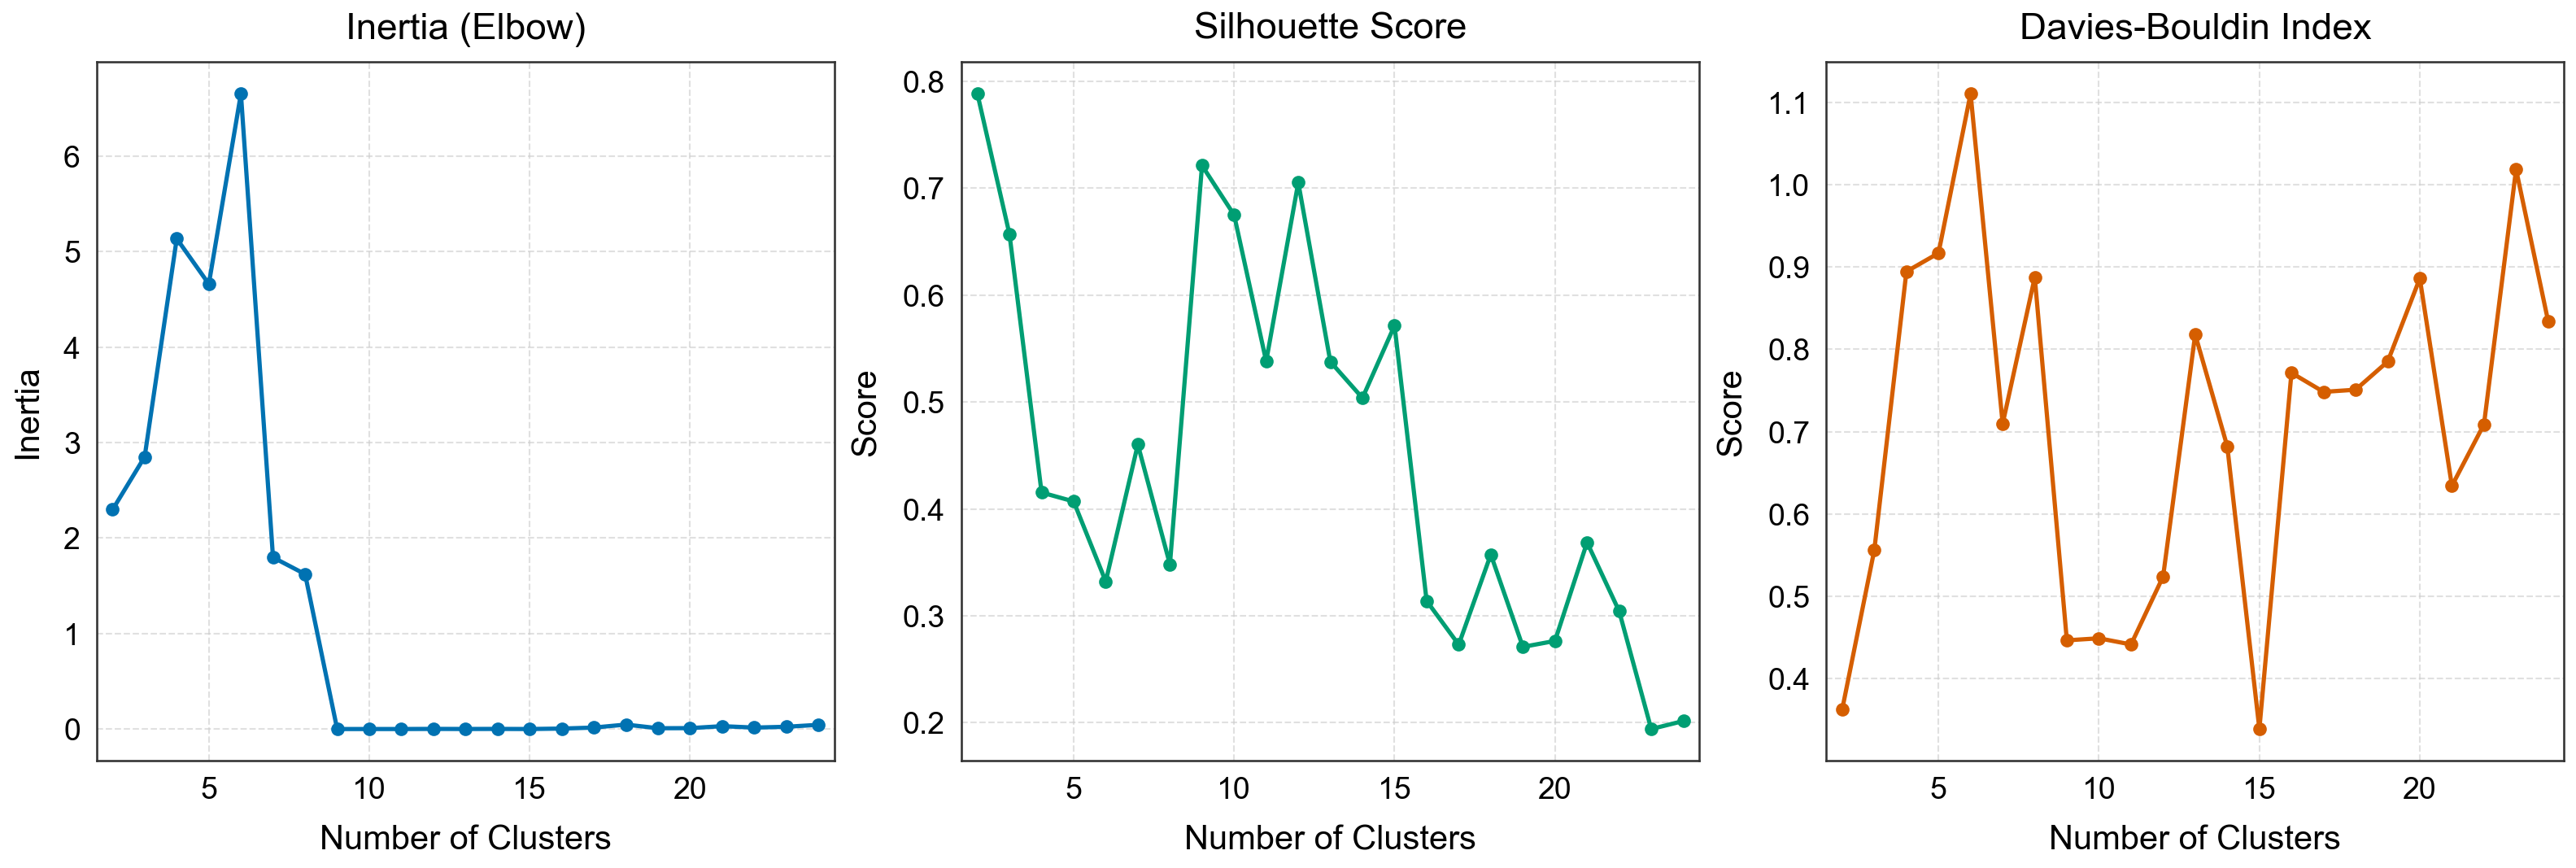

In [68]:
# Checking whether the finding the optimal number of clusters computation should be performed.
if state_variable_find_optimal_num_clusters:

    # Defining the range of cluster numbers which should be tested to determine their optimality for LDA modeling.
    cluster_range = range(2, 25)
    
    # Obtaining the current study programme DataFrame together with the corresponding dictionary and corpus.
    key = "study_programme_0"
    df = study_programmes_by_percentages[key]
    dictionary = corpora_by_percentages[key]["dictionary"]
    corpus = corpora_by_percentages[key]["corpus"]

    # Defining a set of lists that will feature the metric results.
    inertia_values, silhouette_scores, db_indices = [], [], []

    # Looping over every number of topics defined within the 'cluster_range' list and evaluating the clusters created by the LDA modeling.
    for num_topics in cluster_range:
        print(f"[{key}] Training LDA with {num_topics} topics...")

        # Training a Latent Dirichlet Allocation (LDA) model on the 'corpus' by calling the function 'train_lda_model()'.
        lda_model = train_lda_model(corpus, dictionary, num_topics)

        # Constructing a topic distribution matrix for the 'corpus' using the trained 'lda_model' by calling the function 'get_topic_matrix()'.
        topic_matrix = get_topic_matrix(lda_model, corpus, num_topics)

        # Applying K-means clustering to the topic distribution matrix 'topic_matrix' by calling the function 'perform_kmeans()'.
        kmeans, clusters = perform_kmeans(topic_matrix, num_topics)
        inertia_values.append(kmeans.inertia_)

        # Evaluating the quality of the clustering results present in the 'topic_matrix' and 'clusters' by calling the function 'evaluate_clustering()'.
        sil, db = evaluate_clustering(topic_matrix, clusters)
        silhouette_scores.append(sil)
        db_indices.append(db)

        print(f"{num_topics} -> Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil:.2f}, DB: {db:.2f}")

    # Defining the folder path featuring where the resulting metric plots should be stored.
    full_path = os.path.join("LDA_Modeling_Optimal_Num_Clusters", f"{key}_inertia_sil_db.png")
    os.makedirs(os.path.dirname(full_path), exist_ok=True)

    # Plotting the three clustering evaluation metrics Inertia, Silhouette Score, and Davis-Bouldin Index to help asses the optimal number of clusters by calling the function 'plot_clustering_metrics()'.
    plot_clustering_metrics(cluster_range, inertia_values, silhouette_scores, db_indices, save_path=full_path)

<br></br><br></br><br></br>

### 
### LDA Topic Modeling: Execution

In this section, the actual LDA topic modeling is performed for the optimal cluster number found in section 'LDA Topic Modeling: Finding Optimal Number of Clusters'.
<br></br>

In [20]:
# Initializing a dictionary that will store the LDA model, topic matrix, and kmeans object for each of the study programmes DataFrames present within the 'study_programmes_by_percentages' dictionary.
lda_modeling_outputs = {}

# Obtaining the current study programme DataFrame together with the corresponding dictionary and corpus.
key = "study_programme_0"
df = study_programmes_by_percentages[key]
dictionary = corpora_by_percentages[key]["dictionary"]
corpus = corpora_by_percentages[key]["corpus"]

# Defining the determined optimal number of clusters to be used for the LDA modeling.
num_of_clusters = 5

# Training a Latent Dirichlet Allocation (LDA) model on the 'corpus' by calling the function 'train_lda_model()'.
lda_model = train_lda_model(corpus, dictionary, num_topics=num_of_clusters)

# Constructing a topic distribution matrix for the 'corpus' using the trained 'lda_model'.
topic_matrix = get_topic_matrix(lda_model, corpus, num_topics=num_of_clusters)

# Applying K-means clustering to the topic distribution matrix 'topic_matrix'.
kmeans, clusters = perform_kmeans(topic_matrix, num_clusters=num_of_clusters)
clusters = clusters + 1

# Storing the LDA model 'lda_model', the topic matrix 'topic_matrix', and the KMeans object 'kmeans' in the dictionary 'lda_modeling_outputs'.
lda_modeling_outputs[key] = {
    "lda_model": lda_model,
    "topic_matrix": topic_matrix,
    "kmeans": kmeans
}

# Adding the cluster assignments to the study programme DataFrame.
df["cluster"] = clusters

# Applying t-distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality of the topic matrix.
tsne_coords = compute_tsne(topic_matrix)
df["tsne_x"] = tsne_coords[:, 0]
df["tsne_y"] = tsne_coords[:, 1]

# Defining the folder path where all output (plots, networks) for this run will be stored.
folder_name = f"LDA_Modeling_Execution/{key}/{num_of_clusters}_clusters"
os.makedirs(folder_name, exist_ok=True)

# Saving the cluster-labeled study programme DataFrame 'df' to a CSV file.
output_df_path = os.path.join(folder_name, f"{key}_clustered_study_programmes.csv")
df.to_csv(output_df_path, index=False)

# Plotting the t-SNE plot of all study programmes colored by cluster by calling the function 'plot_tsne_all_programmes()'.
plot_tsne_all_programmes(df, folder_name)

# 2. Plotting: One t-SNE plot per cluster
plot_tsne_per_cluster(df, folder_name)

# 3. Plotting: One t-SNE plot per study programme type (B/M/AD)
plot_tsne_per_study_programme_type(df, folder_name)

# 4. Plotting: One t-SNE plot per hogeschool
plot_tsne_per_hogeschool(df, folder_name)

# Updating the dictionary 'study_programmes_by_percentages' with the modified DataFrame 'df'.
study_programmes_by_percentages[key] = df

<br></br><br></br><br></br>

## 
## 
## Cluster Representation by Hogeschool and Programme Type

This section visualizes the over- or underrepresentation of study programmes across clusters, grouped by hogeschool and programme type. A heatmap shows Z-scores indicating deviations from expected distributions, annotated with actual programme counts. This helps identify which institutions or types are strongly associated with specific clusters.
<br></br>

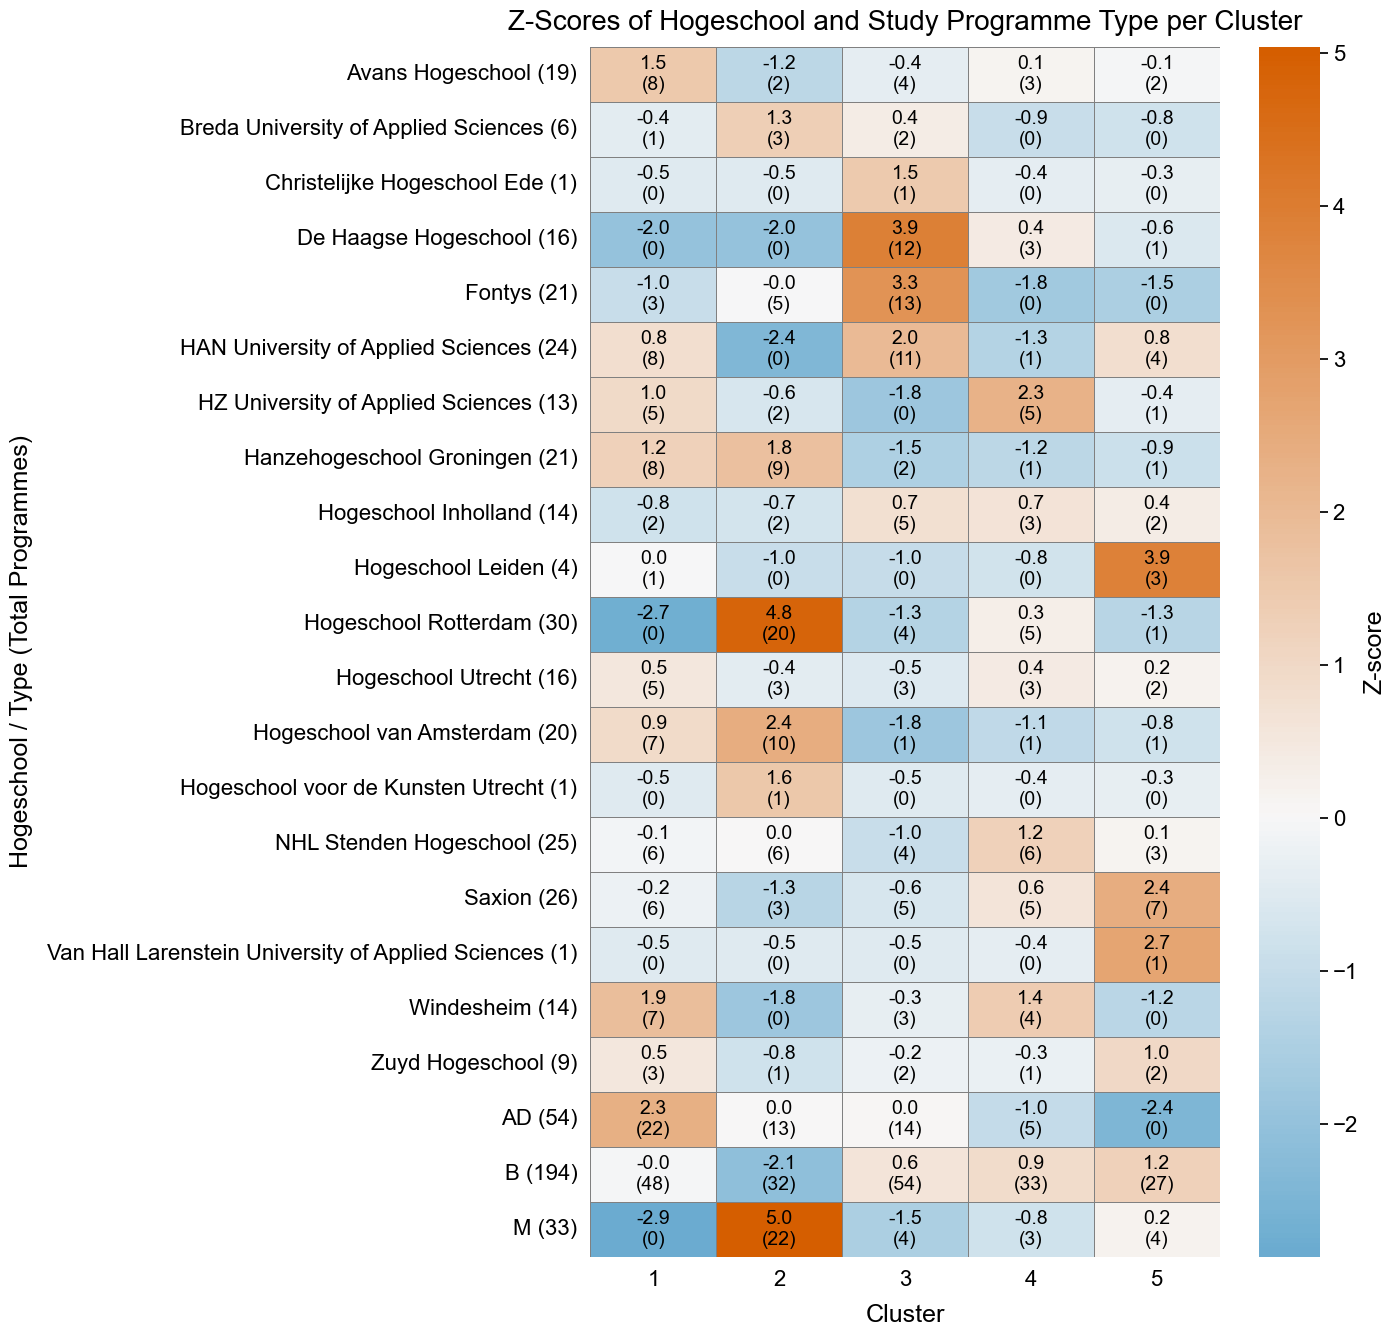

In [21]:
# Suppressing all warnings during execution to keep the output clean.
warnings.filterwarnings("ignore")


# Retrieving the DataFrame of study programmes associated with the current 'key'.
key = "study_programme_0"
study_programmes = study_programmes_by_percentages[key]

# Adding a new column 'source' which will be used to unify hogeschool/programme type labeling.
study_programmes['source'] = study_programmes['hogeschool']

# Counting how much study programmes are present for each hogeschool-cluster combination.
hogeschool_cluster_counts = (study_programmes.groupby(['hogeschool', 'cluster'])
                                             .size()                                 
                                             .reset_index(name='programme_count')    
                                             .rename(columns={'hogeschool': 'source'}) 
                            )

# Counting how much study programmes are present for each programme type-cluster combination.
type_cluster_counts = (study_programmes.groupby(['study_programme_type', 'cluster'])    
                                       .size()                                          
                                       .reset_index(name='programme_count')             
                                       .rename(columns={'study_programme_type': 'source'})  
                      )

# Combining both datasets 'hogeschool_cluster_counts' and 'type_cluster_counts'.
combined_counts = pd.concat([hogeschool_cluster_counts, type_cluster_counts], 
                            ignore_index=True
                           )

# Pivoting the 'combined_counts' to a matrix format where every row corresponds to a source (hogeschool or study programme types) and every column to a cluster.
combined_matrix = combined_counts.pivot_table(index='source',
                                              columns='cluster',
                                              values='programme_count',
                                              fill_value=0
                                             )

# Enforcing the row order where the hogescholen are included first in an alphabetical order followed by the study programme types in an alphabetical order.
ordered_sources = list(hogeschool_cluster_counts['source'].unique()) + list(type_cluster_counts['source'].unique())
combined_matrix = combined_matrix.loc[ordered_sources]

# Calculating the total number of study programmes for each source.
combined_matrix['total_programmes'] = combined_matrix.sum(axis=1)

# Calculating the expected programme counts based on the overall cluster distribution as well as the observed programme counts.
cluster_distribution = (study_programmes['cluster'].value_counts(normalize=True).sort_index())
expected_counts = combined_matrix['total_programmes'].values[:, None] * cluster_distribution.values
observed_counts = combined_matrix.drop(columns='total_programmes').values

# Computing the z-scores using the 'observed_counts' and 'expected_counts'.
z_scores = (observed_counts - expected_counts) / np.sqrt(expected_counts + 1e-6)

# Creating a DataFrame to store the 'z_scores' and extracting the matrix of actual counts to be used for annotation purposes.
z_scores_df = pd.DataFrame(z_scores, index=combined_matrix.index, columns=cluster_distribution.index)
count_matrix = combined_matrix.drop(columns='total_programmes')

# Copying the 'z_scores_df' DataFrame to prepare a new matrix for annotations that will contain both the z-score and the count in each cell.
annot_matrix = pd.DataFrame(
    index=z_scores_df.index,
    columns=z_scores_df.columns,
    dtype=object
)

# Looping over every cell of the 'annot_matrix' DataFrame and updating its content.
for row in annot_matrix.index:
    for col in annot_matrix.columns:
        z = z_scores_df.loc[row, col]
        count = count_matrix.loc[row, col]
        annot_matrix.loc[row, col] = f"{z:.1f}\n({int(count)})"

# Retrieving the total number of programmes per source.
totals = combined_matrix['total_programmes']

# Creating the y-axis labels by combining the source name with its total count.
y_labels = [f"{source} ({int(totals[source])})" for source in z_scores_df.index] 

# Defining the output folder where the heatmap image will be saved.
folder_name = f"LDA_Modeling_Execution/{key}/{num_of_clusters}_clusters"
os.makedirs(folder_name, exist_ok=True)

# Defining the number of rows and columns in the heatmap.
number_of_rows = z_scores_df.shape[0]
number_of_columns = z_scores_df.shape[1]

# Defining the desired visual size of each heatmap cell.
cell_width = 1.35
cell_height = 0.5

# Defining extra space for the y-axis labels, title, axis labels, and colorbar.
extra_width = 6
extra_height = 2.5

# Creating a figure size that scales with the number of heatmap cells.
figure_width = max(14, number_of_columns * cell_width + extra_width)
figure_height = max(10, number_of_rows * cell_height + extra_height)

# Creating a figure and axis object with cell sizes large enough for readable annotations.
fig, ax = plt.subplots(
    figsize=(figure_width, figure_height),
    facecolor="white"
)

# Setting the axis background to white.
ax.set_facecolor("white")

# Generating a heatmap where the z-scores determine the color and the annotations show both z-scores and counts.
heatmap = sns.heatmap(
    z_scores_df.astype(float),
    annot=annot_matrix,
    fmt="",
    cmap=COLORBLIND_DIVERGING_CMAP,
    center=0,
    cbar_kws={"label": "Z-score"},
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"fontsize": 14},
    ax=ax
)

# Retrieving the colorbar object so its label and ticks can be styled.
colorbar = heatmap.collections[0].colorbar

# Increasing the colorbar label size.
colorbar.set_label("Z-score", fontsize=18)

# Increasing the colorbar tick-label size.
colorbar.ax.tick_params(labelsize=16)

# Setting the y-axis labels, including the total number of programmes per source.
ax.set_yticklabels(
    y_labels,
    rotation=0,
    fontsize=16
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Setting the title of the heatmap.
ax.set_title(
    "Z-Scores of Hogeschool and Study Programme Type per Cluster",
    fontsize=20,
    pad=12
)

# Setting the x-axis label.
ax.set_xlabel(
    "Cluster",
    fontsize=18,
    labelpad=10
)

# Setting the y-axis label.
ax.set_ylabel(
    "Hogeschool / Type (Total Programmes)",
    fontsize=18,
    labelpad=10
)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Saving the figure.
save_manuscript_figure(
    os.path.join(folder_name, f"{key}_zscore_heatmap.png"),
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to avoid memory buildup.
plt.close(fig)

<br></br><br></br><br></br>

## 
## 
## Merging with HBO Monitor Data

In this section, the HBO Monitor Data is linked with the study programmes present in the 'study_programmes_by_percentages["study_programme_0"]' such that the entries in the HBO Monitor can be sorted into each of the clusters and further processing can be applied.
<br></br>

### Loading CROHO Codes & HBO Monitor Data

In this section, the file containing the CROHO codes and the file containing the HBO Monitor Data are loaded into this notebook.
<br></br>

In [22]:
# Loading the 'CrohoActueel14-10-2024.xlsx' file into this notebook, which was downloaded from [4].
croho_codes_df_path = os.path.join(data_directory, 'CrohoActueel14-10-2024.xlsx')
croho_codes_df = pd.read_excel(croho_codes_df_path)
croho_codes_df

,Brinnummer,Brinvolgnummer,Naam onderwijsinstelling,Gemeentenaam,Onderdeel,Subonderdeel,Opleidingscode,Naam opleiding voluit,Internationale naam,Opleidingsvorm,...,Selectie-eisen Intensief progr.,Verhoogd coll.geld Intensief progr.,Onderwijscapaciteit,Versneld traject,Graad,Graadtoevoeging,Inleverdatum,Datum voorwaarden,Datum intrekking,Unnamed: 50
0,13,0,Stichting Hieronymus Hogeschool voor Vertalen,UTRECHT,TAAL EN CULTUUR,NaN,4593,Opleiding Vertaler Engels,NaN,DEELTIJD,...,NEE,NEE,NaN,NVT,NaN,NaN,00-00-0000,00-00-0000,00-00-0000,#
1,13,2,Stichting Hieronymus Hogeschool voor Vertalen,ARNHEM,TAAL EN CULTUUR,NaN,4593,Opleiding Vertaler Engels,NaN,DEELTIJD,...,NEE,NEE,NaN,NVT,NaN,NaN,00-00-0000,00-00-0000,00-00-0000,#
2,13,0,Stichting Hieronymus Hogeschool voor Vertalen,UTRECHT,TAAL EN CULTUUR,NaN,4590,Opleiding Vertaler Frans,NaN,DEELTIJD,...,NEE,NEE,NaN,NVT,NaN,NaN,00-00-0000,00-00-0000,00-00-0000,#
3,13,2,Stichting Hieronymus Hogeschool voor Vertalen,ARNHEM,TAAL EN CULTUUR,NaN,4590,Opleiding Vertaler Frans,NaN,DEELTIJD,...,NEE,NEE,NaN,NVT,NaN,NaN,00-00-0000,00-00-0000,00-00-0000,#
4,14,0,Hogeschool Dirksen B.V.,ARNHEM,TECHNIEK,NaN,4256,HTO informatica,NaN,DEELTIJD,...,NEE,NEE,NaN,NVT,NaN,NaN,00-00-0000,00-00-0000,00-00-0000,#
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119533,32CM,0,Haarlem Institute for Higher Education B.V.,HAARLEM,ECONOMIE,NaN,70231,M Applied Sustainability Management,M Applied Sustainability Management,DEELTIJD,...,NEE,NEE,NaN,NVT,Master,of Science,00-00-0000,2023-10-01 00:00:00,00-00-0000,#
119534,32CM,0,Haarlem Institute for Higher Education B.V.,HAARLEM,ECONOMIE,NaN,70231,M Applied Sustainability Management,M Applied Sustainability Management,VOLTIJD,...,NEE,NEE,NaN,NVT,Master,of Science,00-00-0000,2023-10-01 00:00:00,00-00-0000,#
119535,32CZ,1,Stichting BV/BmS Opleidingen,UTRECHT,TECHNIEK,NaN,70233,M Constructief Ontwerpen,M Structural Engineering,DEELTIJD,...,NEE,NEE,NaN,NVT,Master,of Science,00-00-0000,00-00-0000,00-00-0000,#
119536,32DF,0,International University of Applied Sciences A...,AMSTERDAM,GEDRAG EN MAATSCHAPPIJ,NaN,70235,M Toegepaste Islamitische Theologie,M Applied Islamic Theologie,DEELTIJD,...,NEE,NEE,NaN,NVT,Master,of Arts,00-00-0000,00-00-0000,00-00-0000,#


In [ ]:
# Defining the path of where the HBO Monitor Data is stored as a 'csv' file.
hbo_monitor_data_path = os.path.join(data_directory, 'Sis2024hbo incl extra vragen.csv')

# Loading the metadata from the 'Sis2024hbo incl extra vragen.sav' file.
_, hbo_monitor_metadata = pyreadstat.read_sav(os.path.join(data_directory, 'Sis2024hbo incl extra vragen.sav'))

# Checking if the CSV file already exists at the 'hbo_monitor_data_path'.
if os.path.exists(hbo_monitor_data_path):
    # Loading the 'Sis2024hbo incl extra vragen.csv' file into this notebook.
    hbo_monitor_data = pd.read_csv(hbo_monitor_data_path)
    
else:
    # Loading the 'Sis2024hbo incl extra vragen.sav' file into this notebook.
    hbo_monitor_data, hbo_monitor_metadata = pyreadstat.read_sav(os.path.join(data_directory, 'Sis2024hbo incl extra vragen.sav'))

    # Saving the 'hbo_monitor_data' DataFrame as a CSV file.
    hbo_monitor_data.to_csv(hbo_monitor_data_path, index=False)
    
hbo_monitor_data

<br></br><br></br>

### Retrieving the Study Programmes Data

In this section, the data is retrieved that corresponds to the selected study programme DataFrame and the LDA modeling results present in the 'lda_modeling_outputs' dictionary to which further processing will be applied.

In [ ]:
# Defining the selected study programme DataFrame to which the CROHO codes should be added and to which further processing will be applied.
study_programmes_hbo_monitor = study_programmes_by_percentages["study_programme_0"]
study_programmes_hbo_monitor

<br></br>

In [25]:
# Retrieving the LDA modeling outputs from the 'lda_modeling_outputs' dictionary that correspond to the selected study programme DataFrame 'study_programmes_hbo_monitor'.
lda_model_hbo_monitor = lda_modeling_outputs["study_programme_0"]['lda_model']
topic_matrix_hbo_monitor = lda_modeling_outputs["study_programme_0"]['topic_matrix']
kmeans_hbo_monitor = lda_modeling_outputs["study_programme_0"]['kmeans']

<br></br><br></br>

### 
### Adding CROHO codes to the Study Programmes DataFrame

In this section, the CROHO codes present in the 'croho_codes_df' DataFrame will be added to the DataFrame 'study_programmes_by_percentages["study_programme_0"]', which from this point onwards will be referred to as the 'study_programmes_hbo_monitor' DataFrame.

In [26]:
# Defining the first name with which the hogeschool appears within the 'croho_codes_df' DataFrame.
hogescholen_original_names = {
    "Avans Hogeschool": ["Avans Hogeschool Breda-Tilburg", "Avans Hogeschool"],
    "Breda University of Applied Sciences": ["Nationale Hogeschool voor Toerisme en Verkeer", "NHTV internationale hogeschool Breda", "Breda University of Applied Sciences"],
    "Christelijke Hogeschool Ede": ["Christelijke Hogeschool 'De Vijverberg-Felua'", "Christelijke Hogeschool Ede"],
    "De Haagse Hogeschool": ["Haagse Hogeschool / TH Rijswijk", "De Haagse Hogeschool"],
    "Fontys": ["Fontys Hogescholen", "Fontys Hogeschool"],
    "HAN University of Applied Sciences": ["Hogeschool van Arnhem en Nijmegen"],
    "HZ University of Applied Sciences": ["Hogeschool Zeeland", "HZ University of Applied Sciences"],
    "Hanzehogeschool Groningen": ["Hanzehogeschool,Hogeschool van Groningen", "Hanzehogeschool Groningen"],
    "Hogeschool Inholland": ["Hogeschool INHOLLAND", "Hogeschool Inholland"],
    "Hogeschool Leiden": ["Hogeschool Leiden", "Stichting Hogeschool Leiden", "Hogeschool Leiden"],
    "Hogeschool Rotterdam": ["Hogeschool Rotterdam"],
    "Hogeschool Utrecht": ["Hogeschool van Utrecht", "Hogeschool Utrecht"],
    "Hogeschool van Amsterdam": ["Hogeschool van Amsterdam"],
    "Hogeschool voor de Kunsten Utrecht": ["Hogeschool voor de Kunsten Utrecht"],
    "NHL Stenden Hogeschool": ["NHL Stenden Hogeschool"],
    "Saxion": ["Hogeschool Enschede", "Saxion Hogeschool Enschede", "Saxion Hogeschool"],
    "Van Hall Larenstein University of Applied Sciences": ["Hogeschool Van Hall Larenstein"],
    "Windesheim": ["Christelijke Hogeschool Windesheim"],
    "Zuyd Hogeschool": ["Hogeschool Limburg", "Hogeschool Zuyd", "Zuyd Hogeschool"],
}


# Adding columns to the 'study_programmes_hbo_monitor' which will feature the CROHO codes and the start dates.
study_programmes_hbo_monitor['CROHO_code'] = None
study_programmes_hbo_monitor['Datum begin opleiding'] = None

# Looping over every study programme in the 'study_programmes_hogescholen_df'.
for index, row in study_programmes_hbo_monitor.iterrows():

    # Retrieving the study programme name, hogeschool, and niveau.
    study_programme = row["study_programme_name"].lower().strip()
    original_hogeschool = row["hogeschool"]
    niveau = row["study_programme_type"].lower().strip()
    study_programme_type = row["study_programme_length_type"].lower().strip()
    study_programme_niveau = f"{niveau} {study_programme}".lower()

    # Retrieving the possible hogescholen names from the 'hogescholen_original_names' dictionary.
    possible_hogescholen_names = hogescholen_original_names.get(original_hogeschool)

    # Finding the entries from the 'croho_codes_df' corresponding to the 'study_programme', 'study_programme_type, and one of the 'possible_hogescholen_names'.
    matching_entries = pd.DataFrame()
    for hogescholen_name in possible_hogescholen_names:
        temp_matches = croho_codes_df[
            (croho_codes_df['Naam opleiding voluit'].str.lower() == study_programme_niveau) &
            (croho_codes_df['Naam onderwijsinstelling'].str.lower().str.contains(hogescholen_name.lower())) &
            (croho_codes_df['Opleidingsvorm'].str.lower() == study_programme_type)
        ]
        if not temp_matches.empty:
            matching_entries = temp_matches
            break

    # Stopping the execution if no 'matching_entries' have been found within the 'croho_codes_df' DataFrame.
    if matching_entries.empty:
        print(row)
        print(study_programme_niveau)
        print(original_hogeschool)
        sys.exit(f"There is no match found for the current '{study_programme_niveau}'")

    # Filtering all rows of the 'matching_entries' where the CROHO code is equal to the CROHO code of the last row.
    CROHO_code = matching_entries.iloc[-1]["Opleidingscode"]
    croho_code_group = matching_entries[matching_entries["Opleidingscode"] == CROHO_code]
   
    # Retrieving the start date from the last matching entry.
    datum_begin_opleiding = pd.to_datetime(croho_code_group.iloc[0]["Datum begin opleiding"]).year

    # Validating the CROHO code range based on niveau.
    if niveau == 'b' and not (30000 <= CROHO_code <= 40000):
        print(f"The bachelor programme {study_programme_niveau} has a CROHO code of {str(CROHO_code)} which is not in the expected range.")
    elif niveau == 'm' and not (40000 <= CROHO_code <= 50000):
        print(f"The master programme {study_programme_niveau} has a CROHO code of {str(CROHO_code)} which is not in the expected range.")
    elif niveau == 'ad' and not (80000 <= CROHO_code <= 81000):
        print(f"The associate degree programme {study_programme_niveau} has a CROHO code of {str(CROHO_code)} which is not in the expected range.")

    # Assigning the CROHO code and the start date to the DataFrame.
    study_programmes_hbo_monitor.at[index, 'CROHO_code'] = CROHO_code
    study_programmes_hbo_monitor.at[index, 'Datum begin opleiding'] = datum_begin_opleiding

The bachelor programme b tourism (joint degree) has a CROHO code of 55001 which is not in the expected range.
The master programme m european master in renewable energy has a CROHO code of 69299 which is not in the expected range.


In [ ]:
study_programmes_hbo_monitor

<br></br><br></br>

### Examining CROHO Codes in HBO Monitor Data

In this section, the CROHO codes present in the 'study_programmes_hbo_monitor' DataFrame are examined to see how often the study programmes appear within the 'hbo_monitor_data' DataFrame by using the column 'crohosteek'.

In [ ]:
# Grouping the 'study_programmes_hbo_monitor' DataFrame by 'CROHO_code' while retaining only the 'study_programme_name', 'hogeschool', and 'study_programme_type' columns in each group.
grouped = study_programmes_hbo_monitor.groupby('CROHO_code')[['study_programme_name', 'hogeschool', 'study_programme_type']]

# Looping over each group formed by the unique 'CROHO_code' values.
for croho, group in grouped:

    # Counting how many times the current CROHO_code appears in the 'crohosteek' column of the 'hbo_monitor_data' DataFrame,
    count_in_hbo_monitor_data = (hbo_monitor_data['crohosteek'] == croho).sum()
    
    # Displaying how often the CROHO_code was found in the 'hbo_monitor_data' DataFrame.
    print(f"\nCROHO_code: {croho} (Found in HBO Monitor Data: {count_in_hbo_monitor_data} times)")

    # Looping over each study programme in the current 'group' and displaying their details.
    for _, row in group.iterrows():
        print(f"  - Programme: {row['study_programme_name']}, Hogeschool: {row['hogeschool']}, Type: {row['study_programme_type']}")

<br></br><br></br>

### 
### Filtering the HBO Monitor Data

In this section, the HBO Monitor Data that is present in the 'hbo_monitor_data' DataFrame is filtered such that the only entries that remain refer to study programmes that are present in the 'study_programmes_hbo_monitor' DataFrame.

In [ ]:
# Retrieving the list of CROHO codes from the 'study_programmes_hbo_monitor' DataFrame.
croho_codes = study_programmes_hbo_monitor["CROHO_code"].dropna().unique().tolist()

# Filtering the 'hbo_monitor_data' DataFrame to only contain entries where the study programmes are also present in the 'study_programmes_hbo_monitor' DataFrame.
filtered_hbo_monitor_data = hbo_monitor_data[hbo_monitor_data["crohosteek"].isin(croho_codes)].reset_index(drop=True)

# Replacing the numeric representation of the hogescholen with the string one within the 'filtered_hbo_monitor_data' DataFrame based on the labels of the variables within the 'hbo_monitor_metadata'.
filtered_hbo_monitor_data['hogeschool'] = filtered_hbo_monitor_data['vschoo'].astype(float).map(hbo_monitor_metadata.variable_value_labels['vschoo'])

# Defining the mapping dictionary featuring which hogescholen names in the 'filtered_hbo_monitor_data' DataFrame correspond to which hogescholen names in the 'study_programmes_hbo_monitor' DataFrame.
hogescholen_name_mapping_hbo_monitor = {
    "Avans Hogeschool": "Avans Hogeschool",
    "Breda University of Applied Sciences": "Breda University of Applied Sciences",
    "Christelijke Hogeschool Ede": "Christelijke Hogeschool Ede",
    "De Haagse Hogeschool": "De Haagse Hogeschool",
    "Fontys Hogescholen": "Fontys",
    "Hanzehogeschool Groningen": "Hanzehogeschool Groningen",
    "Hogeschool Inholland": "Hogeschool Inholland",
    "Hogeschool Leiden": "Hogeschool Leiden",
    "Hogeschool Rotterdam": "Hogeschool Rotterdam",
    "Hogeschool Saxion": "Saxion",
    "Hogeschool Utrecht": "Hogeschool Utrecht",
    "Hogeschool van Amsterdam": "Hogeschool van Amsterdam",
    "Hogeschool van Arnhem en Nijmegen": "HAN University of Applied Sciences",
    "Hogeschool voor de Kunsten Utrecht": "Hogeschool voor de Kunsten Utrecht",
    "Hogeschool Windesheim": "Windesheim",
    "HZ University of Applied Sciences": "HZ University of Applied Sciences",
    "Stenden Hogeschool": "NHL Stenden Hogeschool",
    "Van Hall Larenstein University of Applied Sciences": "Van Hall Larenstein University of Applied Sciences",
    "Zuyd Hogeschool": "Zuyd Hogeschool",
}

# Replacing the names of the hogescholen present in the 'hogeschool' column of the 'filtered_hbo_monitor_data' DataFrame with the names used in the 'study_programmes_hbo_monitor' DataFrame.
filtered_hbo_monitor_data['hogeschool'] = filtered_hbo_monitor_data['hogeschool'].replace(hogescholen_name_mapping_hbo_monitor)

filtered_hbo_monitor_data

<br></br><br></br>

### 
### Extending the HBO Monitor Data

In this section, information originating from the 'study_programmes_hbo_monitor' DataFrame is added to the newly created 'hbo_monitor_with_metadata' DataFrame as well as creating columns featuring information on whether the predicted cluster matches with the cluster to which the corresponding study programme belongs.
<br></br>

In [ ]:
# Defining the set of columns that will be added to the 'hbo_monitor_with_metadata' DataFrame from the 'study_programmes_hbo_monitor' DataFrame.
columns_to_merge = [
    "CROHO_code",
    "Datum begin opleiding",
    "hogeschool",
    "study_programme_name",
    "study_programme_type",
    "study_programme_location",
    "study_programme_language",
    "study_programme_length",
    "study_programme_length_type"
]

# Performing a precise merge on the columns 'crohosteek' and 'hogeschool' within the 'filtered_hbo_monitor_data' DataFrame and adding the 'columns_to_merge'.
hbo_monitor_with_metadata = filtered_hbo_monitor_data.merge(study_programmes_hbo_monitor[columns_to_merge],
                                                            how="left",
                                                            left_on=["crohosteek", "hogeschool"],
                                                            right_on=["CROHO_code", "hogeschool"]
                                                           )

# Creating a mapping from the 'CROHO_code' to the corresponding cluster present within the 'study_programmes_hbo_monitor' DataFrame.
croho_to_study_cluster = study_programmes_hbo_monitor.set_index("CROHO_code")["cluster"].to_dict()

# Creating a new column in the 'hbo_monitor_with_metadata' DataFrame for the matched study cluster using the 'croho_to_study_cluster'.
hbo_monitor_with_metadata["matched_study_cluster"] = hbo_monitor_with_metadata["crohosteek"].map(croho_to_study_cluster)
hbo_monitor_with_metadata

## 
## 
## CHECKPOINT: Saving and Loading Data

In this section, the data and the variables computed in the previous section that are relevant for further analysis in the upcoming sections can be stored into the 'data_directory' or loaded from the 'data_directory' into this notebook such that these can be freely used from this point onwards without having to rerun the analysis.
<br></br>

In [31]:
#############################
#####  Saving the Data  #####
#############################
if state_variable_storing_clustering_results:

    # Saving the DataFrames using the 'dump()' function from the 'joblib' library.
    joblib.dump(study_programmes_hbo_monitor, os.path.join(data_directory, 'study_programmes_hbo_monitor.pkl'))
    joblib.dump(filtered_hbo_monitor_data, os.path.join(data_directory, 'filtered_hbo_monitor_data.pkl'))
    joblib.dump(hbo_monitor_with_metadata, os.path.join(data_directory, 'hbo_monitor_with_metadata.pkl'))

    # Saving the Gensim LDA model by calling the 'save()' function from the 'gensim' library.
    lda_model_hbo_monitor.save(os.path.join(data_directory, 'lda_model_hbo_monitor.gensim'))

    # Saving the topic matrix by calling the 'save()' function from the 'numpy' library.
    np.save(os.path.join(data_directory, 'topic_matrix_hbo_monitor.npy'), topic_matrix_hbo_monitor)

    # Saving the fitted KMeans object by calling the 'dump()' function from the 'joblib' library.
    joblib.dump(kmeans_hbo_monitor, os.path.join(data_directory, 'kmeans_hbo_monitor.pkl'))



##############################
#####  Loading the Data  #####
##############################
if state_variable_loading_clustering_results:

    # Loading the DataFrames from the 'data_directory' using the 'load()' function from the 'joblib' library.
    study_programmes_hbo_monitor = joblib.load(os.path.join(data_directory, 'study_programmes_hbo_monitor.pkl'))
    filtered_hbo_monitor_data = joblib.load(os.path.join(data_directory, 'filtered_hbo_monitor_data.pkl'))
    hbo_monitor_with_metadata = joblib.load(os.path.join(data_directory, 'hbo_monitor_with_metadata.pkl'))

    # Loading the Gensim LDA model from the 'data_directory' by calling the 'load()' function from the 'gensim' library.
    lda_model_hbo_monitor = LdaModel.load(os.path.join(data_directory, 'lda_model_hbo_monitor.gensim'))

    # Loading the topic matrix from the 'data_directory' by calling the 'load()' function from the 'numpy' library.
    topic_matrix_hbo_monitor = np.load(os.path.join(data_directory, 'topic_matrix_hbo_monitor.npy'))

    # Loading the fitted KMeans object from the 'data_directory' by calling the 'load()' function from the 'joblib' library.
    kmeans_hbo_monitor = joblib.load(os.path.join(data_directory, 'kmeans_hbo_monitor.pkl'))

<br></br><br></br><br></br>

## 
## 
## Evaluating Study Programme Clusters

In this section, the study programme clusters previously identified are further analyzed using the information that is present in the 'filtered_hbo_monitor_data' DataFrame.
<br></br>

### Starting Dates Per Cluster Visualization

In this section, the starting dates corresponding to the study programmes present in the 'study_programmes_hbo_monitor' DataFrame that are clustered into the five clusters are visualized using a violin plot and heatmap. 
<br></br>

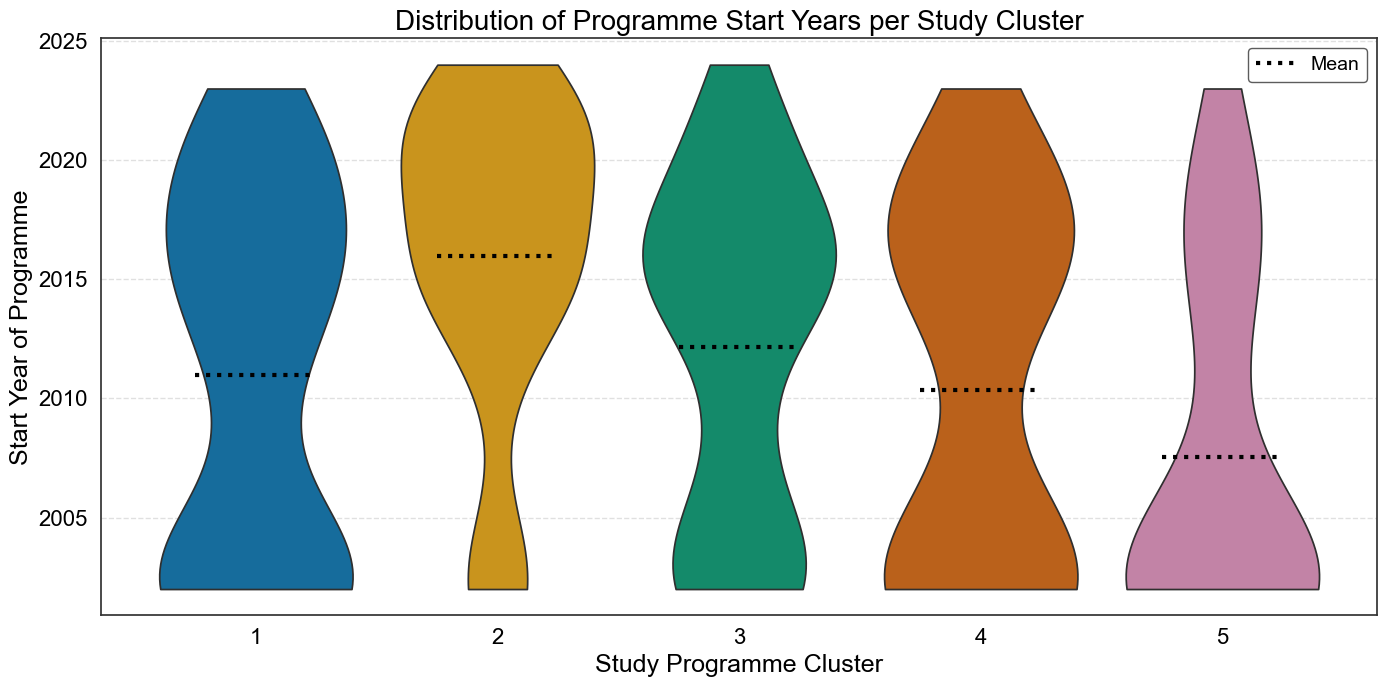

In [32]:
# Removing rows of the 'study_programmes_hbo_monitor' DataFrame that have missing values in either the 'cluster' or the 'Datum begin opleiding' column.
study_programmes_start_dates_df = study_programmes_hbo_monitor.dropna(
    subset=["cluster", "Datum begin opleiding"]
).copy()

# Converting the cluster values present within the 'cluster' column of the 'study_programmes_start_dates_df' DataFrame to strings for easier x-axis labeling.
study_programmes_start_dates_df["cluster"] = study_programmes_start_dates_df["cluster"].astype(str)

# Defining the cluster order once so that the violin plot and the mean lines use the exact same ordering.
cluster_order = sorted(
    study_programmes_start_dates_df["cluster"].unique(),
    key=lambda x: int(x)
)

# Creating a figure featuring a violin plot of programme start years per study programme cluster.
fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")

# Setting the axis background to white.
ax.set_facecolor("white")

# Creating a violin plot featuring the start dates present in the 'Datum begin opleiding' column for each of the clusters.
sns.violinplot(
    data=study_programmes_start_dates_df,
    x="cluster",
    y="Datum begin opleiding",
    order=cluster_order,
    inner=None,
    scale="width",
    palette=get_colorblind_palette(len(cluster_order)),
    cut=0,
    ax=ax
)

# Looping over each cluster in the plotted order to compute and draw the mean line.
for i, cluster in enumerate(cluster_order):

    # Selecting the start-year data for the current cluster.
    cluster_data = study_programmes_start_dates_df[
        study_programmes_start_dates_df["cluster"] == cluster
    ]

    # Computing the mean start year for the current cluster.
    mean_start_year = cluster_data["Datum begin opleiding"].mean()

    # Drawing a horizontal mean line across the width of the current violin.
    ax.hlines(
        y=mean_start_year,
        xmin=i - 0.25,
        xmax=i + 0.25,
        colors="black",
        linestyles="dotted",
        linewidth=3,
        label="Mean" if i == 0 else None,
        zorder=5
    )

# Adding a legend entry for the mean line.
ax.legend(
    loc="upper right",
    fontsize=14
)

# Setting the title of the plot.
ax.set_title(
    "Distribution of Programme Start Years per Study Cluster",
    fontsize=20
)

# Setting the x-axis label.
ax.set_xlabel(
    "Study Programme Cluster",
    fontsize=18
)

# Setting the y-axis label.
ax.set_ylabel(
    "Start Year of Programme",
    fontsize=18
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Adding a horizontal grid for readability.
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ensuring that the grid is drawn behind the violin shapes.
ax.set_axisbelow(True)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Defining the full path where the plot will be saved.
full_path = "LDA_Modeling_Execution/study_programme_0/5_clusters/study_programme_start_years_per_cluster_violin.png"

# Creating the output directory if it does not yet exist.
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(
    full_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to free memory.
plt.close()

<br></br>

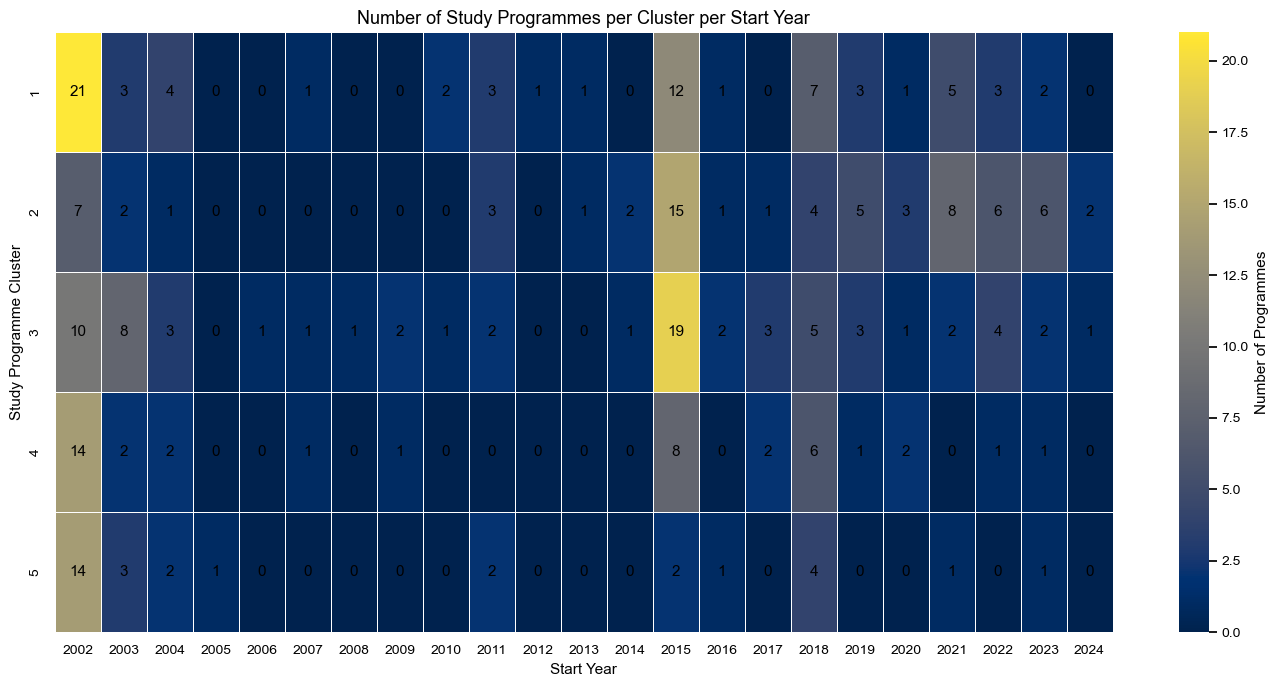

In [33]:
# Removing rows of the 'study_programmes_hbo_monitor' DataFrame that have missing values in either the 'cluster' or the 'Datum begin opleiding' column.
study_programmes_start_dates_df = study_programmes_hbo_monitor.dropna(subset=["cluster", "Datum begin opleiding"]).copy()

# Converting the cluster values present within the 'cluster' column of the 'study_programmes_start_dates_df' DataFrame to strings for easier x-axis labeling.
study_programmes_start_dates_df["cluster"] = study_programmes_start_dates_df["cluster"].astype(str)

# Creating a pivot table where the clusters are the rows and the years are the columns by calling the function 'pivot_table()'.
heatmap_data = study_programmes_start_dates_df.pivot_table(index="cluster",
                                                           columns="Datum begin opleiding",
                                                           values="study_programme_name", 
                                                           aggfunc="count",
                                                           fill_value=0
                                                          )

# Sorting the rows and columns for better readability.
heatmap_data = heatmap_data.sort_index(axis=0)
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

# Plotting the 'heatmap_data' by calling the function 'heatmap()'.
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap=COLORBLIND_SEQUENTIAL_CMAP, linewidths=0.5, cbar_kws={"label": "Number of Programmes"})

# Setting the  title, labels, and layout of the plot.
plt.title("Number of Study Programmes per Cluster per Start Year")
plt.xlabel("Start Year")
plt.ylabel("Study Programme Cluster")
plt.tight_layout()

# Saving the plot.
full_path = f"LDA_Modeling_Execution/study_programme_0/5_clusters/study_programme_start_years_per_cluster_heatmap.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()

<br></br>

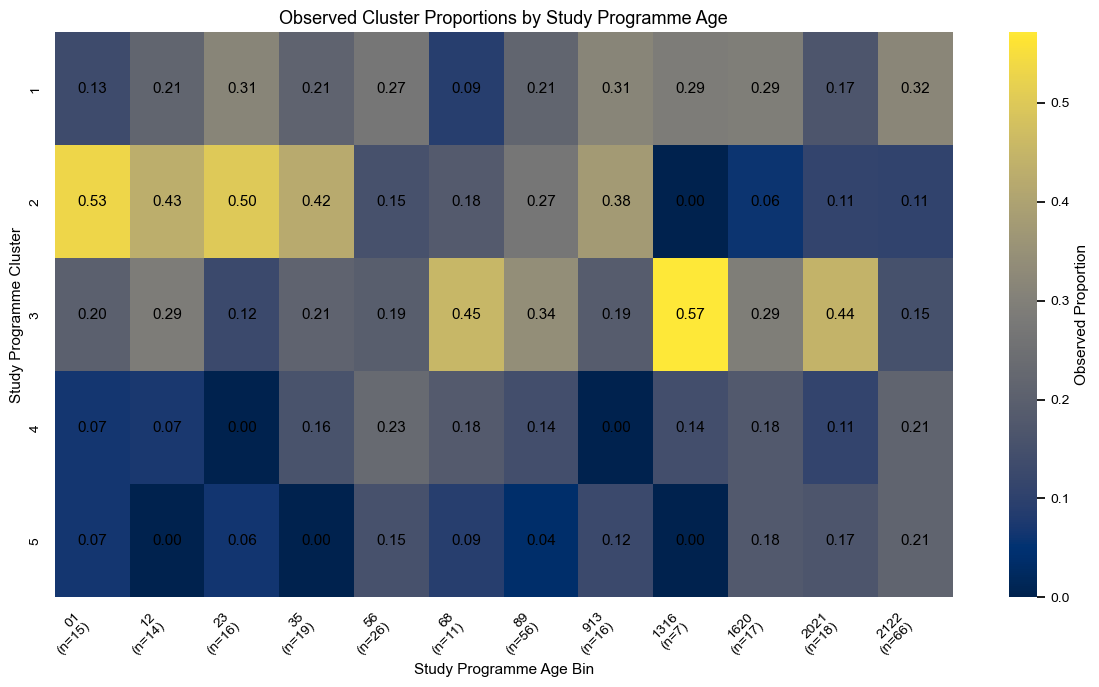

In [34]:
# Removing rows of the 'study_programmes_hbo_monitor' DataFrame that have missing values in either the 'cluster' or the 'Datum begin opleiding' column.
study_programmes_programme_age_df = study_programmes_hbo_monitor.dropna(subset=["cluster", "Datum begin opleiding"]).copy()

# Converting the cluster values present within the 'cluster' column of the 'study_programmes_programme_age_df' DataFrame to strings for easier labeling.
study_programmes_programme_age_df["cluster"] = study_programmes_programme_age_df["cluster"].astype(str)

# Defining the cluster order once so that the heatmap uses the same cluster ordering as the violin plot.
cluster_order = sorted(study_programmes_programme_age_df["cluster"].unique(), key=lambda x: int(x))

# Calculating the age of the study programmes from the programme start year.
hbo_monitor_data_reference_year = 2024
study_programmes_programme_age_df["programme_age"] = (
    hbo_monitor_data_reference_year - study_programmes_programme_age_df["Datum begin opleiding"].astype(int)
)

# Creating programme age bins with approximately equal numbers of observations.
study_programmes_programme_age_df["programme_age_bin"] = pd.qcut(
    study_programmes_programme_age_df["programme_age"],
    q=25,
    duplicates="drop"
)

# Computing the number of observations per programme age bin and study cluster.
heatmap_counts = (
    study_programmes_programme_age_df
    .groupby(["programme_age_bin", "cluster"])
    .size()
    .unstack(fill_value=0)
)

# Reordering the cluster columns so that they match the violin plot ordering.
heatmap_counts = heatmap_counts.reindex(columns=cluster_order)

# Computing the total number of programmes in each programme age bin.
bin_totals = heatmap_counts.sum(axis=1)

# Converting the counts to within-bin proportions.
heatmap_props = heatmap_counts.div(
    heatmap_counts.sum(axis=1),
    axis=0
)

# Creating formatted programme-age-bin labels for the x-axis, including the number of programmes in each bin.
formatted_bin_labels = [
    f"{int(interval.left)}{int(interval.right)}\n(n={bin_totals.loc[interval]})"
    for interval in heatmap_props.index
]

# Replacing the interval index with the formatted labels.
heatmap_props.index = formatted_bin_labels

# Creating a heatmap of the observed cluster proportions per programme age bin.
plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_props.T,
    annot=True,
    fmt=".2f",
    cmap=COLORBLIND_SEQUENTIAL_CMAP,
    cbar_kws={"label": "Observed Proportion"}
)

# Setting the title, labels, and layout of the plot.
plt.title("Observed Cluster Proportions by Study Programme Age")
plt.xlabel("Study Programme Age Bin")
plt.ylabel("Study Programme Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Saving the plot.
full_path = f"LDA_Modeling_Execution/study_programme_0/5_clusters/observed_cluster_proportions_by_programme_age_bin_heatmap.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()

<br></br><br></br>

### Salaries Per Study Programme Cluster

In this section, the analysis explores how salary outcomes differ across study programme clusters. Using the 'hbo_monitor_with_metadata' DataFrame, it focuses on gross hourly (n_hbiu) income. Respondents are grouped by their assigned study programme cluster (matched_study_cluster), and for each cluster, the median income values are calculated. This provides insight into which clusters are associated with higher or lower post-graduation earnings.
<br></br>

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:2.669e-08
2 vs. 3: Custom statistical test, P_val:1.202e-04
2 vs. 4: Custom statistical test, P_val:5.676e-03
1 vs. 4: Custom statistical test, P_val:1.453e-02
1 vs. 5: Custom statistical test, P_val:1.945e-04


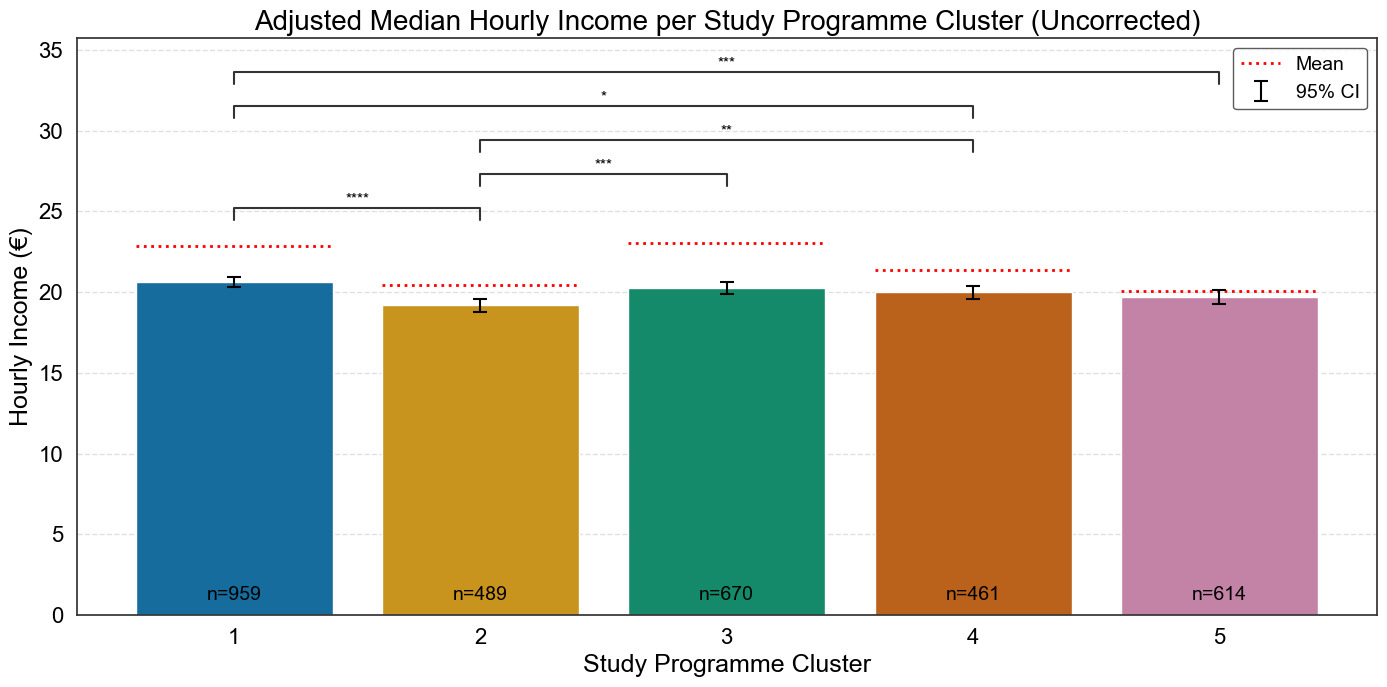

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:2.669e-07
2 vs. 3: Custom statistical test, P_val:1.202e-03
1 vs. 5: Custom statistical test, P_val:1.945e-03


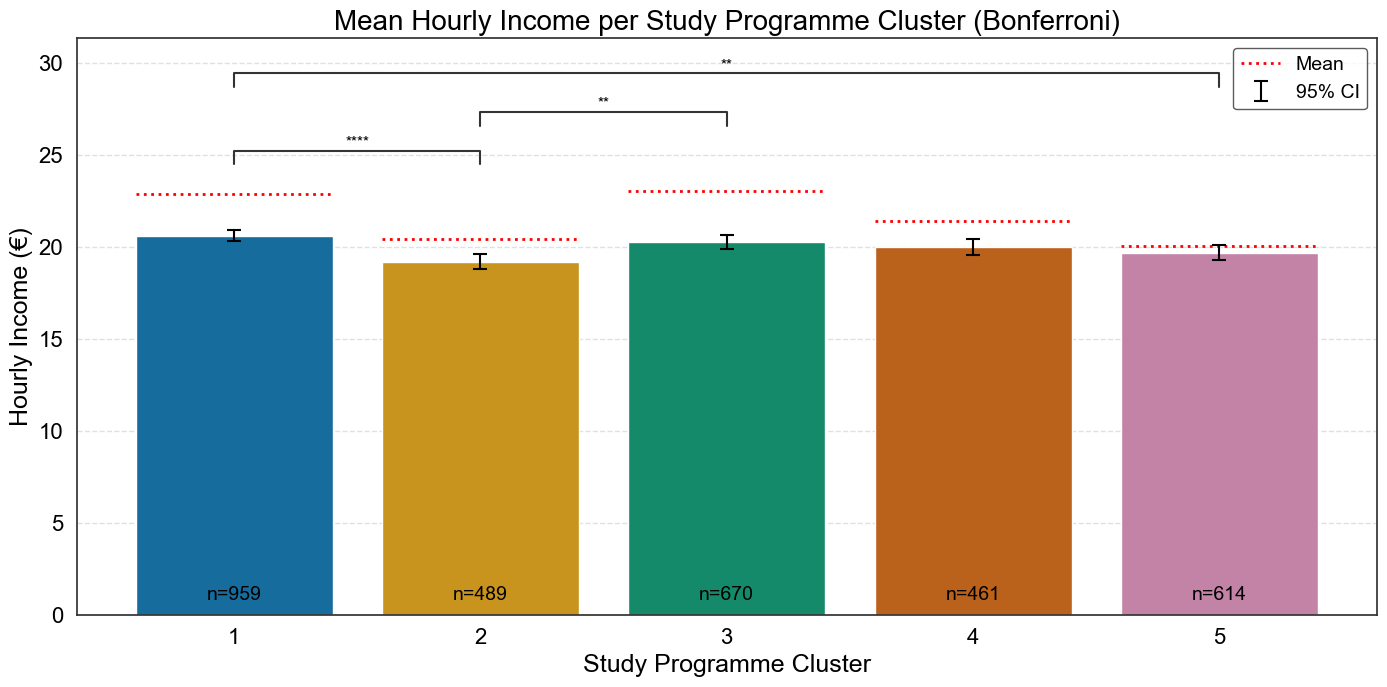

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:2.669e-07
2 vs. 3: Custom statistical test, P_val:6.008e-04
2 vs. 4: Custom statistical test, P_val:1.419e-02
1 vs. 4: Custom statistical test, P_val:2.907e-02
1 vs. 5: Custom statistical test, P_val:6.483e-04


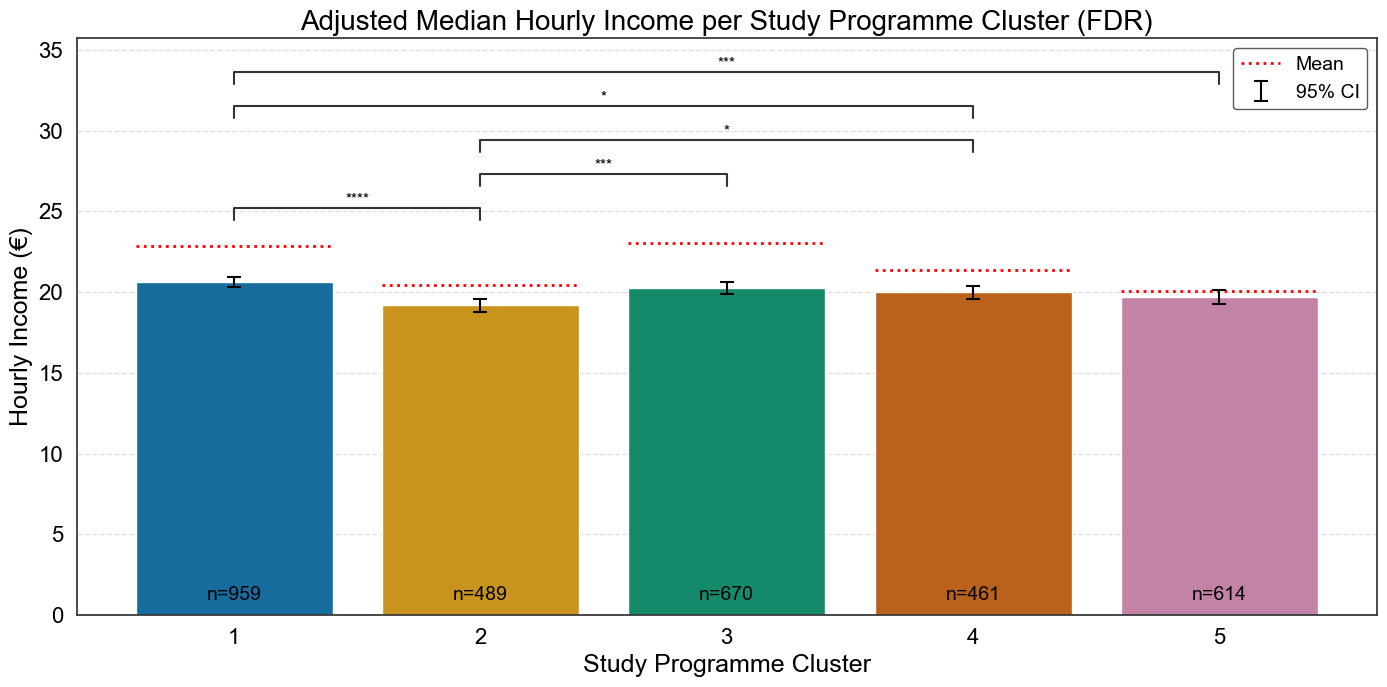

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:2.669e-07
2 vs. 3: Custom statistical test, P_val:1.081e-03
2 vs. 4: Custom statistical test, P_val:3.973e-02
1 vs. 5: Custom statistical test, P_val:1.556e-03


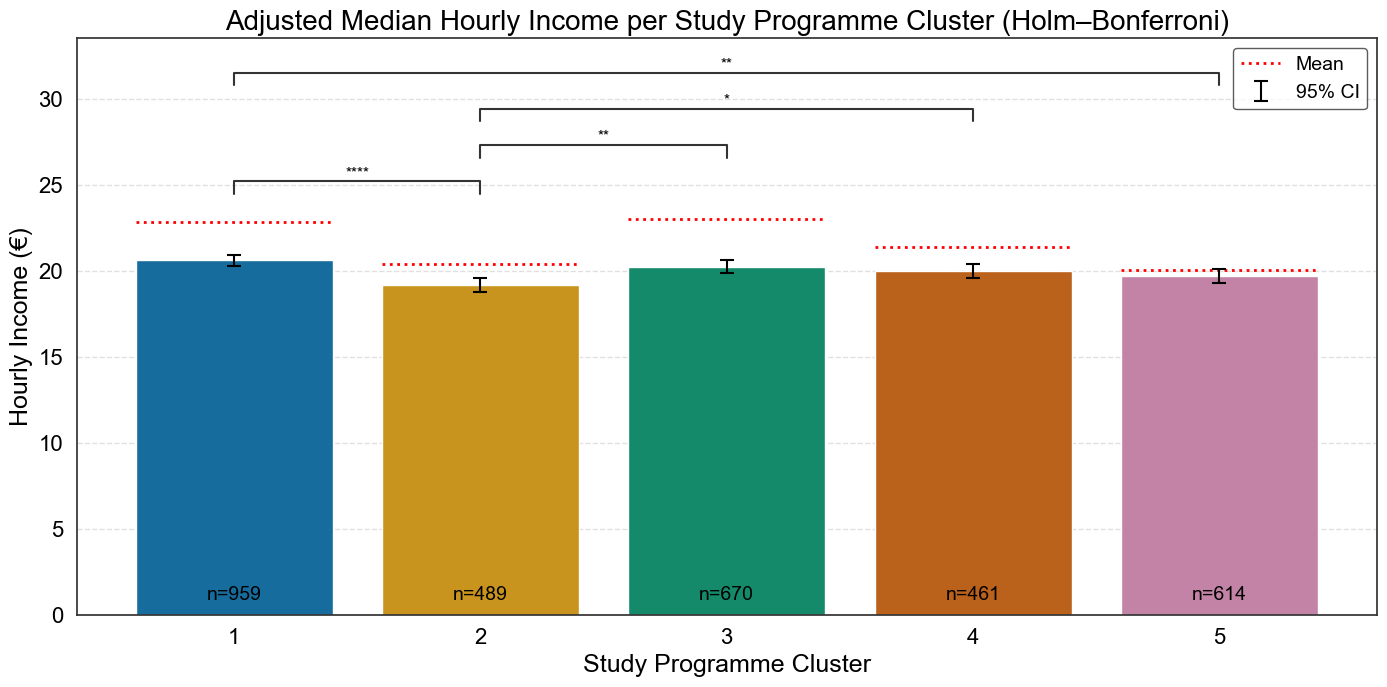

                         QuantReg Regression Results                          
Dep. Variable:                 n_hbiu   Pseudo R-squared:              0.06224
Model:                       QuantReg   Bandwidth:                       1.237
Method:                 Least Squares   Sparsity:                        8.848
Date:                Thu, 11 Jun 2026   No. Observations:                 3193
Time:                        08:37:54   Df Residuals:                     3183
                                        Df Model:                            9
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        11.3440      0.698     16.260      0.000       9.976      12.712
C(matched_study_cluster)[T.2]    -1.4223      0.255     -5.576      0.000      -1.922      -0.922
C(matched_study_cluster)[T.3]    -0.3548      0.257    

In [35]:
# Removing rows of the 'hbo_monitor_with_metadata' DataFrame that have missing values in any of the defined columns.
salary_hourly_income_df = hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "n_hbiu", "study_programme_type", "geslid", "lft"]).copy()

# Ensuring the 'matched_study_cluster' and 'study_programme_type' are treated as categorical variables.
salary_hourly_income_df["matched_study_cluster"] = salary_hourly_income_df["matched_study_cluster"].astype("category")
salary_hourly_income_df["study_programme_type"] = salary_hourly_income_df["study_programme_type"].astype("category")

# Calculating the age of the study programmes.
hbo_monitor_data_reference_year = 2024
salary_hourly_income_df["programme_age"] = hbo_monitor_data_reference_year - salary_hourly_income_df["Datum begin opleiding"].astype(int)
salary_hourly_income_df["programme_age_centered"] = (salary_hourly_income_df["programme_age"] - salary_hourly_income_df["programme_age"].mean())

# Fitting a median-based quantile regression by calling the function 'quantreg' with both the cluster 'matched_study_cluster' and 'study_programme_type' as predictors of hourly income 'n_hbiu'.
model_hourly_income = quantreg("n_hbiu ~ C(matched_study_cluster) + C(study_programme_type) + geslid + lft + programme_age_centered", data=salary_hourly_income_df).fit(q=0.5)

# Extracting the model coefficients, the intercept, and the list of all unique cluster categories.
params_hourly_income = model_hourly_income.params
intercept_hourly_income = params_hourly_income["Intercept"]
clusters_hourly_income = salary_hourly_income_df["matched_study_cluster"].cat.categories

# Generating all possible pairs of clusters.
cluster_hourly_income_pairs = list(combinations(clusters_hourly_income, 2))

# Extracting the reference cluster used internally by statsmodels (the first category).
reference_cluster = clusters_hourly_income[0]

# Defining a helper function that computes regression-based p-values between two clusters.
def regression_cluster_pvalue(c1, c2):

    # If one of the clusters is the reference category, the hypothesis simplifies.
    if c1 == reference_cluster:
        hypothesis = f"C(matched_study_cluster)[T.{c2}] = 0"
    elif c2 == reference_cluster:
        hypothesis = f"C(matched_study_cluster)[T.{c1}] = 0"
    else:
        hypothesis = f"C(matched_study_cluster)[T.{c1}] - C(matched_study_cluster)[T.{c2}] = 0"

    # Performing the regression contrast test by calling the function 't_test()'.
    test_result = model_hourly_income.t_test(hypothesis)

    # Extracting the p-value from the test result.
    pval = float(test_result.pvalue)

    return pval

    
# Defining a helper function to generate the annotated bar plots.
def plot_hourly_income(title, filename, significant_pairs, significant_pvals):

    # Creating a figure featuring a bar plot of the adjusted predicted median hourly income per cluster.
    plt.figure(figsize=(14, 7))

    # Defining the cluster order once, so the bar order and annotations match exactly.
    cluster_order = sorted(clusters_hourly_income, key=lambda x: int(x))

    # Creating a prediction dataset at common covariate values.
    prediction_df = pd.DataFrame({
        "matched_study_cluster": cluster_order,
        "study_programme_type": [salary_hourly_income_df["study_programme_type"].mode()[0]] * len(cluster_order),
        "geslid": [salary_hourly_income_df["geslid"].mode()[0]] * len(cluster_order),
        "lft": [salary_hourly_income_df["lft"].mean()] * len(cluster_order),
        "programme_age_centered": [0] * len(cluster_order)
    })

    # Ensuring the matched study-cluster variable in the prediction dataset matches the fitted model categories.
    prediction_df["matched_study_cluster"] = pd.Categorical(
        prediction_df["matched_study_cluster"],
        categories=cluster_order,
        ordered=True
    )

    # Ensuring the study-programme type variable in the prediction dataset matches the fitted model categories.
    prediction_df["study_programme_type"] = pd.Categorical(
        prediction_df["study_programme_type"],
        categories=salary_hourly_income_df["study_programme_type"].cat.categories
    )

    # Computing the adjusted predicted median hourly income per cluster from the quantile regression model.
    prediction_df["predicted_median_income"] = model_hourly_income.predict(prediction_df)

    # Extracting the fitted model design information so the prediction design matrix uses the exact same encoding as the fitted model.
    design_info_hourly_income = model_hourly_income.model.data.design_info

    # Constructing the prediction design matrix from the prediction dataset.
    prediction_design_matrix = build_design_matrices(
        [design_info_hourly_income],
        prediction_df,
        return_type="dataframe"
    )[0]

    # Reordering the prediction design matrix columns so they exactly match the fitted parameter order.
    prediction_design_matrix = prediction_design_matrix[model_hourly_income.params.index]

    # Extracting the covariance matrix of the fitted quantile-regression coefficients.
    covariance_matrix_hourly_income = model_hourly_income.cov_params()

    # Converting the covariance matrix to a DataFrame if needed, so row and column alignment is explicit.
    if not isinstance(covariance_matrix_hourly_income, pd.DataFrame):
        covariance_matrix_hourly_income = pd.DataFrame(
            covariance_matrix_hourly_income,
            index=model_hourly_income.params.index,
            columns=model_hourly_income.params.index
        )

    # Reordering the covariance matrix so it exactly matches the fitted parameter order.
    covariance_matrix_hourly_income = covariance_matrix_hourly_income.loc[
        model_hourly_income.params.index,
        model_hourly_income.params.index
    ]

    # Calculating the variance of each adjusted predicted median using x'Cov(beta)x.
    prediction_variances = np.einsum(
        "ij,jk,ik->i",
        prediction_design_matrix.to_numpy(),
        covariance_matrix_hourly_income.to_numpy(),
        prediction_design_matrix.to_numpy()
    )

    # Avoiding numerical issues by forcing any tiny negative variances to zero.
    prediction_variances = np.maximum(prediction_variances, 0)

    # Calculating the standard error of each adjusted predicted median.
    prediction_df["prediction_standard_error"] = np.sqrt(prediction_variances)

    # Defining the critical value for a pointwise 95% confidence interval.
    critical_value_95 = stats.norm.ppf(0.975)

    # Calculating the lower bound of the pointwise 95% confidence interval.
    prediction_df["ci_lower"] = (
        prediction_df["predicted_median_income"] -
        critical_value_95 * prediction_df["prediction_standard_error"]
    )

    # Calculating the upper bound of the pointwise 95% confidence interval.
    prediction_df["ci_upper"] = (
        prediction_df["predicted_median_income"] +
        critical_value_95 * prediction_df["prediction_standard_error"]
    )

    # Calculating the distance from the predicted median to the lower confidence-interval bound.
    prediction_df["ci_lower_error"] = (
        prediction_df["predicted_median_income"] - prediction_df["ci_lower"]
    )

    # Calculating the distance from the predicted median to the upper confidence-interval bound.
    prediction_df["ci_upper_error"] = (
        prediction_df["ci_upper"] - prediction_df["predicted_median_income"]
    )

    # Creating the adjusted bar plot.
    ax = sns.barplot(
        data=prediction_df,
        x="matched_study_cluster",
        y="predicted_median_income",
        order=cluster_order,
        ci=None,
        palette=get_colorblind_palette(len(cluster_order))
    )

    # Extracting the x-axis centre position of each bar.
    bar_center_positions = [
        bar_patch.get_x() + bar_patch.get_width() / 2
        for bar_patch in ax.patches
    ]

    # Adding pointwise 95% confidence intervals to the adjusted median-income bars.
    ax.errorbar(
        x=bar_center_positions,
        y=prediction_df["predicted_median_income"],
        yerr=[
            prediction_df["ci_lower_error"],
            prediction_df["ci_upper_error"]
        ],
        fmt="none",
        color="black",
        capsize=5,
        capthick=1.5,
        elinewidth=1.5,
        zorder=10,
        label="95% CI"
    )

    # Looping over the bars and clusters in the exact plotted order.
    for i, (cluster, bar_patch) in enumerate(zip(cluster_order, ax.patches)):

        # Selecting the income data for the current cluster.
        cluster_data = salary_hourly_income_df[
            salary_hourly_income_df["matched_study_cluster"].astype(str) == str(cluster)
        ]

        # Computing the sample size for the current cluster.
        n = cluster_data.shape[0]

        # Computing the mean for the current cluster, which will be shown as a dotted red line.
        mean = cluster_data["n_hbiu"].mean()

        # Extracting the x-coordinate of the centre of the current bar.
        bar_center_x = bar_patch.get_x() + bar_patch.get_width() / 2

        # Writing the sample size inside the bar, positioned near the bottom of the bar.
        ax.annotate(
            f"n={n}",
            xy=(bar_center_x, 0),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color="white",
            fontsize=14,
            zorder=11
        )

        # Extracting the left x position of the current bar.
        bar_x_left = bar_patch.get_x()

        # Extracting the width of the current bar.
        bar_width = bar_patch.get_width()

        # Computing the right x position of the current bar.
        bar_x_right = bar_x_left + bar_width

        # Drawing the mean as a red dotted horizontal line segment across the width of the bar.
        ax.hlines(
            y=mean,
            xmin=bar_x_left,
            xmax=bar_x_right,
            colors="red",
            linestyles="dotted",
            linewidth=2,
            label="Mean" if i == 0 else None,
            zorder=9
        )

    # Creating an Annotator object to add significant brackets between cluster pairs.
    if len(significant_pairs) > 0:

        # Creating the annotation object.
        annotator = Annotator(
            ax,
            pairs=significant_pairs,
            data=prediction_df,
            x="matched_study_cluster",
            y="predicted_median_income",
            order=cluster_order
        )

        # Configuring the annotation style to use custom p-values, so no internal test is run.
        annotator.configure(
            test=None,
            text_format="star",
            comparisons_correction=None,
            line_height=0.03,
            verbose=1
        )

        # Setting the externally computed corrected p-values and drawing the annotations.
        annotator.set_pvalues_and_annotate(significant_pvals)

    # Adding a legend entry for the mean line and confidence intervals.
    ax.legend(
        loc="upper right",
        fontsize=14
    )

    # Setting the title of the plot.
    plt.title(title, fontsize=20)

    # Setting the x-axis label.
    plt.xlabel("Study Programme Cluster", fontsize=18)

    # Setting the y-axis label.
    plt.ylabel("Hourly Income (€)", fontsize=18)

    # Increasing the size of the x-axis and y-axis tick labels.
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    # Ensuring the y-axis starts at zero while allowing the annotations to determine the upper limit.
    ax.set_ylim(bottom=0)

    # Adding a horizontal grid for readability.
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Ensuring that the grid is drawn behind the bars.
    ax.set_axisbelow(True)

    # Tightening the layout to avoid clipping.
    plt.tight_layout()

    # Ensuring the output directory exists.
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    # Saving the plot to disk.
    save_manuscript_figure(
        filename,
        bbox_inches="tight",
        dpi=300,
        facecolor="white"
    )

    # Showing the plot.
    plt.show()

    # Closing the figure to avoid memory buildup in loops.
    plt.close()


# --------------------- 0. No Multiple-Testing Correction ---------------------
# Looping over every cluster pair and calculating whether the difference in hourly incomes is significant without correction.
significant_pairs_uncorrected = []
significant_pvals_uncorrected = []

for c1, c2 in cluster_hourly_income_pairs:

    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)

    # If the raw p-value 'pval' is below 0.05, the cluster pair is stored as significant.
    if pval < 0.05:
        significant_pairs_uncorrected.append((c1, c2))
        significant_pvals_uncorrected.append(pval)

# Plotting the hourly income when no correction is used by calling the function 'plot_hourly_income()'.
plot_hourly_income(
    title="Adjusted Median Hourly Income per Study Programme Cluster (Uncorrected)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_hourly_income_per_study_cluster_uncorrected.png",
    significant_pairs=significant_pairs_uncorrected,
    significant_pvals=significant_pvals_uncorrected
)


# --------------------- 1. Bonferroni Correction ---------------------
# Looping over every cluster pair present in the 'cluster_hourly_income_pairs' and calculating whether the difference in hourly incomes is significant.
significant_pairs_bonf = []
significant_pvals_bonf = []

for c1, c2 in cluster_hourly_income_pairs:

    # Computing the Bonferroni corrected p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    pval_corr = min(pval * len(cluster_hourly_income_pairs), 1.0)

    # If the corrected p-value 'pval_corr' is below 0.05, the cluster pair is stored as significant.
    if pval_corr < 0.05:
        significant_pairs_bonf.append((c1, c2))
        significant_pvals_bonf.append(pval_corr)

# Plotting the hourly income when Bonferroni correction is used by calling the function 'plot_hourly_income()'.
plot_hourly_income(
    title="Mean Hourly Income per Study Programme Cluster (Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_hourly_income_per_study_cluster_bonferroni.png",
    significant_pairs=significant_pairs_bonf,
    significant_pvals=significant_pvals_bonf
)


# --------------------- 2. Benjamini–Hochberg (FDR) Correction ---------------------
# Looping over every cluster pair and calculating Welch's t-test p-values.
raw_pvals = []
pair_list = []

for c1, c2 in cluster_hourly_income_pairs:

    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    raw_pvals.append(pval)
    pair_list.append((c1, c2))

# Applying Benjamini–Hochberg (FDR) correction to the p-values.
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")

# Collecting the significant pairs after correction.
significant_pairs_fdr = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_fdr = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the hourly income when FDR correction is used by calling the function 'plot_hourly_income()'.
plot_hourly_income(
    title="Adjusted Median Hourly Income per Study Programme Cluster (FDR)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_hourly_income_per_study_cluster_fdr.png",
    significant_pairs=significant_pairs_fdr,
    significant_pvals=significant_pvals_fdr
)


# --------------------- 3. Holm–Bonferroni Correction ---------------------
# Applying Holm–Bonferroni correction to the same raw p-values.
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="holm")

# Collecting the significant pairs after Holm correction.
significant_pairs_holm = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_holm = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the hourly income when Holm-Bonferroni correction is used by calling the function 'plot_hourly_income()'.
plot_hourly_income(
    title="Adjusted Median Hourly Income per Study Programme Cluster (Holm–Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_hourly_income_per_study_cluster_holm.png",
    significant_pairs=significant_pairs_holm,
    significant_pvals=significant_pvals_holm
)

# Printing a summary of the 'model_hourly_income'.
print(model_hourly_income.summary())

<br></br><br></br>

### Job Search Time Per Study Programme Cluster

In this section, the analysis explores how the job search times differ across study programme clusters. Using the 'hbo_monitor_with_metadata' DataFrame, it focuses on job search time in months (iw4). Respondents are grouped by their assigned study programme cluster (matched_study_cluster), and for each cluster, the mean job search time values are calculated. This provides insight into which clusters are associated with higher or lower post-graduation job search times.
<br></br>

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:5.472e-22
2 vs. 3: Custom statistical test, P_val:2.009e-08
3 vs. 4: Custom statistical test, P_val:1.009e-03
4 vs. 5: Custom statistical test, P_val:3.448e-04
1 vs. 3: Custom statistical test, P_val:3.325e-04
2 vs. 4: Custom statistical test, P_val:7.812e-18
2 vs. 5: Custom statistical test, P_val:3.388e-08
1 vs. 5: Custom statistical test, P_val:5.555e-05


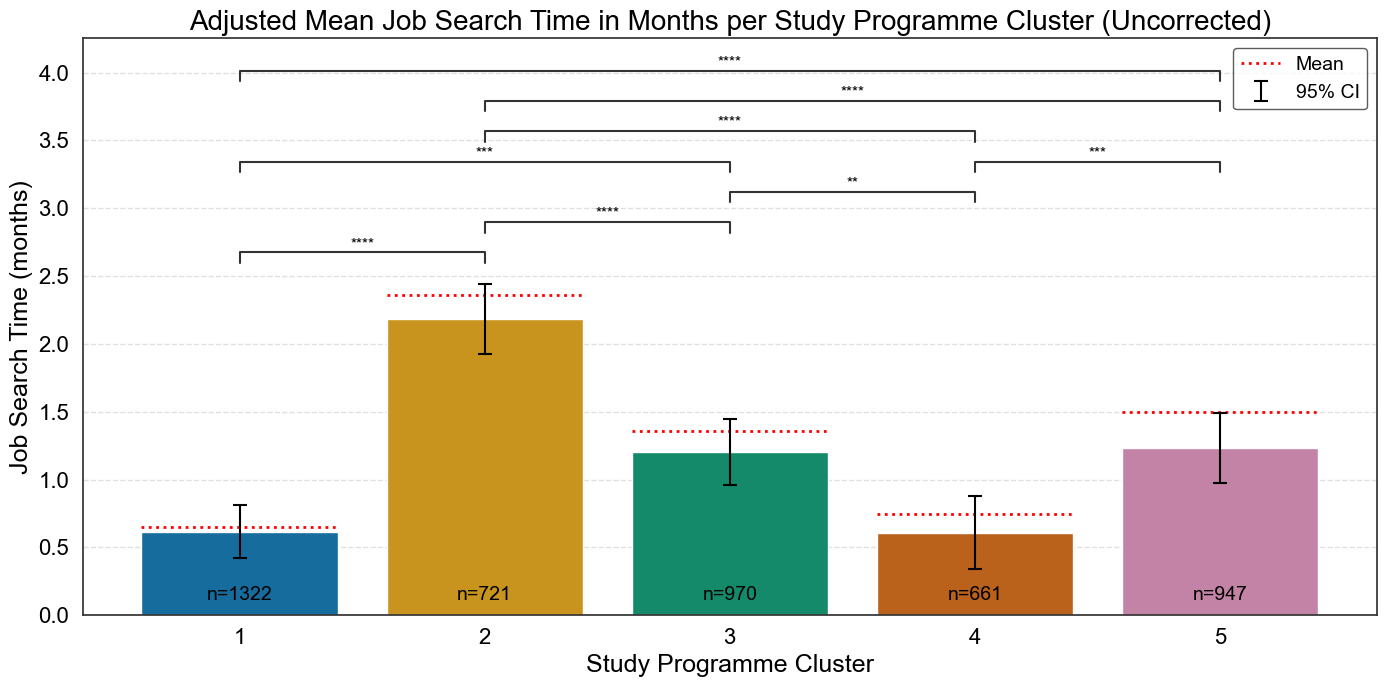

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:5.472e-21
2 vs. 3: Custom statistical test, P_val:2.009e-07
3 vs. 4: Custom statistical test, P_val:1.009e-02
4 vs. 5: Custom statistical test, P_val:3.448e-03
1 vs. 3: Custom statistical test, P_val:3.325e-03
2 vs. 4: Custom statistical test, P_val:7.812e-17
2 vs. 5: Custom statistical test, P_val:3.388e-07
1 vs. 5: Custom statistical test, P_val:5.555e-04


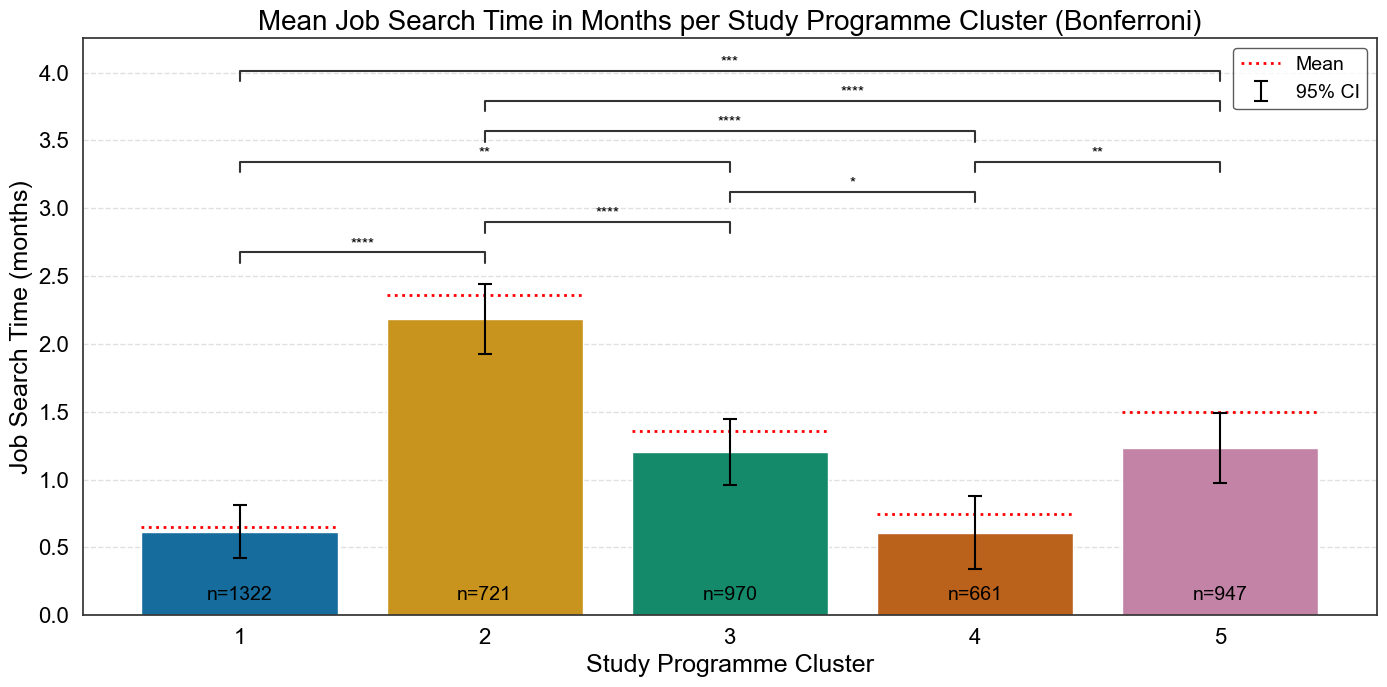

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:5.472e-21
2 vs. 3: Custom statistical test, P_val:6.696e-08
3 vs. 4: Custom statistical test, P_val:1.262e-03
4 vs. 5: Custom statistical test, P_val:4.926e-04
1 vs. 3: Custom statistical test, P_val:4.926e-04
2 vs. 4: Custom statistical test, P_val:3.906e-17
2 vs. 5: Custom statistical test, P_val:8.470e-08
1 vs. 5: Custom statistical test, P_val:1.111e-04


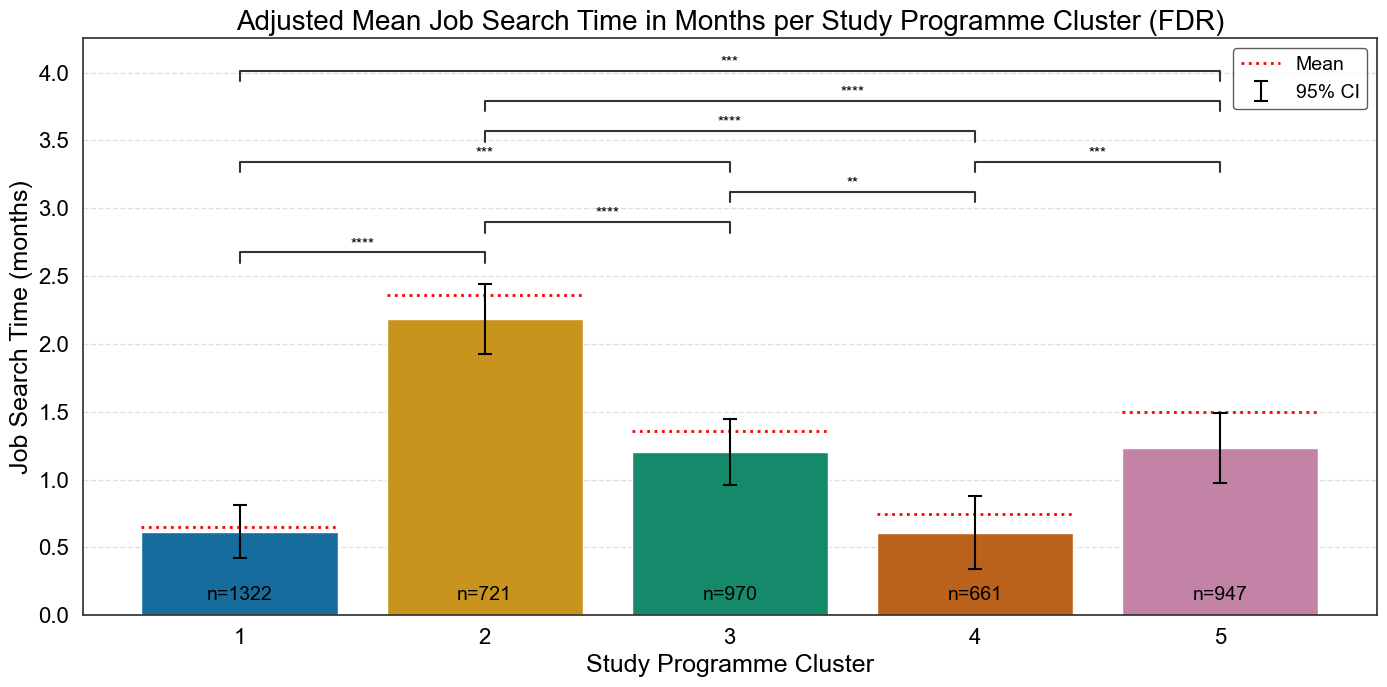

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:5.472e-21
2 vs. 3: Custom statistical test, P_val:1.607e-07
3 vs. 4: Custom statistical test, P_val:3.028e-03
4 vs. 5: Custom statistical test, P_val:1.662e-03
1 vs. 3: Custom statistical test, P_val:1.662e-03
2 vs. 4: Custom statistical test, P_val:7.031e-17
2 vs. 5: Custom statistical test, P_val:2.372e-07
1 vs. 5: Custom statistical test, P_val:3.333e-04


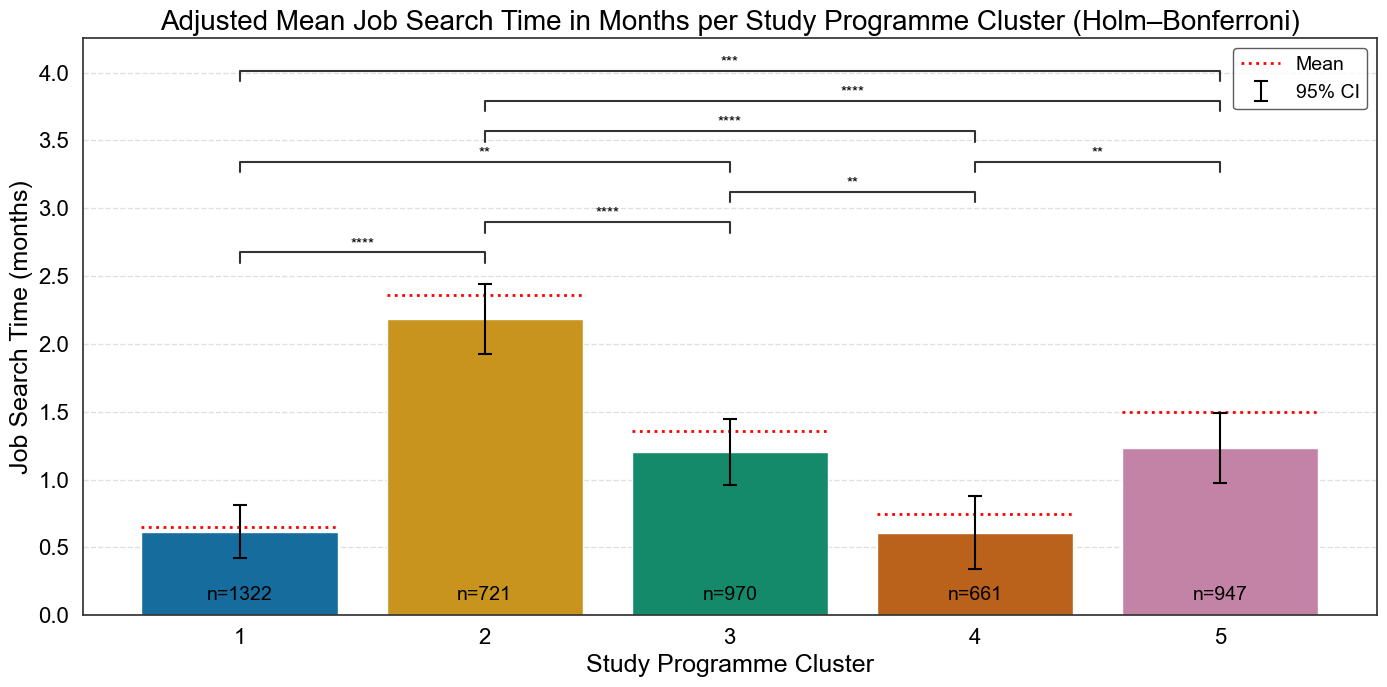

                            OLS Regression Results                            
Dep. Variable:                    iw4   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     18.10
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           6.72e-30
Time:                        08:38:08   Log-Likelihood:                -12168.
No. Observations:                4621   AIC:                         2.436e+04
Df Residuals:                    4611   BIC:                         2.442e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [36]:
# Removing rows of the 'hbo_monitor_with_metadata' DataFrame that have missing values in any of the defined columns.
job_search_months_df = hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "iw4", "study_programme_type", "geslid", "lft"]).copy()

# Ensuring the 'matched_study_cluster' and 'study_programme_type' are treated as categorical variables.
job_search_months_df["matched_study_cluster"] = job_search_months_df["matched_study_cluster"].astype("category")
job_search_months_df["study_programme_type"] = job_search_months_df["study_programme_type"].astype("category")

# Calculating the age of the study programmes.
hbo_monitor_data_reference_year = 2024
job_search_months_df["programme_age"] = hbo_monitor_data_reference_year - job_search_months_df["Datum begin opleiding"].astype(int)
job_search_months_df["programme_age_centered"] = (job_search_months_df["programme_age"] - job_search_months_df["programme_age"].mean())

# Fitting a mean-based linear regression by calling the function 'ols' with both the cluster 'matched_study_cluster' and 'study_programme_type' as predictors of job search time in months 'iw4'.
model_job_search_months = ols("iw4 ~ C(matched_study_cluster) + C(study_programme_type) + geslid + lft + programme_age_centered", data=job_search_months_df).fit()

# Extracting the model coefficients, the intercept, and the list of all unique cluster categories.
params_job_search_months = model_job_search_months.params
intercept_job_search_months = params_job_search_months["Intercept"]
clusters_job_search_months = job_search_months_df["matched_study_cluster"].cat.categories

# Generating all possible pairs of clusters.
cluster_job_search_months_pairs = list(combinations(clusters_job_search_months, 2))

# Extracting the reference cluster used internally by statsmodels (the first category).
reference_cluster = clusters_job_search_months[0]

# Defining a helper function that computes regression-based p-values between two clusters.
def regression_cluster_pvalue(c1, c2):

    # If one of the clusters is the reference category, the hypothesis simplifies.
    if c1 == reference_cluster:
        hypothesis = f"C(matched_study_cluster)[T.{c2}] = 0"
    elif c2 == reference_cluster:
        hypothesis = f"C(matched_study_cluster)[T.{c1}] = 0"
    else:
        hypothesis = f"C(matched_study_cluster)[T.{c1}] - C(matched_study_cluster)[T.{c2}] = 0"

    # Performing the regression contrast test by calling the function 't_test()'.
    test_result = model_job_search_months.t_test(hypothesis)

    # Extracting the p-value from the test result.
    pval = float(test_result.pvalue)

    return pval


# Defining a helper function to generate the annotated bar plots.
def plot_job_search_months(title, filename, significant_pairs, significant_pvals):
    
    # Creating a figure featuring a bar plot of the adjusted predicted mean job search time in months per cluster.
    plt.figure(figsize=(14, 7))
    
    # Defining the cluster order once, so the bar order and annotations match exactly.
    cluster_order = sorted(clusters_job_search_months, key=lambda x: int(x))
    
    # Creating a prediction dataset at common covariate values.
    prediction_df = pd.DataFrame({
        "matched_study_cluster": cluster_order,
        "study_programme_type": [job_search_months_df["study_programme_type"].mode()[0]] * len(cluster_order),
        "geslid": [job_search_months_df["geslid"].mode()[0]] * len(cluster_order),
        "lft": [job_search_months_df["lft"].mean()] * len(cluster_order),
        "programme_age_centered": [0] * len(cluster_order)
    })
    
    # Ensuring the matched study-cluster variable in the prediction dataset matches the fitted model categories.
    prediction_df["matched_study_cluster"] = pd.Categorical(
        prediction_df["matched_study_cluster"],
        categories=cluster_order,
        ordered=True
    )

    # Ensuring the study-programme type variable in the prediction dataset matches the fitted model categories.
    prediction_df["study_programme_type"] = pd.Categorical(
        prediction_df["study_programme_type"],
        categories=job_search_months_df["study_programme_type"].cat.categories
    )
    
    # Computing the adjusted predicted mean job search time per cluster from the linear regression model.
    prediction_df["predicted_job_search_months"] = model_job_search_months.predict(prediction_df)

    # Computing pointwise 95% confidence intervals around the adjusted predicted mean job search time.
    prediction_summary_frame = model_job_search_months.get_prediction(
        prediction_df
    ).summary_frame(alpha=0.05)

    # Adding the lower confidence-interval bound to the prediction DataFrame.
    prediction_df["ci_lower"] = prediction_summary_frame["mean_ci_lower"].values

    # Adding the upper confidence-interval bound to the prediction DataFrame.
    prediction_df["ci_upper"] = prediction_summary_frame["mean_ci_upper"].values

    # Calculating the distance from the predicted mean to the lower confidence-interval bound.
    prediction_df["ci_lower_error"] = (
        prediction_df["predicted_job_search_months"] - prediction_df["ci_lower"]
    )

    # Calculating the distance from the predicted mean to the upper confidence-interval bound.
    prediction_df["ci_upper_error"] = (
        prediction_df["ci_upper"] - prediction_df["predicted_job_search_months"]
    )
    
    # Creating the adjusted bar plot.
    ax = sns.barplot(
        data=prediction_df,
        x="matched_study_cluster",
        y="predicted_job_search_months",
        order=cluster_order,
        ci=None,
        palette=get_colorblind_palette(len(cluster_order))
    )

    # Extracting the x-axis centre position of each bar.
    bar_center_positions = [
        bar_patch.get_x() + bar_patch.get_width() / 2
        for bar_patch in ax.patches
    ]

    # Adding pointwise 95% confidence intervals to the adjusted mean job-search-time bars.
    ax.errorbar(
        x=bar_center_positions,
        y=prediction_df["predicted_job_search_months"],
        yerr=[
            prediction_df["ci_lower_error"],
            prediction_df["ci_upper_error"]
        ],
        fmt="none",
        color="black",
        capsize=5,
        capthick=1.5,
        elinewidth=1.5,
        zorder=10,
        label="95% CI"
    )

    # Looping over the bars and clusters in the exact plotted order.
    for i, (cluster, bar_patch) in enumerate(zip(cluster_order, ax.patches)):

        # Selecting the job-search data for the current cluster.
        cluster_data = job_search_months_df[
            job_search_months_df["matched_study_cluster"].astype(str) == str(cluster)
        ]

        # Computing the sample size for the current cluster.
        n = cluster_data.shape[0]

        # Computing the raw mean for the current cluster, which will be shown as a dotted red line.
        mean = cluster_data["iw4"].mean()

        # Extracting the x-coordinate of the centre of the current bar.
        bar_center_x = bar_patch.get_x() + bar_patch.get_width() / 2

        # Writing the sample size inside the bar, positioned near the bottom of the bar.
        ax.annotate(
            f"n={n}",
            xy=(bar_center_x, 0),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color="white",
            fontsize=14,
            zorder=11
        )

        # Extracting the left x position of the current bar.
        bar_x_left = bar_patch.get_x()

        # Extracting the width of the current bar.
        bar_width = bar_patch.get_width()

        # Computing the right x position of the current bar.
        bar_x_right = bar_x_left + bar_width

        # Drawing the raw mean as a red dotted horizontal line segment across the width of the bar.
        ax.hlines(
            y=mean,
            xmin=bar_x_left,
            xmax=bar_x_right,
            colors="red",
            linestyles="dotted",
            linewidth=2,
            label="Mean" if i == 0 else None,
            zorder=9
        )

    # Creating an Annotator object to add significant brackets between cluster pairs.
    if len(significant_pairs) > 0:

        # Creating the annotation object.
        annotator = Annotator(
            ax,
            pairs=significant_pairs,
            data=prediction_df,
            x="matched_study_cluster",
            y="predicted_job_search_months",
            order=cluster_order
        )
    
        # Configuring the annotation style to use custom p-values, so no internal test is run.
        annotator.configure(
            test=None,
            text_format="star",
            comparisons_correction=None,
            line_height=0.03,
            verbose=1
        )
    
        # Setting the externally computed corrected p-values and drawing the annotations.
        annotator.set_pvalues_and_annotate(significant_pvals)
    
    # Adding a legend entry for the mean line and confidence intervals.
    ax.legend(
        loc="upper right",
        fontsize=14
    )

    # Setting the title of the plot.
    plt.title(title, fontsize=20)

    # Setting the x-axis label.
    plt.xlabel("Study Programme Cluster", fontsize=18)

    # Setting the y-axis label.
    plt.ylabel("Job Search Time (months)", fontsize=18)

    # Increasing the size of the x-axis and y-axis tick labels.
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    # Ensuring the y-axis starts at zero while allowing the annotations to determine the upper limit.
    ax.set_ylim(bottom=0)

    # Adding a horizontal grid for readability.
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Ensuring that the grid is drawn behind the bars.
    ax.set_axisbelow(True)

    # Tightening the layout to avoid clipping.
    plt.tight_layout()

    # Ensuring the output directory exists.
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    # Saving the plot to disk.
    save_manuscript_figure(
        filename,
        bbox_inches="tight",
        dpi=300,
        facecolor="white"
    )

    # Showing the plot.
    plt.show()

    # Closing the figure to avoid memory buildup in loops.
    plt.close()


# --------------------- 0. No Multiple-Testing Correction ---------------------
# Looping over every cluster pair and calculating whether the difference in job search times is significant without correction.
significant_pairs_uncorrected = []
significant_pvals_uncorrected = []

for c1, c2 in cluster_job_search_months_pairs:

    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)

    # If the raw p-value 'pval' is below 0.05, the cluster pair is stored as significant.
    if pval < 0.05:
        significant_pairs_uncorrected.append((c1, c2))
        significant_pvals_uncorrected.append(pval)

# Plotting the job search time in months when no correction is used by calling the function 'plot_job_search_months()'.
plot_job_search_months(
    title="Adjusted Mean Job Search Time in Months per Study Programme Cluster (Uncorrected)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_job_search_months_per_study_cluster_uncorrected.png",
    significant_pairs=significant_pairs_uncorrected,
    significant_pvals=significant_pvals_uncorrected
)


# --------------------- 1. Bonferroni Correction ---------------------
# Looping over every cluster pair present in the 'cluster_job_search_months_pairs' and calculating whether the difference in job search times is significant.
significant_pairs_bonf = []
significant_pvals_bonf = []

for c1, c2 in cluster_job_search_months_pairs:

    # Computing the Bonferroni corrected p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    pval_corr = min(pval * len(cluster_job_search_months_pairs), 1.0)

    # If the corrected p-value 'pval_corr' is below 0.05, the cluster pair is stored as significant.
    if pval_corr < 0.05:
        significant_pairs_bonf.append((c1, c2))
        significant_pvals_bonf.append(pval_corr)

# Plotting the job search times in months when Bonferroni correction is used by calling the function 'plot_job_search_months()'.
plot_job_search_months(
    title="Mean Job Search Time in Months per Study Programme Cluster (Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_job_search_months_per_study_cluster_bonferroni.png",
    significant_pairs=significant_pairs_bonf,
    significant_pvals=significant_pvals_bonf
)


# --------------------- 2. Benjamini–Hochberg (FDR) Correction ---------------------
# Looping over every cluster pair and calculating Welch's t-test p-values.
raw_pvals = []
pair_list = []

for c1, c2 in cluster_job_search_months_pairs:
    
    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    raw_pvals.append(pval)
    pair_list.append((c1, c2))

# Applying Benjamini–Hochberg (FDR) correction to the p-values.
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")

# Collecting the significant pairs after correction.
significant_pairs_fdr = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_fdr = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the job search times in months when FDR correction is used by calling the function 'plot_job_search_months()'.
plot_job_search_months(
    title="Adjusted Mean Job Search Time in Months per Study Programme Cluster (FDR)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_job_search_months_per_study_cluster_fdr.png",
    significant_pairs=significant_pairs_fdr,
    significant_pvals=significant_pvals_fdr
)


# --------------------- 3. Holm–Bonferroni Correction ---------------------
# Applying Holm–Bonferroni correction to the same raw p-values.
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="holm")

# Collecting the significant pairs after Holm correction.
significant_pairs_holm = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_holm = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the job search times in months when Holm-Bonferroni correction is used by calling the function 'plot_job_search_months()'.
plot_job_search_months(
    title="Adjusted Mean Job Search Time in Months per Study Programme Cluster (Holm–Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/adjusted_median_job_search_months_per_study_cluster_holm.png",
    significant_pairs=significant_pairs_holm,
    significant_pvals=significant_pvals_holm
)

# Printing a summary of the 'model_job_search_months'.
print(model_job_search_months.summary())


<br></br><br></br>

### Study Programme Cluster Per Study Programme Age

In this section, the analysis explores how the study programme clusters differ across the ages of the study programmes. Using the 'hbo_monitor_with_metadata' DataFrame, it focuses on the start date of the programme (Datum begin opleiding).
<br></br>

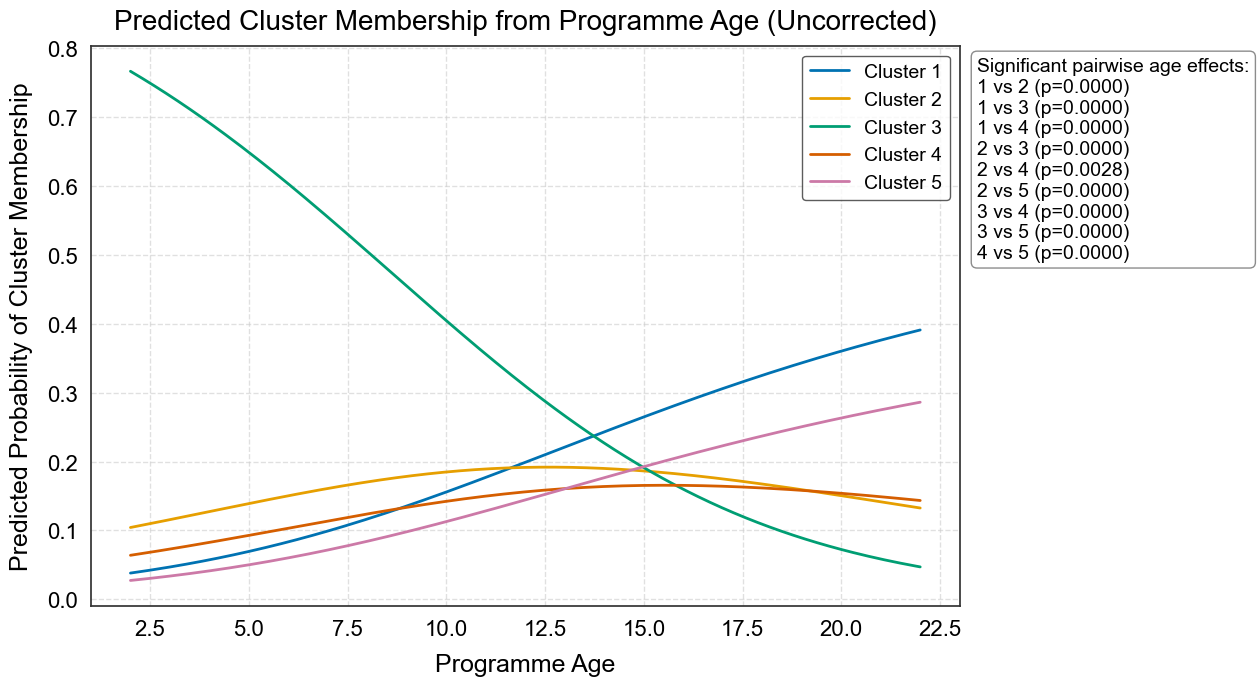

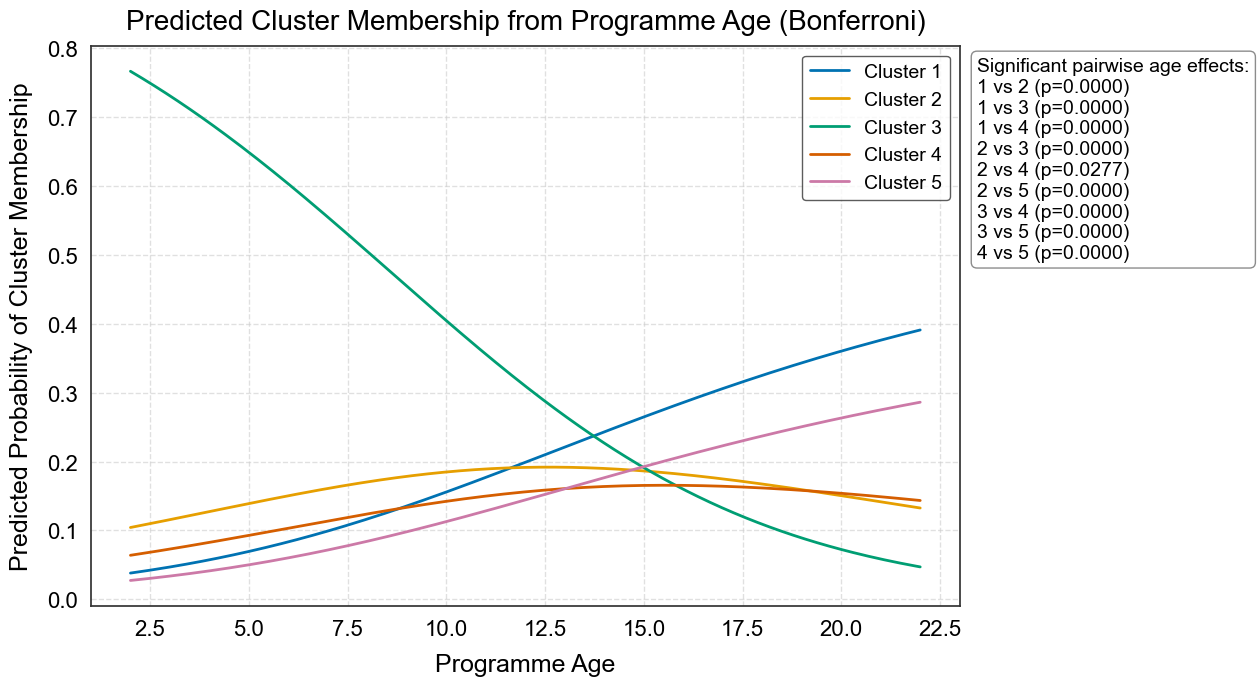

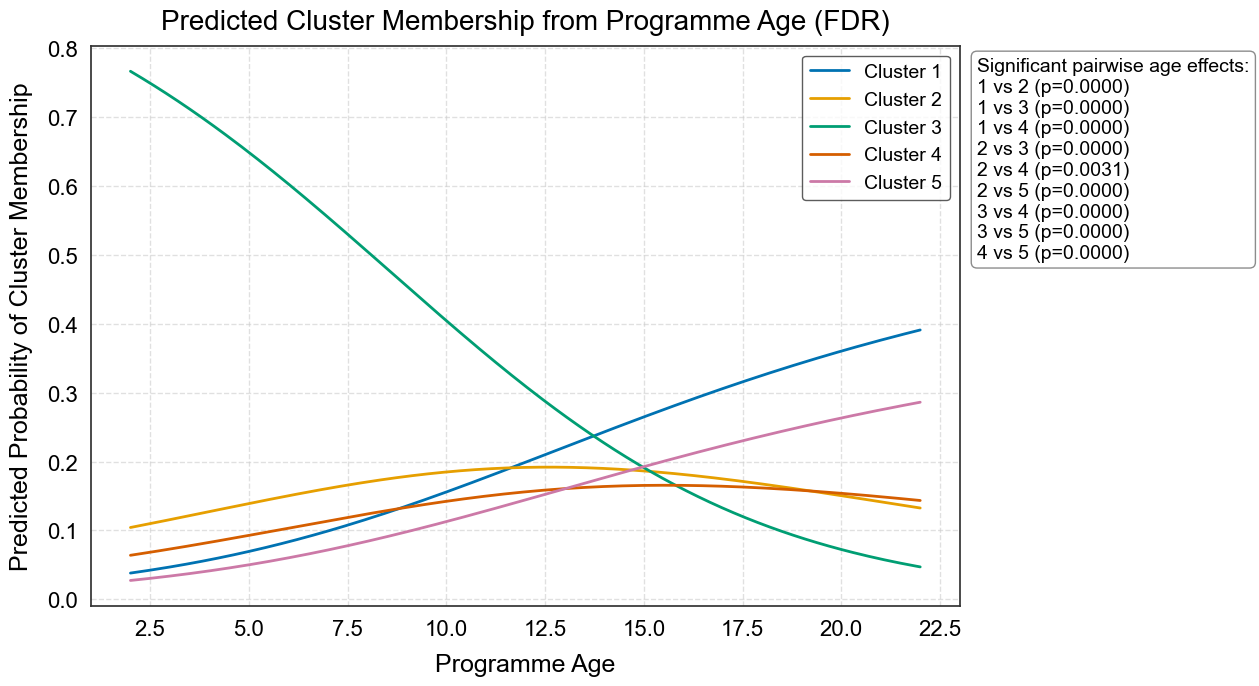

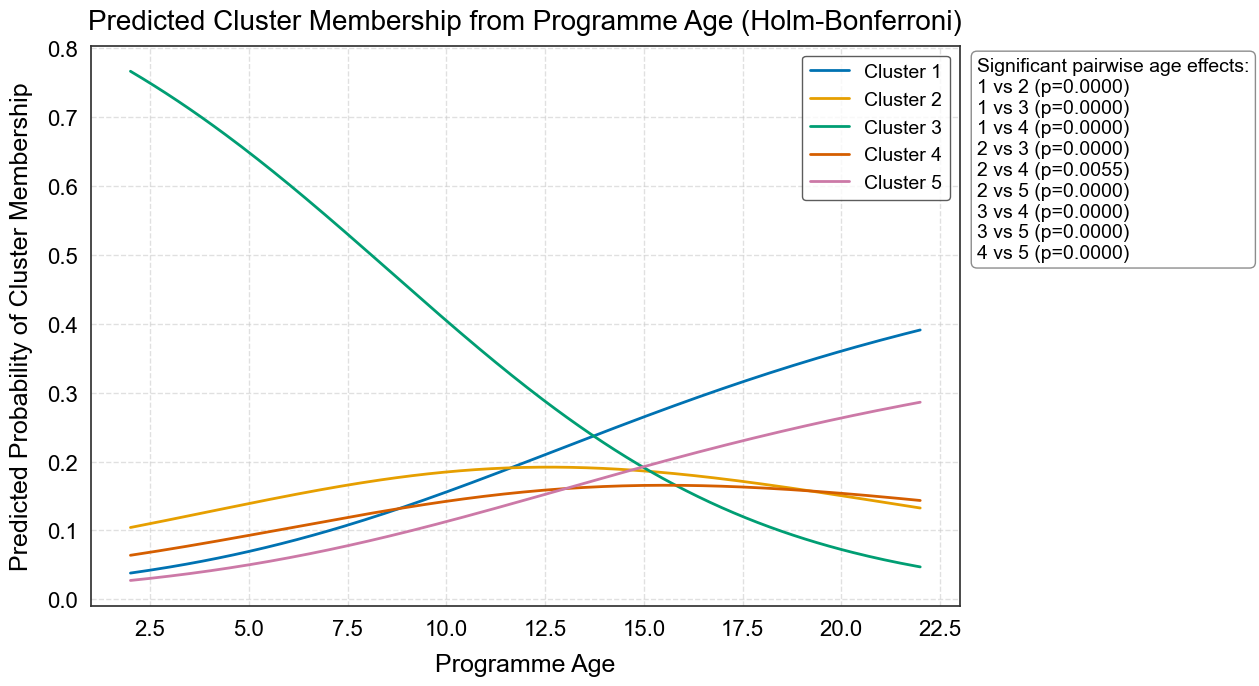

                               0         1         2         3
const                  -0.486190 -0.657059 -0.569109 -0.317150
programme_age_centered -0.104355 -0.255823 -0.075967  0.000867
                              MNLogit Regression Results                              
Dep. Variable:     matched_study_cluster_code   No. Observations:                 4804
Model:                                MNLogit   Df Residuals:                     4796
Method:                                   MLE   Df Model:                            4
Date:                        Thu, 11 Jun 2026   Pseudo R-squ.:                 0.08591
Time:                                08:38:24   Log-Likelihood:                -6937.6
converged:                               True   LL-Null:                       -7589.6
Covariance Type:                    nonrobust   LLR p-value:                4.491e-281
matched_study_cluster_code=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------

In [37]:
# Removing rows of the 'hbo_monitor_with_metadata' DataFrame that have missing values in any of the defined columns.
cluster_programme_age_df = hbo_monitor_with_metadata.dropna(
    subset=["matched_study_cluster", "Datum begin opleiding"]
).copy()

# Ensuring the 'matched_study_cluster' is treated as a categorical variable.
cluster_programme_age_df["matched_study_cluster"] = cluster_programme_age_df["matched_study_cluster"].astype("category")

# Calculating the age of the study programmes.
hbo_monitor_data_reference_year = 2024
cluster_programme_age_df["programme_age"] = (
    hbo_monitor_data_reference_year - cluster_programme_age_df["Datum begin opleiding"].astype(int)
)

# Creating a centred version of programme age.
cluster_programme_age_df["programme_age_centered"] = (
    cluster_programme_age_df["programme_age"] - cluster_programme_age_df["programme_age"].mean()
)

# Creating a numeric version of the cluster variable for multinomial logistic regression.
cluster_programme_age_df["matched_study_cluster_code"] = (
    cluster_programme_age_df["matched_study_cluster"].cat.codes
)

# Extracting the list of all unique cluster categories.
clusters_cluster_membership = cluster_programme_age_df["matched_study_cluster"].cat.categories

# Generating all possible pairs of clusters.
cluster_membership_pairs = list(combinations(clusters_cluster_membership, 2))

# Creating the predictor matrix consisting only of centred programme age.
X_cluster_membership = cluster_programme_age_df[["programme_age_centered"]].copy()

# Adding an intercept column to the predictor matrix.
X_cluster_membership = sm.add_constant(X_cluster_membership)

# Creating the dependent variable for multinomial logistic regression.
y_cluster_membership = cluster_programme_age_df["matched_study_cluster_code"]

# Fitting a multinomial logistic regression by calling the function 'MNLogit' with programme age as the sole predictor of cluster membership.
model_cluster_membership = sm.MNLogit(
    y_cluster_membership,
    X_cluster_membership
).fit(
    method="newton",
    maxiter=200,
    disp=False
)

# Extracting the model coefficients.
params_cluster_membership = model_cluster_membership.params



# Defining a helper function that computes pairwise regression-based p-values between two clusters.
def regression_cluster_pvalue(c1, c2):

    # Selecting only the rows that belong to either cluster 'c1' or cluster 'c2'.
    pair_df = cluster_programme_age_df[
        cluster_programme_age_df["matched_study_cluster"].isin([c1, c2])
    ].copy()

    # Creating a binary outcome in which cluster 'c2' is coded as 1 and cluster 'c1' is coded as 0.
    pair_df["cluster_binary"] = (pair_df["matched_study_cluster"] == c2).astype(int)

    # Creating the predictor matrix for the pairwise logistic regression.
    X_pair = pair_df[["programme_age_centered"]].copy()

    # Adding an intercept column to the predictor matrix.
    X_pair = sm.add_constant(X_pair)

    # Creating the dependent variable for the pairwise logistic regression.
    y_pair = pair_df["cluster_binary"]

    # Fitting the binary logistic regression model for the current pair of clusters.
    pair_model = sm.Logit(
        y_pair,
        X_pair
    ).fit(
        disp=False
    )

    # Extracting the p-value of the programme age effect from the fitted binary logistic regression model.
    pval = float(pair_model.pvalues["programme_age_centered"])

    # Returning the extracted p-value.
    return pval



# Defining a helper function to generate the predicted-probability line plot.
def plot_cluster_membership(title, filename, significant_pairs, significant_pvals):

    # Creating a wider figure featuring line plots of the predicted probability of belonging to each cluster across programme age.
    fig, ax = plt.subplots(figsize=(16, 7), facecolor="white")

    # Setting the axis background to white.
    ax.set_facecolor("white")

    # Creating a sequence of programme ages spanning the observed range in the data.
    age_grid = np.linspace(
        cluster_programme_age_df["programme_age"].min(),
        cluster_programme_age_df["programme_age"].max(),
        200
    )

    # Creating a prediction dataset using the grid values.
    prediction_df = pd.DataFrame({
        "programme_age": age_grid
    })

    # Centering the programme age values in the prediction dataset to match the fitted model.
    prediction_df["programme_age_centered"] = (
        prediction_df["programme_age"] - cluster_programme_age_df["programme_age"].mean()
    )

    # Creating the predictor matrix for prediction.
    X_prediction = prediction_df[["programme_age_centered"]].copy()

    # Adding an intercept column to the prediction matrix.
    X_prediction = sm.add_constant(X_prediction)

    # Computing the predicted probabilities for each cluster from the multinomial logistic regression model.
    predicted_probabilities = model_cluster_membership.predict(X_prediction)

    # Converting the predicted probabilities to a DataFrame if they are returned as a NumPy array.
    if isinstance(predicted_probabilities, np.ndarray):
        predicted_probabilities = pd.DataFrame(predicted_probabilities)

    # Renaming the probability columns so that they correspond to the original cluster labels.
    predicted_probabilities.columns = [
        str(cluster)
        for cluster in clusters_cluster_membership
    ]

    # Defining a colorblind-friendly color palette for the cluster probability curves.
    cluster_color_palette = get_colorblind_palette(
        len(clusters_cluster_membership)
    )

    # Looping over the clusters and plotting the predicted probability curve for each cluster.
    for i, cluster in enumerate(clusters_cluster_membership):

        # Converting the cluster label to string for column selection.
        cluster_str = str(cluster)

        # Plotting the predicted probability of membership in the current cluster across programme age.
        ax.plot(
            prediction_df["programme_age"],
            predicted_probabilities[cluster_str],
            linewidth=2,
            color=cluster_color_palette[i],
            label=f"Cluster {cluster_str}"
        )

    # If any pairwise comparisons are significant, creating a text box listing them.
    if len(significant_pairs) > 0:

        # Creating a list of formatted pairwise significance labels.
        significance_labels = [
            f"{pair[0]} vs {pair[1]} (p={pval:.4f})"
            for pair, pval in zip(significant_pairs, significant_pvals)
        ]

        # Combining the significance labels into a single multiline string.
        significance_text = (
            "Significant pairwise age effects:\n" +
            "\n".join(significance_labels)
        )

        # Adding the significance text box to the right side of the figure with larger text.
        ax.text(
            1.02,
            0.98,
            significance_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                edgecolor="gray",
                alpha=0.9
            )
        )

    # Setting the title of the plot.
    ax.set_title(
        title,
        fontsize=20,
        pad=12
    )

    # Setting the x-axis label.
    ax.set_xlabel(
        "Programme Age",
        fontsize=18,
        labelpad=10
    )

    # Setting the y-axis label.
    ax.set_ylabel(
        "Predicted Probability of Cluster Membership",
        fontsize=18,
        labelpad=10
    )

    # Increasing the size of the x-axis tick labels.
    ax.tick_params(
        axis="x",
        labelsize=16
    )

    # Increasing the size of the y-axis tick labels.
    ax.tick_params(
        axis="y",
        labelsize=16
    )

    # Adding a legend with larger text.
    ax.legend(
        loc="upper right",
        fontsize=14
    )

    # Adding a grid for readability.
    ax.grid(
        axis="both",
        linestyle="--",
        alpha=0.6
    )

    # Ensuring that the grid is drawn behind the line plots.
    ax.set_axisbelow(True)

    # Tightening the layout while leaving space on the right for the significance text box.
    if len(significant_pairs) > 0:
        plt.tight_layout(rect=[0, 0, 0.80, 1])
    else:
        plt.tight_layout()

    # Ensuring the output directory exists.
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    # Saving the plot to disk.
    save_manuscript_figure(
        filename,
        bbox_inches="tight",
        dpi=300,
        facecolor="white"
    )

    # Showing the plot.
    plt.show()

    # Closing the figure to avoid memory buildup.
    plt.close(fig)


# --------------------- 0. No Multiple-Testing Correction ---------------------
# Looping over every cluster pair and calculating whether the difference in cluster membership by programme age is significant without correction.
significant_pairs_uncorrected = []
significant_pvals_uncorrected = []

for c1, c2 in cluster_membership_pairs:

    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)

    # If the raw p-value 'pval' is below 0.05, the cluster pair is stored as significant.
    if pval < 0.05:
        significant_pairs_uncorrected.append((c1, c2))
        significant_pvals_uncorrected.append(pval)

# Plotting the predicted cluster membership probabilities when no correction is used by calling the function 'plot_cluster_membership()'.
plot_cluster_membership(
    title="Predicted Cluster Membership from Programme Age (Uncorrected)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/predicted_cluster_membership_from_programme_age_uncorrected.png",
    significant_pairs=significant_pairs_uncorrected,
    significant_pvals=significant_pvals_uncorrected
)



# --------------------- 1. Bonferroni Correction ---------------------
# Looping over every cluster pair present in the 'cluster_membership_pairs' and calculating whether the difference in cluster membership by programme age is significant.
significant_pairs_bonf = []
significant_pvals_bonf = []

for c1, c2 in cluster_membership_pairs:

    # Computing the Bonferroni corrected p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    pval_corr = min(pval * len(cluster_membership_pairs), 1.0)

    # If the corrected p-value 'pval_corr' is below 0.05, the cluster pair is stored as significant.
    if pval_corr < 0.05:
        significant_pairs_bonf.append((c1, c2))
        significant_pvals_bonf.append(pval_corr)

# Plotting the predicted cluster membership probabilities when Bonferroni correction is used by calling the function 'plot_cluster_membership()'.
plot_cluster_membership(
    title="Predicted Cluster Membership from Programme Age (Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/predicted_cluster_membership_from_programme_age_bonferroni.png",
    significant_pairs=significant_pairs_bonf,
    significant_pvals=significant_pvals_bonf
)



# --------------------- 2. Benjamini-Hochberg (FDR) Correction ---------------------
# Looping over every cluster pair and calculating regression-based p-values.
raw_pvals = []
pair_list = []

for c1, c2 in cluster_membership_pairs:

    # Computing the p-value between the pair 'c1' and 'c2'.
    pval = regression_cluster_pvalue(c1, c2)
    raw_pvals.append(pval)
    pair_list.append((c1, c2))

# Applying Benjamini-Hochberg (FDR) correction to the p-values.
reject, pvals_corrected, _, _ = multipletests(
    raw_pvals,
    alpha=0.05,
    method="fdr_bh"
)

# Collecting the significant pairs after correction.
significant_pairs_fdr = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_fdr = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the predicted cluster membership probabilities when FDR correction is used by calling the function 'plot_cluster_membership()'.
plot_cluster_membership(
    title="Predicted Cluster Membership from Programme Age (FDR)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/predicted_cluster_membership_from_programme_age_fdr.png",
    significant_pairs=significant_pairs_fdr,
    significant_pvals=significant_pvals_fdr
)



# --------------------- 3. Holm-Bonferroni Correction ---------------------
# Applying Holm-Bonferroni correction to the same raw p-values.
reject, pvals_corrected, _, _ = multipletests(
    raw_pvals,
    alpha=0.05,
    method="holm"
)

# Collecting the significant pairs after Holm correction.
significant_pairs_holm = [pair for pair, is_sig in zip(pair_list, reject) if is_sig]
significant_pvals_holm = [p for p, is_sig in zip(pvals_corrected, reject) if is_sig]

# Plotting the predicted cluster membership probabilities when Holm-Bonferroni correction is used by calling the function 'plot_cluster_membership()'.
plot_cluster_membership(
    title="Predicted Cluster Membership from Programme Age (Holm-Bonferroni)",
    filename="LDA_Modeling_Execution/study_programme_0/5_clusters/predicted_cluster_membership_from_programme_age_holm.png",
    significant_pairs=significant_pairs_holm,
    significant_pvals=significant_pvals_holm
)



# Printing the model coefficients.
print(params_cluster_membership)

# Printing a summary of the 'model_cluster_membership'.
print(model_cluster_membership.summary())

<br></br><br></br><br></br>

## 
## 
## Evaluating Classification of Jobs

In this section, for each entry present in the 'filtered_hbo_monitor_data' DataFrame the job description is retrieved and mapped to the LDA modeling space to discover to which cluster it most likely belongs to. The goal here is to discover whether there is any mismatch in clusters between the study programmes and the jobs.
<br></br>

### Loading the ISCO Codes

In this section, the files containing the ISCO codes are loaded into this notebook.
<br></br>

In [38]:
# Defining the path where the file containing the ISCO codes is stored.
isco_codes_df_path = os.path.join(data_directory, 'codelijstenisco08.xlsx')

<br></br>

#### ISCO Codes Unit Groups

In [40]:
# Loading the 'ISCO-08 voorbeeldberoepen.xlsx' file into this notebook.
isco_unit_groups_df = pd.read_excel(isco_codes_df_path, sheet_name='ISCO-08 voorbeeldberoepen', skiprows=2, header=0, usecols=lambda col: col != 'Unnamed: 0')
isco_unit_groups_df

# Looping over every ISCO code present in the 'isco_unit_groups_df' DataFrame and translating the definition and example jobs from English into Dutch.
for index, row in isco_unit_groups_df.iterrows():

    # Retrieving the definition of the current ISCO code present in the 'row'.
    isco_code_definition = row["Definitie_EN_ILO"]

    # Translating the 'isco_code_definition' into Dutch by calling the function 'translate()' from the 'argostranslate' library.
    translated_isco_code_definition = translation_en_to_nl.translate(isco_code_definition)

    # Adding the 'translated_isco_code_definition' to the new column 'Definitie_NL' of the 'isco_unit_groups_df' DataFrame.
    isco_unit_groups_df.at[index, "Definitie_NL"] = translated_isco_code_definition

    # Retrieving the example jobs of the current ISCO code present in the 'row'.
    isco_code_example_jobs = row["Voorbeeldberoepen_EN_ILO"]

    # Translating the 'isco_code_example_jobs' into Dutch by calling the function 'translate()' from the 'argostranslate' library.
    parts = [part.strip() for part in isco_code_example_jobs.split(",") if part.strip()]
    translated_isco_code_example_jobs = ", ".join([translation_en_to_nl.translate(part) for part in parts])

    # Adding the 'translated_isco_code_example_jobs' to the new column 'Example_Jobs_NL' of the 'isco_unit_groups_df' DataFrame.
    isco_unit_groups_df.at[index, "Example_Jobs_NL"] = translated_isco_code_example_jobs

isco_unit_groups_df

2026-06-11 08:43:47 WARNING: Language en package default expects mwt, which has been added


,Code ISCO-08,Omschrijving_EN_ILO,Definitie_EN_ILO,Voorbeeldberoepen_EN_ILO,Definitie_NL,Example_Jobs_NL
0,110,Commissioned armed forces officers,Commissioned armed forces officers provide lea...,admiral air commodore air marshal brigadier (a...,In opdracht van officieren van de strijdkracht...,admiraal lucht commodore air marshal brigadier...
1,210,Non-commissioned armed forces officers,Non-commissioned armed forces officers enforce...,boatswain (navy) flight sergeant sergeant (arm...,Onderofficieren van niet-beambte strijdkrachte...,Sergeant-brigadier (leger) sergeant-majoor.
2,310,"Armed forces occupations, other ranks","Armed forces occupations, other ranks include ...",airman bombardier corporal (air force) corpora...,"Gewapende strijdkrachten beroepen, andere rang...",airman bombardier korporaal (luchtmacht) korpo...
3,1111,Legislators,"Legislators determine, formulate, and direct p...","city councillor, government minister, mayor, m...","Wetgevers bepalen, formuleren en rechtstreeks ...","gemeenteraadslid, minister, burgemeester, lid ..."
4,1112,Senior government officials,Senior government officials advise governments...,"ambassador, city administrator, civil service ...",Hoge overheidsambtenaren adviseren regeringen ...,"ambassadeur, stadsbeheerder, ambtenarencommiss..."
...,...,...,...,...,...,...
431,9621,"Messengers, package deliverers and luggage por...","Messengers, package deliverers and luggage por...","luggage porter, messenger, newspaper deliverer","Boodschappers, pakketbezorgers en bagageportie...","bagageporter, boodschapper, krantenbezorger"
432,9622,Odd job persons,"Odd job persons clean, paint and maintain buil...","handyperson, hotel useful, odd-job person","Odd job personen schoon, verf en onderhoud geb...","klusjesman, hotel nuttig, oneven persoon"
433,9623,Meter readers and vending-machine collectors,Meter readers and vending-machine collectors s...,"meter reader, vending machine collector",Meter lezers en automaat verzamelaars voorraad...,"meterlezer, verkoopautomaten verzamelaar"
434,9624,Water and firewood collectors,Water and firewood collectors collect water an...,"firewood collector, water collector",Water en brandhout verzamelaars verzamelen wat...,"brandhouten verzamelaar, watercollector"


<br></br>

#### ISCO Codes Major Groups

In [41]:
# Loading the 'ISCO-08 major group.xlsx' file into this notebook.
isco_major_groups_df = pd.read_excel(isco_codes_df_path, sheet_name='ISCO-08 major group')
isco_major_groups_df

# Looping over every ISCO code present in the 'isco_major_groups_df' DataFrame and translating the description from English into Dutch.
for index, row in isco_major_groups_df.iterrows():

    # Retrieving the description of the current ISCO code present in the 'row'.
    isco_code_description = row["omschrijving ISCO-08 major group"]

    # Translating the 'isco_code_description' into Dutch by calling the function 'translate()' from the 'argostranslate' library.
    parts = [part.strip() for part in isco_code_description.split(",") if part.strip()]
    translated_isco_code_description = ", ".join([translation_en_to_nl.translate(part) for part in parts])

    # Adding the 'translated_isco_code_description' to the new column 'Omschrijving_NL' of the 'isco_major_groups_df' DataFrame.
    isco_major_groups_df.at[index, "Omschrijving_NL"] = translated_isco_code_description

isco_major_groups_df

,code ISCO-08 major group,omschrijving ISCO-08 major group,Omschrijving_NL
0,0,Armed forces occupations,Beroepen van de strijdkrachten
1,1,Managers,Beheerders
2,2,Professionals,Beroep
3,3,Technicians and associate professionals,Technici en aanverwante beroepsbeoefenaars
4,4,Clerical support workers,Werknemers in administratieve ondersteuning
5,5,Service and sales workers,Dienst- en verkoopmedewerkers
6,6,"Skilled agricultural, forestry and fishery wor...","Geschoolde landbouw, Bos- en visserijarbeiders"
7,7,Craft and related trades workers,Ambachtelijke en aanverwante werknemers
8,8,"Plant and machine operators, and assemblers","Bediening van installaties en machines, En ver..."
9,9,Elementary occupations,Basisberoepen


<br></br>

#### ISCO Codes Sub-Major Groups

In [42]:
# Loading the 'ISCO-08 sub-major group.xlsx' file into this notebook.
isco_sub_major_groups_df = pd.read_excel(isco_codes_df_path, sheet_name='ISCO-08 sub-major group')
isco_sub_major_groups_df

# Looping over every ISCO code present in the 'isco_sub_major_groups_df' DataFrame and translating the description from English into Dutch.
for index, row in isco_sub_major_groups_df.iterrows():

    # Retrieving the description of the current ISCO code present in the 'row'.
    isco_code_description = row["omschrijving ISCO-08 sub-major group"]

    # Translating the 'isco_code_description' into Dutch by calling the function 'translate()' from the 'argostranslate' library.
    parts = [part.strip() for part in isco_code_description.split(",") if part.strip()]
    translated_isco_code_description = ", ".join([translation_en_to_nl.translate(part) for part in parts])

    # Adding the 'translated_isco_code_description' to the new column 'Omschrijving_NL' of the 'isco_sub_major_groups_df' DataFrame.
    isco_sub_major_groups_df.at[index, "Omschrijving_NL"] = translated_isco_code_description

isco_sub_major_groups_df

,code ISCO-08 sub-major group,omschrijving ISCO-08 sub-major group,Omschrijving_NL
0,1,Commissioned armed forces officers,In opdracht van officieren van de strijdkrachten
1,2,Non-commissioned armed forces officers,Niet-bemande officieren van de strijdkrachten
2,3,"Armed forces occupations, other ranks","Beroepen van de strijdkrachten, andere rangen"
3,11,"Chief executives, senior officials and legisla...","Directeuren, hoge ambtenaren en wetgevers"
4,12,Administrative and commercial managers,Administratieve en commerciële managers
5,13,Production and specialised services managers,Productie- en gespecialiseerde dienstenbeheerders
6,14,"Hospitality, retail and other services managers","Gastvrijheid, beheerders van retaildiensten en..."
7,21,Science and engineering professionals,Wetenschaps- en ingenieursprofessionals
8,22,Health professionals,Gezondheidswerkers
9,23,Teaching professionals,Onderwijzend personeel


<br></br>

#### ISCO Codes Minor Groups

In [43]:
# Loading the 'ISCO-08 minor group.xlsx' file into this notebook.
isco_minor_groups_df = pd.read_excel(isco_codes_df_path, sheet_name='ISCO-08 minor group')
isco_minor_groups_df

# Looping over every ISCO code present in the 'isco_minor_groups_df' DataFrame and translating the description from English into Dutch.
for index, row in isco_minor_groups_df.iterrows():

    # Retrieving the description of the current ISCO code present in the 'row'.
    isco_code_description = row["omschrijving ISCO-08 minor group"]

    # Translating the 'isco_code_description' into Dutch by calling the function 'translate()' from the 'argostranslate' library.
    parts = [part.strip() for part in isco_code_description.split(",") if part.strip()]
    translated_isco_code_description = ", ".join([translation_en_to_nl.translate(part) for part in parts])

    # Adding the 'translated_isco_code_description' to the new column 'Omschrijving_NL' of the 'isco_minor_groups_df' DataFrame.
    isco_minor_groups_df.at[index, "Omschrijving_NL"] = translated_isco_code_description

isco_minor_groups_df

,code ISCO-08 minor group,omschrijving ISCO-08 minor group,Omschrijving_NL
0,11,Commissioned armed forces officers,In opdracht van officieren van de strijdkrachten
1,21,Non-commissioned armed forces officers,Niet-bemande officieren van de strijdkrachten
2,31,"Armed forces occupations, other ranks","Beroepen van de strijdkrachten, andere rangen"
3,111,Legislators and senior officials,Wetgevers en hoge ambtenaren
4,112,Managing directors and chief executives,Bestuurders en leidinggevenden
...,...,...,...
125,941,Food preparation assistants,Assistenten voor voedselbereiding
126,951,Street and related service workers,Straatarbeiders en aanverwante diensten
127,952,Street vendors (excluding food),Straatverkopers (exclusief levensmiddelen)
128,961,Refuse workers,Weigeraars


<br></br><br></br>

### 
### Defining the SBI Codes

In this section, the SBI codes are defined.
<br></br>

#### ISCO Codes Groups & Sections

In [44]:
# Defining the SBI 2008 Codes for the groups.
sbi_groups_dict = {
    110: "Landbouw, jacht en dienstverlening voor de landbouw en jacht",
    111: "Teelt van eenjarige gewassen",
    112: "Teelt van meerjarige gewassen",
    113: "Teelt van sierplanten",
    114: "Fokken en houden van dieren",
    115: "Akker- en/of tuinbouw in combinatie met het fokken en houden van dieren",
    116: "Dienstverlening landbouw; behandeling van gewassen en zaden na de oogst",
    117: "Jacht",
    120: "Bosbouw, exploitatie van bossen en dienstverlening voor de bosbouw",
    121: "Bosbouw",
    122: "Exploitatie van bossen",
    124: "Dienstverlening voor de bosbouw",
    130: "Visserij en kweken van vis en schaaldieren",
    131: "Visserij",
    132: "Kweken van vis en schaaldieren",
    160: "Winning van aardolie en aardgas",
    161: "Winning van aardolie",
    162: "Winning van aardgas",
    180: "Winning van delfstoffen (geen olie en gas)",
    181: "Winning van zand, grind en klei",
    189: "Winning van overige delfstoffen",
    190: "Dienstverlening voor de winning van delfstoffen",
    191: "Dienstverlening voor de winning van aardolie en aardgas",
    199: "Dienstverlening voor de winning van delfstoffen (geen olie en gas)",
    210: "Vervaardiging van voedingsmiddelen",
    211: "Vervaardiging van dranken",
    212: "Vervaardiging van tabaksproducten",
    213: "Vervaardiging van textiel",
    214: "Vervaardiging van kleding",
    215: "Vervaardiging van leer, lederwaren en schoenen",
    216: "Primaire houtbewerking en vervaardiging artikelen van hout, kurk, riet, vlechtwerk",
    217: "Vervaardiging van papier, karton en papier- en kartonwaren",
    218: "Drukkerijen, reproductie van opgenomen media",
    219: "Vervaardiging van cokesovenproducten en aardolieverwerking",
    220: "Vervaardiging van chemische producten",
    221: "Vervaardiging van farmaceutische grondstoffen en producten",
    222: "Vervaardiging van producten van rubber en kunststof",
    223: "Vervaardiging van overige niet-metaalhoudende minerale producten",
    224: "Vervaardiging van metalen in primaire vorm",
    225: "Vervaardiging van producten van metaal (geen machines en apparaten)",
    226: "Vervaardiging van computers en van elektronische en optische apparatuur",
    227: "Vervaardiging van elektrische apparatuur",
    228: "Vervaardiging van overige machines en apparaten",
    229: "Vervaardiging van auto's, aanhangwagens en opleggers",
    230: "Vervaardiging van overige transportmiddelen",
    231: "Vervaardiging van meubels",
    232: "Vervaardiging van overige goederen",
    233: "Reparatie en installatie van machines en apparaten",
    235: "Productie/distributie van en handel in elektriciteit, aardgas, stoom en gekoelde lucht",
    236: "Winning en distributie van water",
    237: "Afvalwaterinzameling en -behandeling",
    238: "Afvalinzameling en -behandeling; voorbereiding tot recycling",
    239: "Sanering en overig afvalbeheer",
    241: "Algemene burgerlijke en utiliteitsbouw en projectontwikkeling",
    242: "Grond-, water- en wegenbouw (geen grondverzet)",
    243: "Gespecialiseerde werkzaamheden in de bouw",
    245: "Handel in en reparatie van auto's, motorfietsen en aanhangers",
    246: "Groothandel en handelsbemiddeling (niet in auto's en motorfietsen)",
    247: "Detailhandel (niet in auto's)",
    249: "Vervoer over land",
    250: "Vervoer over water",
    251: "Luchtvaart",
    252: "Opslag en dienstverlening voor vervoer",
    253: "Post en koeriers",
    255: "Logiesverstrekking",
    256: "Eet- en drinkgelegenheden",
    258: "Uitgeverijen",
    259: "Productie/distributie van films en televisieprogramma’s en geluidsopnamen",
    260: "Verzorgen en uitzenden van radio- en televisieprogramma's",
    261: "Telecommunicatie",
    262: "Dienstverlenende activiteiten op het gebied van informatietechnologie",
    263: "Dienstverlenende activiteiten op het gebied van informatie",
    264: "Financiële instellingen (geen verzekeringen en pensioenfondsen)",
    265: "Verzekeringen en pensioenfondsen (geen verplichte sociale verzekeringen)",
    266: "Overige financiële dienstverlening",
    268: "Verhuur van en handel in onroerend goed",
    269: "Rechtskundige dienstverlening, accountancy, belastingadvisering en administratie",
    270: "Holdings (geen financieel), concerndienstverlening eigen concern en managementadvies",
    271: "Architecten, ingenieurs en technisch ontwerp en advies; keuring en controle",
    272: "Speur- en ontwikkelingswerk",
    273: "Reclame en marktonderzoek",
    274: "Industrieel ontwerp en vormgeving, fotografie, vertaling en overige consultancy",
    275: "Veterinaire dienstverlening",
    277: "Verhuur en lease auto's, consumentenartikelen, machines en overige roerende goederen",
    278: "Arbeidsbemiddeling, uitzendbureaus en personeelsbeheer",
    279: "Reisbemiddeling, reisorganisatie, toeristische informatie en reserveringsbureaus",
    280: "Beveiliging en opsporing",
    281: "Facility management, reiniging en landschapsverzorging",
    282: "Overige zakelijke dienstverlening",
    284: "Openbaar bestuur, overheidsdiensten en verplichte sociale verzekeringen",
    285: "Onderwijs",
    286: "Gezondheidszorg",
    287: "Verpleging, verzorging en begeleiding met overnachting",
    288: "Maatschappelijke dienstverlening zonder overnachting",
    290: "Kunst",
    291: "Culturele uitingscentra, openbare archieven, musea, dier- plantentuin, natuurbehoud",
    292: "Loterijen en kansspelen",
    293: "Sport en recreatie",
    294: "Levensbeschouwelijke en politieke organisaties, belangen- en ideële organisaties, hobbyclubs",
    295: "Reparatie van computers en consumentenartikelen",
    296: "Wellness en overige dienstverlening; uitvaartbranche",
    297: "Huishoudens als werkgever van huishoudelijk personeel",
    298: "Niet-gespecificeerde productie van goederen/diensten door particuliere huishoudens voor eigen gebruik",
    299: "Extraterritoriale organisaties en lichamen"
}


# Defining the SBI 2008 Codes for the sections.
sbi_sections_dict = {
    1: "Landbouw, bosbouw en visserij",
    2: "Winning van delfstoffen",
    3: "Industrie",
    4: "Productie/distributie van en handel in elektriciteit, aardgas, stoom en gekoelde lucht",
    5: "Winning en distributie van water; afval- en afvalwaterbeheer en sanering",
    6: "Bouwnijverheid",
    7: "Groot- en detailhandel; reparatie van auto's",
    8: "Vervoer en opslag",
    9: "Logies-, maaltijd- en drankverstrekking",
    10: "Informatie en communicatie",
    11: "Financiële instellingen",
    12: "Verhuur van en handel in onroerend goed",
    13: "Advisering, onderzoek en overige specialistische zakelijke dienstverlening",
    14: "Verhuur van roerende goederen en overige zakelijke dienstverlening",
    15: "Openbaar bestuur, overheidsdiensten en verplichte sociale verzekeringen",
    16: "Onderwijs",
    17: "Gezondheids- en welzijnszorg",
    18: "Cultuur, sport en recreatie",
    19: "Overige dienstverlening",
    20: "Huishoudens als werkgever; niet-gedifferentieerde productie van goederen en diensten door huishoudens voor eigen gebruik",
    21: "Extraterritoriale organisaties en lichamen"
}

<br></br><br></br>

### 
### Retrieving the Full Job Descriptions

In this section, the full job descriptions are retrieved for each of the entries in the 'hbo_monitor_with_metadata' DataFrame.

In [ ]:
# This function retrieves a value from a DataFrame or dictionary.
def value_retrieval(data_structure, match_value, match_column=None, return_column=None):

    # Checking whether the 'data_structure' is a dictionary.
    if isinstance(data_structure, dict):

        # Retrieving the value from the 'data_structure' that has the key 'match_value'.
        value = data_structure.get(match_value, None)

        # Checking whether the 'value' was found in the 'data_structure'.
        if pd.isna(value) or str(value).strip() == "":
            return None

        return str(value).strip()

    # Checking whether the 'data_structure' is a DataFrame.
    elif isinstance(data_structure, pd.DataFrame):

        # Checking whether the 'return_column' is present in the columns of the 'data_structure' DataFrame.
        if return_column not in data_structure.columns:
            return None

        # Retrieving the entry in the 'data_structure' DataFrame present in the 'match_column' with the 'match_value'.
        match = data_structure[data_structure[match_column] == match_value]
        if match.empty:
            return None
        value = match.iloc[0][return_column]

        # Checking whether the 'value' was found in the 'data_structure'.
        if pd.isna(value) or str(value).strip() == "":
            return None

        return str(value).strip()

    # Checking whether the 'data_structure' object is a DataFrame or dictionary.
    else:
        raise TypeError("The passed on 'data_structure' must be a pandas DataFrame or a dictionary.")


# Creating a new column within the 'hbo_monitor_with_metadata' DataFrame that will contain the full job descriptions for every entry.
hbo_monitor_with_metadata["full_job_description"] = ""

# Looping over every entry present in the 'hbo_monitor_with_metadata' DataFrame and populating the 'full_job_description' column.
for index, row in hbo_monitor_with_metadata.iterrows():

    
    # Retrieving all the values out of which the full job descriptions will be made out of.
    isco_unit_groups_definition = value_retrieval(isco_unit_groups_df, match_value=row["hberisco"], match_column="Code ISCO-08", return_column="Definitie_NL")
    isco_unit_groups_example_jobs = value_retrieval(isco_unit_groups_df, match_value=row["hberisco"], match_column="Code ISCO-08", return_column="Example_Jobs_NL")
    isco_major_groups_definition = value_retrieval(isco_major_groups_df, match_value=row["n_hbermaj"], match_column="code ISCO-08 major group", return_column="Omschrijving_NL")
    isco_sub_major_groups_definition = value_retrieval(isco_sub_major_groups_df, match_value=row["n_hbersma"], match_column="code ISCO-08 sub-major group", return_column="Omschrijving_NL")
    isco_minor_groups_definition = value_retrieval(isco_minor_groups_df, match_value=row["n_hbermg"], match_column="code ISCO-08 minor group", return_column="Omschrijving_NL")
    functie_werkzaamheden = None if pd.isna(row["hwkz"]) else row["hwkz"].strip()
    functie_product = None if pd.isna(row["hprod"]) else row["hprod"].strip()
    sbi_groep = value_retrieval(sbi_groups_dict, match_value=row["n_hbragr"])
    sbi_sectie = value_retrieval(sbi_sections_dict, match_value=row["n_hbrasc"])

    # Constructing a single string from all the retrieved values.
    retrieved_values = [
                            isco_unit_groups_definition,
                            isco_unit_groups_example_jobs,
                            isco_major_groups_definition,
                            isco_sub_major_groups_definition,
                            isco_minor_groups_definition,
                            functie_werkzaamheden,
                            functie_product,
                            sbi_groep,
                            sbi_sectie,
                       ]
    combined_full_job_description = " ".join(str(retrieved_value).strip() for retrieved_value in retrieved_values if retrieved_value is not None and str(retrieved_value).strip() != "")

    # Assigning the 'combined_full_job_description' to the 'full_job_description' column of the current for the current 'index'.
    hbo_monitor_with_metadata.at[index, "full_job_description"] = combined_full_job_description

hbo_monitor_with_metadata

<br></br>

To observe how many words are present in each of the full job descriptions, a plot can be created showing the distribution of the number of words present in the full job descriptions.

In [ ]:
# Counting the number of words in each job description present in the 'hbo_monitor_with_metadata' DataFrame.
word_counts = hbo_monitor_with_metadata["full_job_description"].apply(lambda x: len(x.split()))

# Plotting the distribution of the 'word_counts'.
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=50)
plt.title("Distribution of Word Counts in the Full Job Descriptions")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

As we can observe from the plot above, there are quite a lot of entries in the 'hbo_monitor_with_metadata' DataFrame which do not have any information regarding the job description. Since in the next section the job descriptions will be clustered into the existing LDA model and KMeans object for the selected study programmes DataFrame, a sufficient amount of information/words is required to accurately represent the job description in the LDA modeling space. Therefore, job descriptions consisting of only a few words will be excluded from further analysis. To decide on the actual cut-off value to be used, the selected study programmes DataFrame can be referenced by finding the lowest number of tokens/words used for a study programme to represent it in the LDA modeling space.

In [47]:
# Retrieving the set of tokens/words from the selected study programmes DataFrame used to perform the LDA modeling.
token_lists = [token_list for token_list in study_programmes_by_percentages["study_programme_0"]["tokens"] if isinstance(token_list, list)]

# Finding the list with the lowest number of elements/tokens.
min_length = min(len(token_list) for token_list in token_lists)
print(f"Minimum number of tokens: {min_length}")

Minimum number of tokens: 28


This value will be set as the cut-off value for the minimum number of tokens required for a predicted cluster to be added to the 'hbo_monitor_with_metadata' DataFrame and used for further analysis.

<br></br><br></br>

### 
### Classifying the Job Descriptions

In this section, the job descriptions present in the 'hbo_monitor_with_metadata' DataFrame are classified into one of the clusters defined by the LDA modeling run previously.

In [ ]:
# This function classifies a new description 'text' of a study programme or job into a cluster that is presented by the 'lda_model_study_programmes' and 'kmeans_study_programmes'.
def classify_new_description(text, lda_model_study_programmes, kmeans_study_programmes, dictionary_study_programmes):

    # Creating a temporary DataFrame with the input 'text'.
    df_new_description = pd.DataFrame({"text": [text]})

    # Extracting the nouns from the 'text' column of the 'df_new_description' DataFrame by calling the function 'extracting_nouns()'.
    df_new_description = extracting_nouns(df_new_description, "text")

    # Tokenization the 'text' while removing the stopwords by calling the function 'tokeninizing_text()'.
    df_new_description["tokens"] = None
    df_new_description.at[0, 'tokens'] = tokeninizing_text(df_new_description.at[0, "text"])

    # Creating a bag of words representation given the 'dictionary_study_programmes'.
    bag_of_words = dictionary_study_programmes.doc2bow(df_new_description.at[0, 'tokens'])

    # Retrieving the topic vector from the 'lda_model_study_programmes'.
    topic_distribution = lda_model_study_programmes.get_document_topics(bag_of_words, minimum_probability=0)
    topic_vector = [prob for _, prob in sorted(topic_distribution, key=lambda x: x[0])]

    # Predicting the cluster for the current 'topic_vector' by using the 'kmeans_study_programmes' object.
    predicted_cluster = kmeans_study_programmes.predict([topic_vector])[0]
    predicted_cluster = predicted_cluster + 1

    return predicted_cluster, topic_vector, df_new_description.at[0, 'tokens']


# Defining the key of the study programmes DataFrame that should be considered.
key_study_programmes = "study_programme_0"

# Retrieving the LDA model 'lda_model', the topic matrix 'topic_matrix', and the KMeans object 'kmeans' from the 'lda_modeling_outputs' dictionary corresponding to 'key_study_programmes'.
lda_model_study_programmes = lda_modeling_outputs[key_study_programmes]["lda_model"]
topic_matrix_study_programmes = lda_modeling_outputs[key_study_programmes]["topic_matrix"]
kmeans_study_programmes = lda_modeling_outputs[key_study_programmes]["kmeans"]

# Retrieving the dictionary 'dictionary' and the corpus 'corpus' from the 'corpora_by_percentages' dictionary corresponding to 'key_study_programmes'.
dictionary_study_programmes = corpora_by_percentages[key_study_programmes]["dictionary"]
corpus_study_programmes = corpora_by_percentages[key_study_programmes]["corpus"]


# Creating a new column within the 'hbo_monitor_with_metadata' DataFrame that will contain the predicted cluster for every entry.
hbo_monitor_with_metadata["predicted_cluster_job"] = None

# Defining two lists to store the topic vectors and the corresponding indices of the job descriptions.
job_descriptions_topic_vectors = []
job_descriptions_indices = []

# Looping over every entry present in the 'hbo_monitor_with_metadata' DataFrame and populating the 'predicted_cluster_job' column.
for index, row in hbo_monitor_with_metadata.iterrows():

    # Skipping the prediction of the cluster if there are less than 'min_length' words present in the 'full_job_description' column of the current 'row'.
    if len(row["full_job_description"]) < min_length:
        continue

    # Predicting the cluster for the 'full_job_description' of the current 'row' by calling the function 'classify_new_description()'.
    predicted_cluster, topic_vector, tokens = classify_new_description(row["full_job_description"], lda_model_study_programmes, kmeans_study_programmes, dictionary_study_programmes)

    # Adding the 'predicted_cluster' to the new column 'predicted_cluster_job' of the 'hbo_monitor_with_metadata' DataFrame.
    if len(tokens) > min_length:
        hbo_monitor_with_metadata.at[index, "predicted_cluster_job"] = predicted_cluster

        # Adding the 'topic_vector' and the corresponding 'index' to the lists 'job_descriptions_topic_vectors' and 'job_descriptions_indices'.
        job_descriptions_topic_vectors.append(topic_vector)
        job_descriptions_indices.append(index)


# Combining the 'topic_matrix_study_programmes' with the list 'job_descriptions_topic_vectors'.
combined_topic_matrix = np.vstack([topic_matrix_study_programmes, job_descriptions_topic_vectors])

# Applying t-distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality of the 'combined_topic_matrix'.
combined_tsne_coords = compute_tsne(combined_topic_matrix)

# Assigning the coordinates specific to the study programmes DataFrame to the corresponding column.
study_programmes_tsne_coords = combined_tsne_coords[:topic_matrix_study_programmes.shape[0]]
study_programmes_hbo_monitor["tsne_x_mixed"] = study_programmes_tsne_coords[:, 0]
study_programmes_hbo_monitor["tsne_y_mixed"] = study_programmes_tsne_coords[:, 1]

# Assigning the coordinates specific to the 'hbo_monitor_with_metadata' DataFrame to the corresponding column.
job_descriptions_tsne_coords = combined_tsne_coords[topic_matrix_study_programmes.shape[0]:]
hbo_monitor_with_metadata.loc[job_descriptions_indices, "tsne_x_mixed"] = job_descriptions_tsne_coords[:, 0]
hbo_monitor_with_metadata.loc[job_descriptions_indices, "tsne_y_mixed"] = job_descriptions_tsne_coords[:, 1]

# Comparing the 'matched_study_cluster' with the 'predicted_cluster' to evaluate whether the study programme and job description clusters match.
hbo_monitor_with_metadata["same_cluster"] = hbo_monitor_with_metadata.apply(lambda row: int(row["matched_study_cluster"] == row["predicted_cluster_job"]) 
                                                                            if pd.notna(row["matched_study_cluster"]) and pd.notna(row["predicted_cluster_job"]) else None,
                                                                            axis=1
                                                                           )

hbo_monitor_with_metadata

<br></br><br></br>

### 
### Checking Stability of Job Description Classification

In this section, the study-programme LDA model and KMeans solution are kept fixed, while a held-out subset of the job descriptions present in the 'hbo_monitor_with_metadata' DataFrame is used as an unseen test set to check the stability of the job description classification. The goal is not to retrain a classifier on jobs, but to evaluate whether unseen job descriptions can be assigned to the already learned study programme cluster structure in a stable and interpretable way.

In [49]:
# This function predicts clusters for a subset of unseen job descriptions while keeping the study-programme cluster structure fixed.
def predict_clusters_for_unseen_jobs(jobs_dataframe, text_column, matched_cluster_column, lda_model_study_programmes, kmeans_study_programmes, dictionary_study_programmes, minimum_number_of_tokens):

    # Creating a copy of the passed on DataFrame to avoid modifying the original object in place.
    unseen_jobs_predictions = jobs_dataframe.copy()

    # Creating the set of columns that will store the outputs of the cluster assignment procedure.
    unseen_jobs_predictions["predicted_cluster_job_unseen"] = None
    unseen_jobs_predictions["job_tokens_unseen"] = None
    unseen_jobs_predictions["job_token_count_unseen"] = None
    unseen_jobs_predictions["same_cluster_unseen"] = None

    # Looping over every unseen job description present in the 'unseen_jobs_predictions' DataFrame.
    for index, row in unseen_jobs_predictions.iterrows():

        # Retrieving the current job description.
        current_job_description = row[text_column]

        # Skipping the current row if the job description is missing.
        if pd.isna(current_job_description):
            continue

        # Predicting the cluster of the current unseen job description by calling the function 'classify_new_description()'.
        predicted_cluster, topic_vector, tokens = classify_new_description(
            current_job_description,
            lda_model_study_programmes,
            kmeans_study_programmes,
            dictionary_study_programmes
        )

        # Storing the extracted tokens and their number.
        unseen_jobs_predictions.at[index, "job_tokens_unseen"] = tokens
        unseen_jobs_predictions.at[index, "job_token_count_unseen"] = len(tokens)

        # Storing the predicted cluster only when enough tokens are present.
        if len(tokens) >= minimum_number_of_tokens:
            unseen_jobs_predictions.at[index, "predicted_cluster_job_unseen"] = predicted_cluster

        # Comparing the predicted cluster with the matched study-programme cluster whenever both are available.
        if pd.notna(unseen_jobs_predictions.at[index, "predicted_cluster_job_unseen"]) and pd.notna(row[matched_cluster_column]):
            unseen_jobs_predictions.at[index, "same_cluster_unseen"] = int(
                unseen_jobs_predictions.at[index, "predicted_cluster_job_unseen"] == row[matched_cluster_column]
            )

    return unseen_jobs_predictions


# This function evaluates how well unseen job descriptions can be assigned to the fixed study-programme cluster structure.
def evaluate_unseen_job_assignments(jobs_dataframe, text_column, matched_cluster_column, lda_model_study_programmes, kmeans_study_programmes, dictionary_study_programmes, minimum_number_of_tokens, test_size=0.20, random_state=42):

    # Removing rows with missing job descriptions or missing matched study-programme clusters.
    unseen_jobs_candidates = jobs_dataframe.dropna(subset=[text_column, matched_cluster_column]).copy()

    # Creating a temporary column that stores the tokenized version of every job description.
    unseen_jobs_candidates["job_tokens_for_split"] = unseen_jobs_candidates[text_column].apply(tokeninizing_text)

    # Creating a temporary column containing the number of tokens for every job description.
    unseen_jobs_candidates["job_token_count_for_split"] = unseen_jobs_candidates["job_tokens_for_split"].apply(len)

    # Keeping only the job descriptions that satisfy the minimum token threshold.
    unseen_jobs_candidates = unseen_jobs_candidates[
        unseen_jobs_candidates["job_token_count_for_split"] >= minimum_number_of_tokens
    ].copy()

    # Determining whether stratified splitting is possible for the matched study-programme clusters.
    cluster_counts_unseen_jobs = unseen_jobs_candidates[matched_cluster_column].value_counts()
    stratify_variable_unseen_jobs = unseen_jobs_candidates[matched_cluster_column]

    # Falling back to a non-stratified split whenever one of the clusters contains fewer than two observations.
    if cluster_counts_unseen_jobs.min() < 2:
        stratify_variable_unseen_jobs = None

    # Splitting the eligible unseen job descriptions into a retained part and a held-out test part.
    unseen_jobs_train, unseen_jobs_test = train_test_split(
        unseen_jobs_candidates,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_variable_unseen_jobs
    )

    # Predicting the clusters for the held-out unseen job descriptions.
    unseen_jobs_test_predictions = predict_clusters_for_unseen_jobs(
        unseen_jobs_test,
        text_column,
        matched_cluster_column,
        lda_model_study_programmes,
        kmeans_study_programmes,
        dictionary_study_programmes,
        minimum_number_of_tokens
    )

    # Removing rows for which the held-out prediction could not be made.
    unseen_jobs_test_predictions_non_empty = unseen_jobs_test_predictions.dropna(
        subset=["predicted_cluster_job_unseen", "same_cluster_unseen"]
    ).copy()

    # Computing the overall summary statistics for the unseen job evaluation.
    unseen_job_evaluation_summary = pd.DataFrame({
        "metric": [
            "total_jobs_with_text_and_study_cluster",
            "eligible_jobs_after_token_threshold",
            "held_out_unseen_jobs",
            "predicted_held_out_unseen_jobs",
            "prediction_coverage_within_held_out_set",
            "match_rate_within_held_out_set"
        ],
        "value": [
            len(jobs_dataframe.dropna(subset=[text_column, matched_cluster_column])),
            len(unseen_jobs_candidates),
            len(unseen_jobs_test),
            len(unseen_jobs_test_predictions_non_empty),
            (len(unseen_jobs_test_predictions_non_empty) / len(unseen_jobs_test) if len(unseen_jobs_test) > 0 else np.nan),
            unseen_jobs_test_predictions_non_empty["same_cluster_unseen"].mean()
        ]
    })

    # Creating a confusion matrix for the held-out unseen job descriptions.
    unseen_job_confusion_matrix = pd.crosstab(
        unseen_jobs_test_predictions_non_empty[matched_cluster_column],
        unseen_jobs_test_predictions_non_empty["predicted_cluster_job_unseen"],
        normalize="index"
    )

    # Calculating the match rate per matched study-programme cluster for the held-out unseen job descriptions.
    unseen_job_match_rate_per_cluster = (
        unseen_jobs_test_predictions_non_empty
            .groupby(matched_cluster_column)["same_cluster_unseen"]
            .agg(["mean", "count"])
            .reset_index()
            .rename(columns={"mean": "match_rate_unseen_jobs", "count": "n_unseen_jobs"})
    )

    return (unseen_jobs_train, unseen_jobs_test, unseen_jobs_test_predictions, unseen_job_evaluation_summary, unseen_job_confusion_matrix, unseen_job_match_rate_per_cluster)


# Evaluating the held-out unseen job descriptions while keeping the study-programme model fixed.
(unseen_jobs_train, unseen_jobs_test, unseen_jobs_test_predictions, unseen_job_evaluation_summary, unseen_job_confusion_matrix, unseen_job_match_rate_per_cluster) = evaluate_unseen_job_assignments(jobs_dataframe=hbo_monitor_with_metadata, text_column="full_job_description",
                                                                                                                                                                                                     matched_cluster_column="matched_study_cluster", 
                                                                                                                                                                                                     lda_model_study_programmes=lda_model_study_programmes, 
                                                                                                                                                                                                     kmeans_study_programmes=kmeans_study_programmes,
                                                                                                                                                                                                     dictionary_study_programmes=dictionary_study_programmes,
                                                                                                                                                                                                     minimum_number_of_tokens=min_length,
                                                                                                                                                                                                     test_size=0.20,
                                                                                                                                                                                                     random_state=42
                                                                                                                                                                                                    )

# Showing the summary of the held-out unseen job evaluation.
print(unseen_job_evaluation_summary)

# Displaying the match rate per matched study-programme cluster for the held-out unseen job descriptions.
print(unseen_job_match_rate_per_cluster)

                                    metric        value
0   total_jobs_with_text_and_study_cluster  4810.000000
1      eligible_jobs_after_token_threshold  3687.000000
2                     held_out_unseen_jobs   738.000000
3           predicted_held_out_unseen_jobs   738.000000
4  prediction_coverage_within_held_out_set     1.000000
5           match_rate_within_held_out_set     0.428184
   matched_study_cluster match_rate_unseen_jobs  n_unseen_jobs
0                      1               0.165138            218
1                      2               0.362069            116
2                      3               0.606452            155
3                      4               0.705357            112
4                      5               0.474453            137


<br></br>

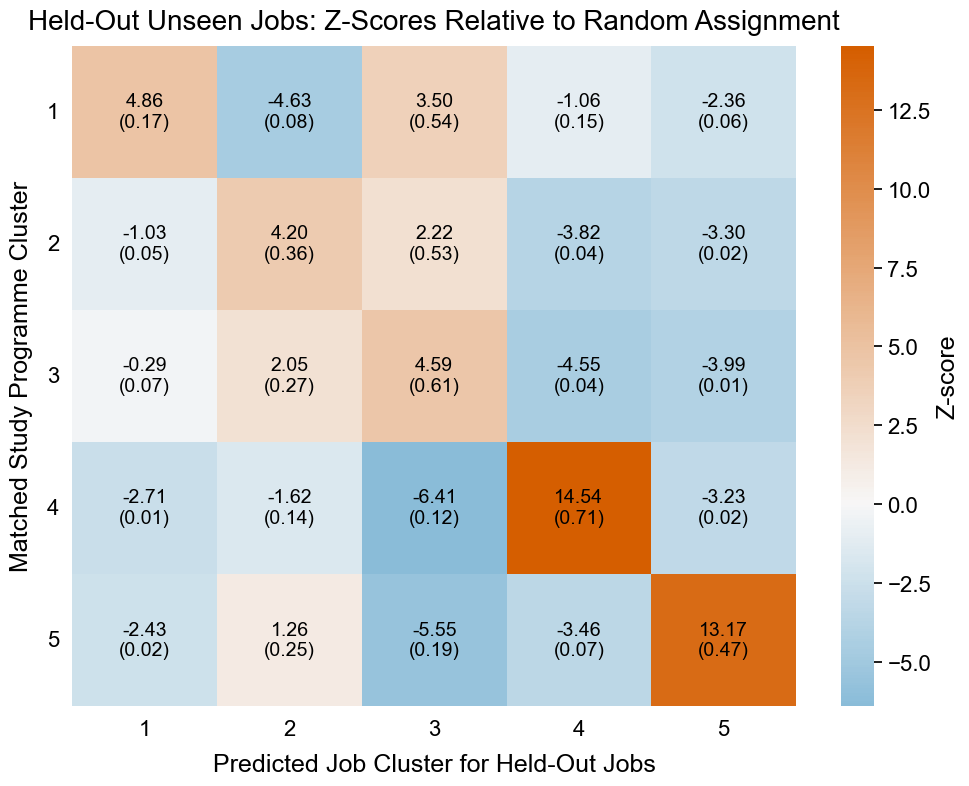

In [70]:
# Creating a copy of the held-out unseen job predictions that contain the information needed for the z-score calculation.
unseen_jobs_test_predictions_for_z_scores = unseen_jobs_test_predictions.dropna(
    subset=["matched_study_cluster", "predicted_cluster_job_unseen"]
).copy()

# Calculating the observed row-normalized confusion matrix for the held-out unseen job descriptions.
observed_unseen_job_confusion_matrix = pd.crosstab(
    unseen_jobs_test_predictions_for_z_scores["matched_study_cluster"],
    unseen_jobs_test_predictions_for_z_scores["predicted_cluster_job_unseen"],
    normalize="index"
)

# Calculating the overall predicted cluster proportions across all held-out unseen job descriptions.
predicted_cluster_proportions_unseen_jobs = (
    unseen_jobs_test_predictions_for_z_scores["predicted_cluster_job_unseen"]
    .value_counts(normalize=True)
    .sort_index()
)

# Calculating the number of held-out unseen job descriptions in each matched study-programme cluster.
row_counts_unseen_jobs = (
    unseen_jobs_test_predictions_for_z_scores["matched_study_cluster"]
    .value_counts()
    .sort_index()
)

# Creating the ordered list of cluster labels used in the observed confusion matrix.
cluster_labels_unseen_jobs = list(observed_unseen_job_confusion_matrix.columns)

# Reindexing the predicted cluster proportions so that they align exactly with the observed confusion matrix columns.
predicted_cluster_proportions_unseen_jobs = predicted_cluster_proportions_unseen_jobs.reindex(
    cluster_labels_unseen_jobs,
    fill_value=0
)

# Creating an empty DataFrame that will store the z-scores for every cell in the confusion matrix.
unseen_job_confusion_matrix_z_scores = pd.DataFrame(
    index=observed_unseen_job_confusion_matrix.index,
    columns=observed_unseen_job_confusion_matrix.columns,
    dtype=float
)

# Looping over every matched study-programme cluster row in the observed confusion matrix.
for matched_cluster in observed_unseen_job_confusion_matrix.index:

    # Retrieving the number of held-out unseen job descriptions in the current row.
    current_row_count = row_counts_unseen_jobs.loc[matched_cluster]

    # Looping over every predicted job cluster column in the observed confusion matrix.
    for predicted_cluster in observed_unseen_job_confusion_matrix.columns:

        # Retrieving the observed row-normalized proportion for the current cell.
        observed_proportion = observed_unseen_job_confusion_matrix.loc[matched_cluster, predicted_cluster]

        # Retrieving the expected probability for the current predicted cluster under random assignment.
        expected_proportion = predicted_cluster_proportions_unseen_jobs.loc[predicted_cluster]

        # Calculating the standard error for the expected proportion in the current row.
        standard_error = np.sqrt(
            (expected_proportion * (1 - expected_proportion)) / current_row_count
        )

        # Calculating the z-score only when the standard error is larger than zero.
        if standard_error > 0:
            unseen_job_confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster] = (
                (observed_proportion - expected_proportion) / standard_error
            )

        # Filling the z-score with zero when the standard error equals zero.
        else:
            unseen_job_confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster] = 0

# Creating an empty DataFrame that will store the annotation text for every cell in the heatmap.
unseen_job_confusion_matrix_annotations = pd.DataFrame(
    index=observed_unseen_job_confusion_matrix.index,
    columns=observed_unseen_job_confusion_matrix.columns,
    dtype=object
)

# Looping over every matched study-programme cluster row to create the combined annotation text.
for matched_cluster in observed_unseen_job_confusion_matrix.index:

    # Looping over every predicted job cluster column to create the combined annotation text.
    for predicted_cluster in observed_unseen_job_confusion_matrix.columns:

        # Retrieving the z-score for the current cell.
        current_z_score = unseen_job_confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster]

        # Retrieving the original observed row-normalized proportion for the current cell.
        current_observed_rate = observed_unseen_job_confusion_matrix.loc[matched_cluster, predicted_cluster]

        # Storing the annotation text with the z-score first and the original rate between brackets underneath.
        unseen_job_confusion_matrix_annotations.loc[matched_cluster, predicted_cluster] = (
            f"{current_z_score:.2f}\n({current_observed_rate:.2f})"
        )


# Setting up the figure for the z-score heatmap of the held-out unseen job descriptions.
fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")

# Setting the axis background to white.
ax.set_facecolor("white")

# Creating a heatmap of the z-scores for the held-out unseen job descriptions, while displaying the original row-normalized rates between brackets.
heatmap = sns.heatmap(
    unseen_job_confusion_matrix_z_scores,
    annot=unseen_job_confusion_matrix_annotations,
    fmt="",
    cmap=COLORBLIND_DIVERGING_CMAP,
    center=0,
    linewidths=0,
    annot_kws={"fontsize": 14},
    cbar_kws={"label": "Z-score"},
    ax=ax
)

# Retrieving the colorbar object so its label and ticks can be styled.
colorbar = heatmap.collections[0].colorbar

# Increasing the colorbar label size.
colorbar.set_label("Z-score", fontsize=18)

# Increasing the colorbar tick-label size.
colorbar.ax.tick_params(labelsize=16)

# Setting the title of the heatmap.
ax.set_title(
    "Held-Out Unseen Jobs: Z-Scores Relative to Random Assignment",
    fontsize=20,
    pad=12
)

# Setting the x-axis label.
ax.set_xlabel(
    "Predicted Job Cluster for Held-Out Jobs",
    fontsize=18,
    labelpad=10
)

# Setting the y-axis label.
ax.set_ylabel(
    "Matched Study Programme Cluster",
    fontsize=18,
    labelpad=10
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Keeping the y-axis tick labels horizontal.
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

# Keeping the x-axis tick labels horizontal.
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Saving the plot to the existing output directory.
full_path = "Analyzing_Predicted_Job_Classifications/confusion_matrix_unseen_held_out_jobs_z_scores_with_rates.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(
    full_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to avoid memory buildup.
plt.close(fig)

<br></br>

In [71]:
# This function repeats the held-out unseen job evaluation across multiple random splits in order to assess stability.
def repeated_unseen_job_evaluation(jobs_dataframe, text_column, matched_cluster_column, lda_model_study_programmes, kmeans_study_programmes, dictionary_study_programmes, minimum_number_of_tokens, test_size=0.20, number_of_repetitions=25, starting_random_state=42):

    # Creating a list that will store the summary outcome of every repetition.
    repeated_unseen_job_results = []

    # Looping over all repetitions of the held-out unseen job evaluation.
    for repetition in range(number_of_repetitions):

        # Defining the random state of the current repetition.
        current_random_state = starting_random_state + repetition

        # Running the held-out unseen job evaluation for the current repetition.
        (unseen_jobs_train_repeated, unseen_jobs_test_repeated, unseen_jobs_test_predictions_repeated, unseen_job_evaluation_summary_repeated, unseen_job_confusion_matrix_repeated, unseen_job_match_rate_per_cluster_repeated) = evaluate_unseen_job_assignments(
            jobs_dataframe=jobs_dataframe,
            text_column=text_column,
            matched_cluster_column=matched_cluster_column,
            lda_model_study_programmes=lda_model_study_programmes,
            kmeans_study_programmes=kmeans_study_programmes,
            dictionary_study_programmes=dictionary_study_programmes,
            minimum_number_of_tokens=minimum_number_of_tokens,
            test_size=test_size,
            random_state=current_random_state
        )

        # Extracting the summary values of the current repetition into a dictionary.
        summary_dictionary_current_repetition = dict(
            zip(unseen_job_evaluation_summary_repeated["metric"], unseen_job_evaluation_summary_repeated["value"])
        )

        # Adding the metadata of the current repetition.
        summary_dictionary_current_repetition["repetition"] = repetition + 1
        summary_dictionary_current_repetition["random_state"] = current_random_state

        # Appending the current repetition to the result list.
        repeated_unseen_job_results.append(summary_dictionary_current_repetition)

    # Converting the repeated evaluation results into a DataFrame.
    repeated_unseen_job_results_df = pd.DataFrame(repeated_unseen_job_results)

    return repeated_unseen_job_results_df


# Repeating the held-out unseen job evaluation to assess stability across multiple random splits.
repeated_unseen_job_results_df = repeated_unseen_job_evaluation(
    jobs_dataframe=hbo_monitor_with_metadata,
    text_column="full_job_description",
    matched_cluster_column="matched_study_cluster",
    lda_model_study_programmes=lda_model_study_programmes,
    kmeans_study_programmes=kmeans_study_programmes,
    dictionary_study_programmes=dictionary_study_programmes,
    minimum_number_of_tokens=min_length,
    test_size=0.20,
    number_of_repetitions=25,
    starting_random_state=42
)

# Displaying the repeated unseen job evaluation results.
print(repeated_unseen_job_results_df)

    total_jobs_with_text_and_study_cluster  \
0                                   4810.0   
1                                   4810.0   
2                                   4810.0   
3                                   4810.0   
4                                   4810.0   
5                                   4810.0   
6                                   4810.0   
7                                   4810.0   
8                                   4810.0   
9                                   4810.0   
10                                  4810.0   
11                                  4810.0   
12                                  4810.0   
13                                  4810.0   
14                                  4810.0   
15                                  4810.0   
16                                  4810.0   
17                                  4810.0   
18                                  4810.0   
19                                  4810.0   
20                                

<br></br>

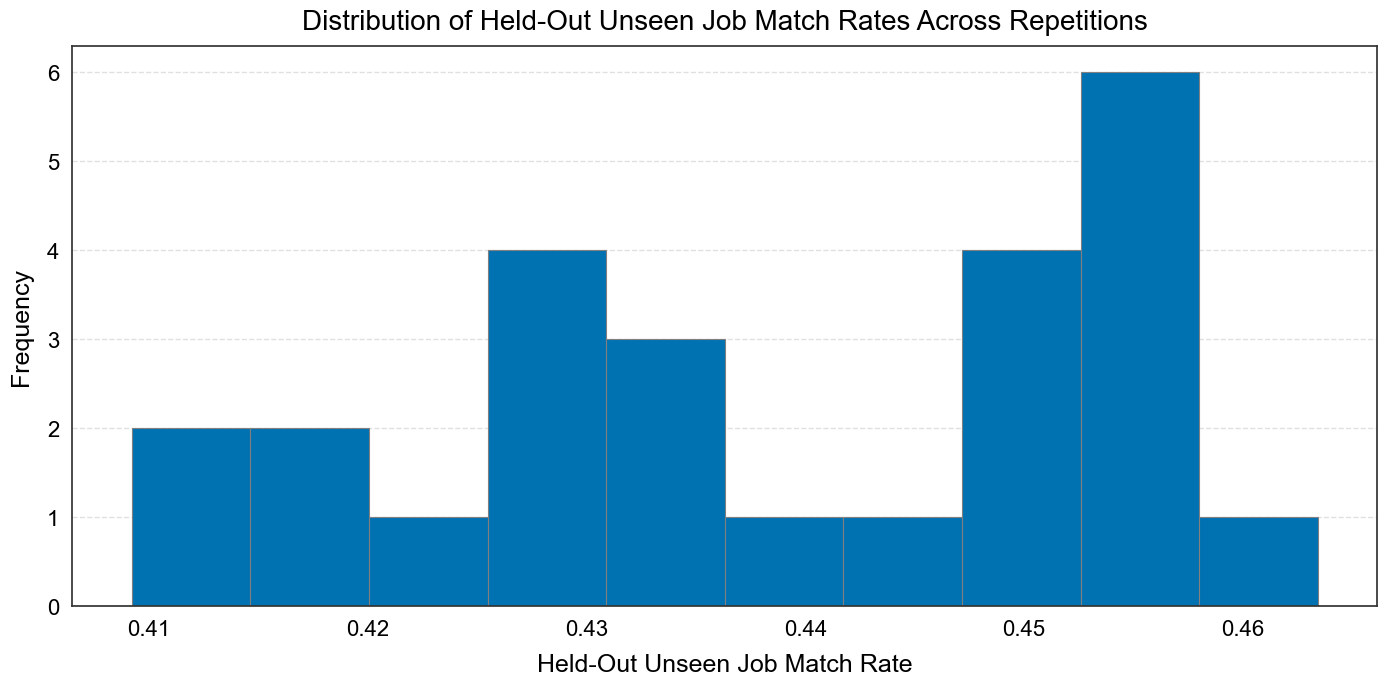

                                         metric     value
0           mean_match_rate_within_held_out_set  0.439187
1            std_match_rate_within_held_out_set  0.016163
2        minimum_match_rate_within_held_out_set  0.409214
3        maximum_match_rate_within_held_out_set  0.463415
4  mean_prediction_coverage_within_held_out_set  1.000000


In [72]:
# Creating a new figure to visualize the distribution of the held-out unseen job match rates.
fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")

# Setting the axis background to white.
ax.set_facecolor("white")

# Creating the histogram of the held-out unseen job match rates across repetitions.
ax.hist(
    repeated_unseen_job_results_df["match_rate_within_held_out_set"],
    bins=10,
    edgecolor="gray",
    linewidth=0.8,
    color=COLORBLIND_CATEGORICAL_PALETTE[0]
)

# Setting the title of the plot.
ax.set_title(
    "Distribution of Held-Out Unseen Job Match Rates Across Repetitions",
    fontsize=20,
    pad=12
)

# Setting the x-axis label.
ax.set_xlabel(
    "Held-Out Unseen Job Match Rate",
    fontsize=18,
    labelpad=10
)

# Setting the y-axis label.
ax.set_ylabel(
    "Frequency",
    fontsize=18,
    labelpad=10
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Adding a horizontal grid for readability.
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

# Ensuring that the grid is drawn behind the histogram bars.
ax.set_axisbelow(True)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Saving the plot to the existing output directory.
full_path = "Analyzing_Predicted_Job_Classifications/distribution_match_rates_unseen_held_out_jobs.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(
    full_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to avoid memory buildup.
plt.close(fig)

# Summarizing the repeated held-out unseen job evaluation results.
repeated_unseen_job_results_summary = pd.DataFrame({
    "metric": [
        "mean_match_rate_within_held_out_set",
        "std_match_rate_within_held_out_set",
        "minimum_match_rate_within_held_out_set",
        "maximum_match_rate_within_held_out_set",
        "mean_prediction_coverage_within_held_out_set"
    ],
    "value": [
        repeated_unseen_job_results_df["match_rate_within_held_out_set"].mean(),
        repeated_unseen_job_results_df["match_rate_within_held_out_set"].std(),
        repeated_unseen_job_results_df["match_rate_within_held_out_set"].min(),
        repeated_unseen_job_results_df["match_rate_within_held_out_set"].max(),
        repeated_unseen_job_results_df["prediction_coverage_within_held_out_set"].mean()
    ]
})

# Displaying the summary of the repeated held-out unseen job evaluation results.
print(repeated_unseen_job_results_summary)

<br></br><br></br>

### 
### Analyzing the Predicted Clusters

In this section, the clusters predicted for the job descriptions present in the 'hbo_monitor_with_metadata' DataFrame are compared with the original clusters corresponding to the study programmes present for the corresponding entry.
<br></br>

#### Match Rate by Hogeschool and Study Programme Type

In this section, a bar plot is created showing the match rate between the study programme and job description cluster per hogeschool and study programme type.

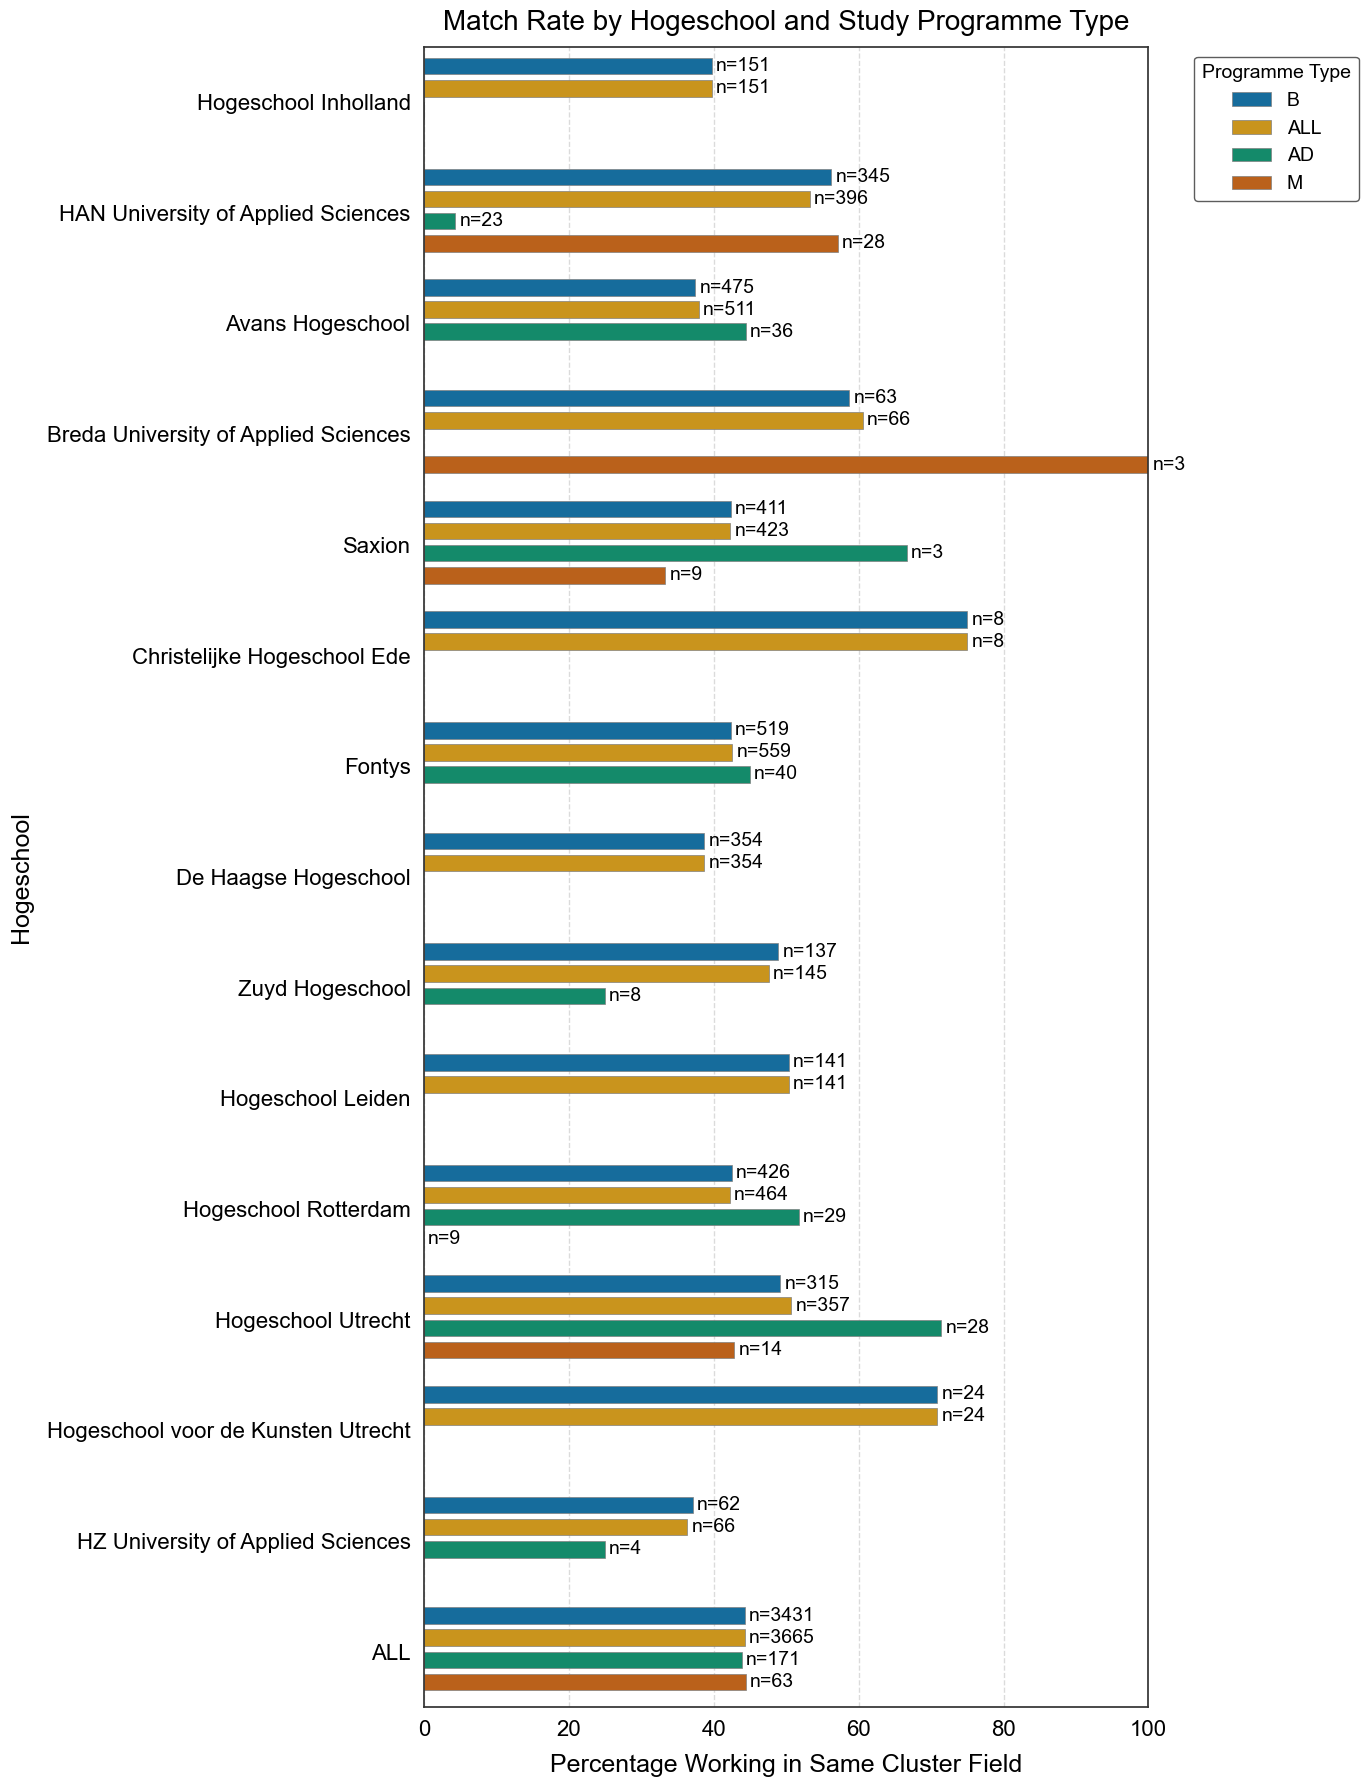

In [65]:
# Removing the set of entries which does not have all 3 columns 'hogeschool', 'study_programme_type', and 'same_cluster' populated.
hbo_monitor_with_metadata_non_empty = hbo_monitor_with_metadata.dropna(subset=["hogeschool", "study_programme_type", "same_cluster"])

# Grouping the 'hbo_monitor_with_metadata_non_empty' DataFrame by both the 'hogeschool' and the 'study_programme_type' while creating a new column containing the mean of the 'same_cluster' and a new column containing the number of entries per group.
hogeschool_type_summary = (hbo_monitor_with_metadata_non_empty.groupby(["hogeschool", "study_programme_type"]).agg(percentage_same_cluster=("same_cluster", "mean"),
                                                                                                                   num_entries=("same_cluster", "count")
                                                                                                                  ).reset_index()
                          )

# Converting the calculated match rate from a proportion to a percentage.
hogeschool_type_summary["percentage_same_cluster"] *= 100

# Grouping the 'hbo_monitor_with_metadata_non_empty' DataFrame by only the 'hogeschool' while creating a new column containing the mean of the 'same_cluster' and a new column containing the number of entries per group.
hogeschool_overall = (hbo_monitor_with_metadata_non_empty.groupby("hogeschool").agg(percentage_same_cluster=("same_cluster", "mean"),
                                                                                    num_entries=("same_cluster", "count")
                                                                                   ).reset_index()
                     )

# Converting the calculated match rate from a proportion to a percentage.
hogeschool_overall["percentage_same_cluster"] *= 100

# Adding a column that indicates that this is an aggregate over all programme types.
hogeschool_overall["study_programme_type"] = "ALL"

# Grouping the 'hbo_monitor_with_metadata_non_empty' DataFrame by only the 'study_programme_type' while creating a new column containing the mean of the 'same_cluster' and a new column containing the number of entries per group.
type_overall = (hbo_monitor_with_metadata_non_empty.groupby("study_programme_type").agg(percentage_same_cluster=("same_cluster", "mean"),
                                                                                        num_entries=("same_cluster", "count")
                                                                                       ).reset_index()
               )

# Converting the calculated match rate from a proportion to a percentage.
type_overall["percentage_same_cluster"] *= 100

# Adding a column that indicates that this is an aggregate over all programme types.
type_overall["hogeschool"] = "ALL"

# Computing a DataFrame which contains the total number of entries and the total overall match rate of the 'hbo_monitor_with_metadata_non_empty' DataFrame.
all_total = pd.DataFrame([{"hogeschool": "ALL",
                           "study_programme_type": "ALL",
                           "percentage_same_cluster": hbo_monitor_with_metadata_non_empty["same_cluster"].mean() * 100,
                           "num_entries": hbo_monitor_with_metadata_non_empty["same_cluster"].count()
                          }])

# Combining all summary DataFrames into a single DataFrame which will be used for plotting.
observed_summary = pd.concat([hogeschool_type_summary, hogeschool_overall, type_overall, all_total],
                             ignore_index=True
                            )

# Retrieving all the unique values of hogescholen and study programme types.
all_hogescholen = hbo_monitor_with_metadata_non_empty["hogeschool"].unique().tolist() + ["ALL"]
all_types = hbo_monitor_with_metadata_non_empty["study_programme_type"].unique().tolist() + ["ALL"]

# Creating a complete grid (cartesian product) of all possible combinations of hogescholen and study programme types.
full_index = pd.MultiIndex.from_product([all_hogescholen, all_types], names=["hogeschool", "study_programme_type"])

# Converting the multi-index into a DataFrame with 'hogeschool' and 'study_programme_type' columns.
full_summary = pd.DataFrame(index=full_index).reset_index()

# Merging the 'full_summary' DataFrame with the 'observed_summary' DataFrame.
combined_summary = full_summary.merge(observed_summary,
                                      how="left",
                                      on=["hogeschool", "study_programme_type"]
                                     )

# Filling missing count values with 0 and ensure they are integers.
combined_summary["num_entries"] = combined_summary["num_entries"].fillna(0).astype(int)
combined_summary = combined_summary[combined_summary["num_entries"] > 0].copy()

# Filling missing percentage values with 0 (meaning: no observed matches).
combined_summary["percentage_same_cluster"] = combined_summary["percentage_same_cluster"].fillna(0)

# Determining how many distinct hogescholen will be shown on the y-axis.
n_groups = combined_summary["hogeschool"].nunique()

# Creating a new figure with dynamic height depending on the number of hogescholen.
fig, ax = plt.subplots(
    figsize=(14, max(7, n_groups * 1.2)),
    facecolor="white"
)

# Setting the axis background to white.
ax.set_facecolor("white")

# Creating a horizontal barplot showing the match percentages per hogeschool, split by programme type.
barplot = sns.barplot(
    data=combined_summary,
    y="hogeschool",
    x="percentage_same_cluster",
    hue="study_programme_type",
    dodge=0.5,
    linewidth=0.5,
    edgecolor="gray",
    ci=None,
    palette=get_colorblind_palette(combined_summary["study_programme_type"].nunique()),
    ax=ax
)

# Adjusting the bar thickness.
for bar in barplot.patches:
    bar.set_height(0.15)

# Adding text labels to each bar indicating the number of entries.
for container, hue_val in zip(
    barplot.containers,
    barplot.get_legend_handles_labels()[1]
):

    # Filtering the summary for the current programme type.
    sub_df = combined_summary[
        combined_summary["study_programme_type"] == hue_val
    ].reset_index(drop=True)

    # Preparing the labels for each bar.
    labels = [
        f"n={int(n)}"
        for n in sub_df["num_entries"]
    ]

    # Adding the labels to the corresponding bars.
    barplot.bar_label(
        container,
        labels=labels,
        label_type="edge",
        padding=3,
        fontsize=14
    )

# Setting the title of the plot.
ax.set_title(
    "Match Rate by Hogeschool and Study Programme Type",
    fontsize=20,
    pad=12
)

# Setting the x-axis label.
ax.set_xlabel(
    "Percentage Working in Same Cluster Field",
    fontsize=18,
    labelpad=10
)

# Setting the y-axis label.
ax.set_ylabel(
    "Hogeschool",
    fontsize=18,
    labelpad=10
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Setting the x-axis limits.
ax.set_xlim(0, 100)

# Adding grid lines for readability.
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

# Ensuring that the grid is drawn behind the bars.
ax.set_axisbelow(True)

# Adding the legend with manuscript-style font sizes.
ax.legend(
    title="Programme Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Saving the plot.
full_path = "Analyzing_Predicted_Job_Classifications/match_rate_by_hogeschool_and_study_type.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(
    full_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to avoid memory buildup.
plt.close(fig)

<br></br>

#### Confusion Matrix: Study Programme & Job Description Cluster

In this section, a confusion matrix is computed to compare how well study programme clusters align with predicted job clusters. This is represented by a matrix where each row sums to 1, allowing interpretation of the data as proportions.

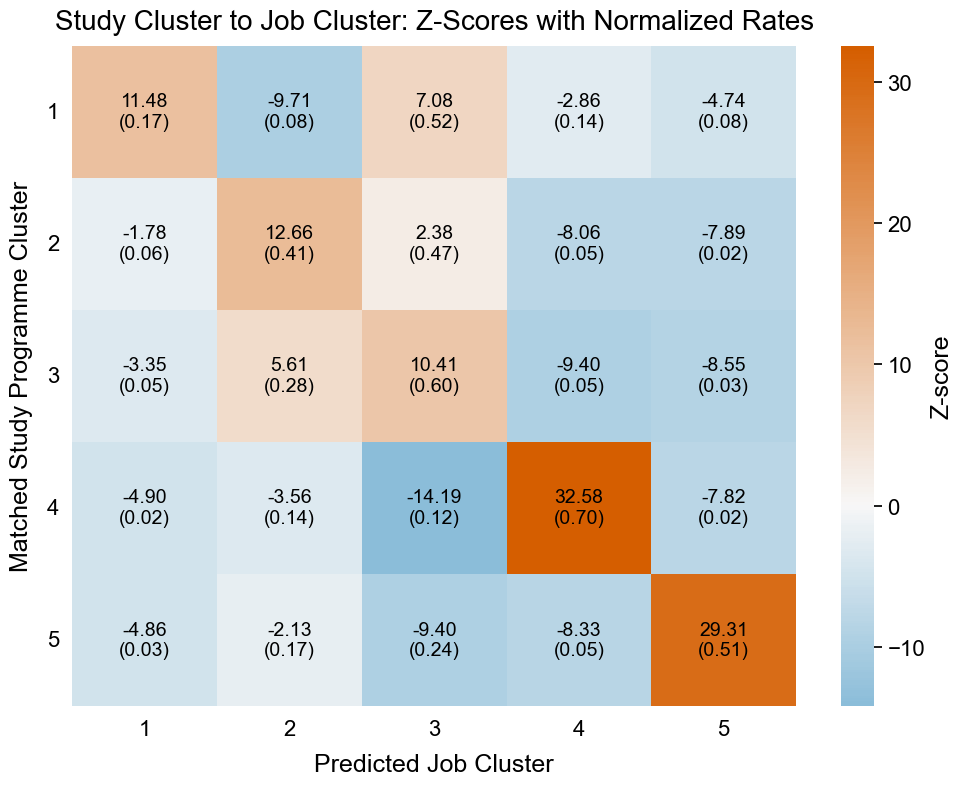

In [64]:
# Removing the set of entries which does not have the columns 'matched_study_cluster' and 'predicted_cluster_job' populated.
confusion_data = hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "predicted_cluster_job"]).copy()

# Creating a confusion matrix using a cross-tabulation where the rows represent the actual matched study clusters while the columns represent the predicted job clusters.
conf_matrix = pd.crosstab(confusion_data["matched_study_cluster"],
                          confusion_data["predicted_cluster_job"],
                          normalize="index"
                         )

# Calculating the overall predicted job-cluster proportions. These are used as the expected probabilities under random assignment.
predicted_cluster_proportions = (
    confusion_data["predicted_cluster_job"]
    .value_counts(normalize=True)
    .sort_index()
)

# Calculating the number of observations in each matched study-programme cluster.
row_counts_confusion_matrix = (
    confusion_data["matched_study_cluster"]
    .value_counts()
    .sort_index()
)

# Reindexing the expected proportions so that they align exactly with the confusion-matrix columns.
predicted_cluster_proportions = predicted_cluster_proportions.reindex(
    conf_matrix.columns,
    fill_value=0
)

# Creating a z-score matrix with the same format used for the held-out unseen-job confusion matrix.
confusion_matrix_z_scores = pd.DataFrame(
    index=conf_matrix.index,
    columns=conf_matrix.columns,
    dtype=float
)

for matched_cluster in conf_matrix.index:
    current_row_count = row_counts_confusion_matrix.loc[matched_cluster]

    for predicted_cluster in conf_matrix.columns:
        observed_proportion = conf_matrix.loc[matched_cluster, predicted_cluster]
        expected_proportion = predicted_cluster_proportions.loc[predicted_cluster]
        standard_error = np.sqrt(
            (expected_proportion * (1 - expected_proportion)) / current_row_count
        )

        if standard_error > 0:
            confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster] = (
                (observed_proportion - expected_proportion) / standard_error
            )
        else:
            confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster] = 0

# Creating annotations with the z-score first and the original row-normalized rate between brackets underneath.
confusion_matrix_annotations = pd.DataFrame(
    index=conf_matrix.index,
    columns=conf_matrix.columns,
    dtype=object
)

for matched_cluster in conf_matrix.index:
    for predicted_cluster in conf_matrix.columns:
        current_z_score = confusion_matrix_z_scores.loc[matched_cluster, predicted_cluster]
        current_observed_rate = conf_matrix.loc[matched_cluster, predicted_cluster]
        confusion_matrix_annotations.loc[matched_cluster, predicted_cluster] = (
            f"{current_z_score:.2f}\n({current_observed_rate:.2f})"
        )

# Setting up the figure and axis for the z-score heatmap.
fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")

# Setting the axis background to white.
ax.set_facecolor("white")

# Creating a heatmap where the colors show z-scores and the annotations show z-scores with row-normalized rates in brackets.
heatmap = sns.heatmap(
    confusion_matrix_z_scores,
    annot=confusion_matrix_annotations,
    fmt="",
    cmap=COLORBLIND_DIVERGING_CMAP,
    center=0,
    linewidths=0,
    annot_kws={"fontsize": 14},
    cbar_kws={"label": "Z-score"},
    ax=ax
)

# Retrieving the colorbar object so its label and ticks can be styled.
colorbar = heatmap.collections[0].colorbar

# Increasing the colorbar label size.
colorbar.set_label("Z-score", fontsize=18)

# Increasing the colorbar tick-label size.
colorbar.ax.tick_params(labelsize=16)

# Setting the title of the plot.
ax.set_title(
    "Study Cluster to Job Cluster: Z-Scores with Normalized Rates",
    fontsize=20,
    pad=12
)

# Setting the x-axis label.
ax.set_xlabel(
    "Predicted Job Cluster",
    fontsize=18,
    labelpad=10
)

# Setting the y-axis label.
ax.set_ylabel(
    "Matched Study Programme Cluster",
    fontsize=18,
    labelpad=10
)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)

# Keeping the x-axis tick labels horizontal.
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

# Keeping the y-axis tick labels horizontal.
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Saving the plot.
full_path = "Analyzing_Predicted_Job_Classifications/confusion_matrix_study_and_job_clusters.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(
    full_path,
    bbox_inches="tight",
    dpi=300,
    facecolor="white"
)

# Showing the figure.
plt.show()

# Closing the figure to avoid memory buildup.
plt.close(fig)

<br></br>

#### Job Description Cluster Entropy by Study Programme Cluster, Hogeschool & Study Programme Type

In this section, the entropy of job cluster distributions is analyzed to measure how diverse the job outcomes are for students from different study programme clusters, hogescholen, and study types. Entropy serves as an indicator of dispersion: a high entropy value suggests that graduates from a given group end up in a wide range of job clusters, while a low entropy indicates that they are concentrated in a narrow set. After filtering out incomplete records, entropy is computed per study cluster, per cluster-hogeschool combination, and per cluster-programme type combination.

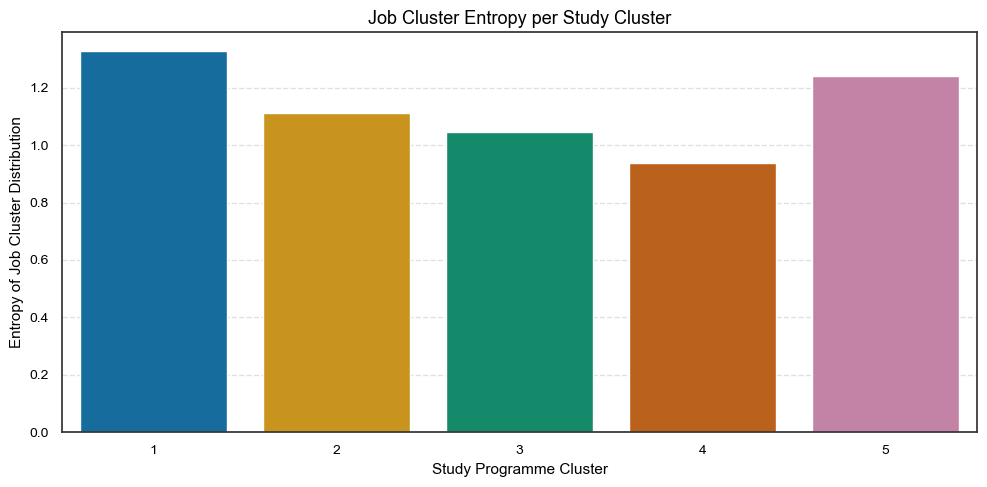

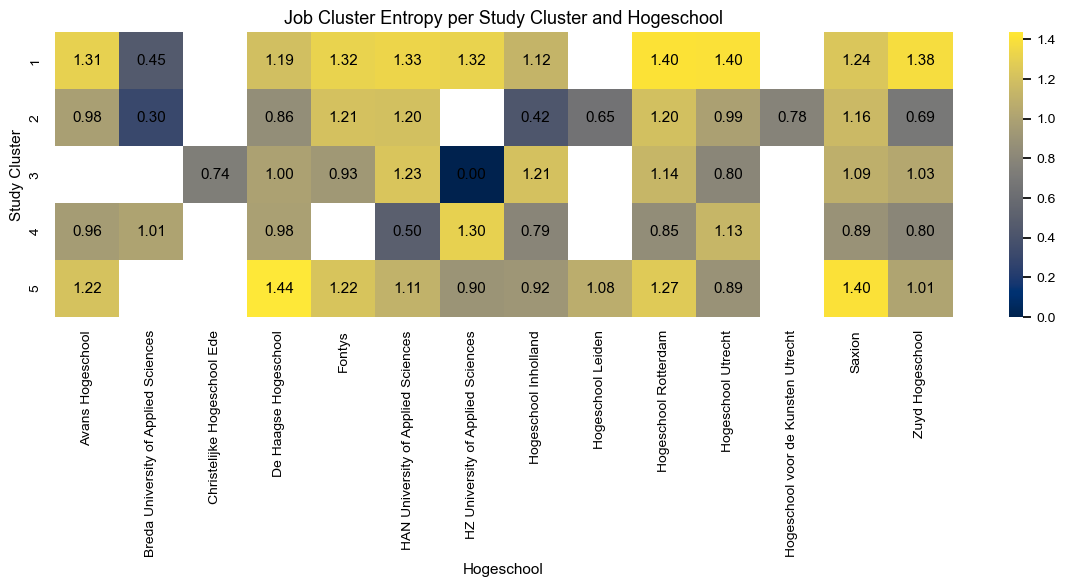

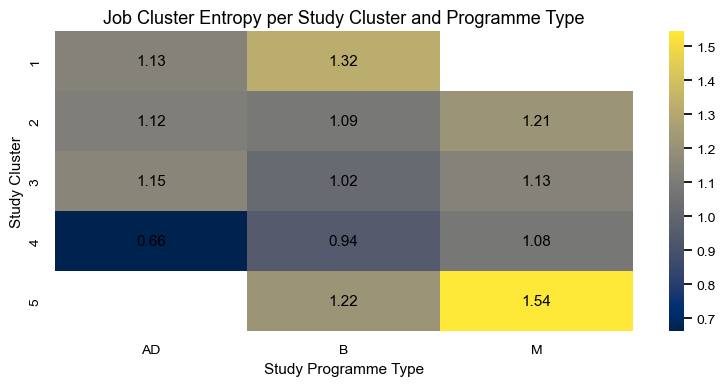

In [55]:
# Removing the set of entries with any missing values in the key columns needed for entropy calculation.
hbo_monitor_with_metadata_entropy = hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "predicted_cluster_job", "hogeschool", "study_programme_type"])

# Calculating the entropy of job cluster distribution for each study cluster.
entropy_per_study_cluster = (hbo_monitor_with_metadata_entropy.groupby("matched_study_cluster")["predicted_cluster_job"]
                                                              .value_counts(normalize=True)
                                                              .groupby(level=0)
                                                              .apply(entropy)
                                                              .reset_index(name="job_cluster_entropy")
                            )

# Calculating the entropy of job cluster distribution for each study cluster and hogeschool combination.
entropy_per_cluster_school = (hbo_monitor_with_metadata_entropy.groupby(["matched_study_cluster", "hogeschool"])["predicted_cluster_job"]
                                                               .value_counts(normalize=True)
                                                               .groupby(level=[0, 1])
                                                               .apply(entropy)
                                                               .reset_index(name="job_cluster_entropy")
                             )

# Calculating the entropy of job cluster distribution for each study cluster and study programme type combination.
entropy_per_cluster_type = (hbo_monitor_with_metadata_entropy.groupby(["matched_study_cluster", "study_programme_type"])["predicted_cluster_job"]
                                                             .value_counts(normalize=True)
                                                             .groupby(level=[0, 1])
                                                             .apply(entropy)
                                                             .reset_index(name="job_cluster_entropy")
                           )

# Creating a bar plot of the entropy per study cluster.
plt.figure(figsize=(10, 5))
sns.barplot(data=entropy_per_study_cluster, x="matched_study_cluster", y="job_cluster_entropy", ci=None, palette=get_colorblind_palette(len(entropy_per_study_cluster["matched_study_cluster"].unique())))
plt.title("Job Cluster Entropy per Study Cluster")  
plt.xlabel("Study Programme Cluster")              
plt.ylabel("Entropy of Job Cluster Distribution")   
plt.grid(axis="y", linestyle="--", alpha=0.6)      
plt.tight_layout()

# Saving the plot.
full_path = f"Analyzing_Predicted_Job_Classifications/job_cluster_entropy_per_study_cluster.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()                                         



# Pivoting the 'entropy_per_cluster_school' DataFrame such that the rows are the study clusters and the columns are the hogescholen.
pivot_school = entropy_per_cluster_school.pivot(index="matched_study_cluster", 
                                                columns="hogeschool", 
                                                values="job_cluster_entropy"
                                               )

# Creating a bar plot of the entropy per study cluster and hogeschool.
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_school, annot=True, fmt=".2f", cmap=COLORBLIND_SEQUENTIAL_CMAP)
plt.title("Job Cluster Entropy per Study Cluster and Hogeschool")  
plt.xlabel("Hogeschool")                                        
plt.ylabel("Study Cluster")                               
plt.tight_layout()

# Saving the plot.
full_path = f"Analyzing_Predicted_Job_Classifications/job_cluster_entropy_per_study_cluster_and_hogeschool.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()                                                 



# Pivoting the 'entropy_per_cluster_school' DataFrame such that the rows are the study clusters and the columns are the study programme types.
pivot_type = entropy_per_cluster_type.pivot(index="matched_study_cluster", 
                                            columns="study_programme_type", 
                                            values="job_cluster_entropy"
                                           )

# Creating a bar plot of the entropy per study cluster and study programme type.
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_type, annot=True, fmt=".2f", cmap=COLORBLIND_SEQUENTIAL_CMAP)
plt.title("Job Cluster Entropy per Study Cluster and Programme Type")
plt.xlabel("Study Programme Type")                                  
plt.ylabel("Study Cluster")                                     
plt.tight_layout()

# Saving the plot.
full_path = f"Analyzing_Predicted_Job_Classifications/job_cluster_entropy_per_study_cluster_and_type.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()                                                       


<br></br>

#### Top Job Description Cluster per Study Cluster

In this section, the most common job cluster is identified for each study programme cluster.

In [56]:
# Removing the set of entries which does not have the columns 'matched_study_cluster' and 'predicted_cluster_job' populated and grouping the data by the matched study cluster.
top_jobs = (hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "predicted_cluster_job"])
                                     .groupby("matched_study_cluster")["predicted_cluster_job"]
                                     .agg(lambda x: x.value_counts().idxmax())
                                     .reset_index(name="top_job_cluster")
           )

top_jobs

,matched_study_cluster,top_job_cluster
0,1,3
1,2,3
2,3,3
3,4,4
4,5,5


<br></br>

#### Study Programme Cluster Entropy by Job Description Cluster

In this section, the entropy of study cluster distributions is measured for each job cluster. It assesses how consistent or diverse the educational backgrounds are among people ending up in the same job cluster. A high entropy indicates that the job cluster draws graduates from many different study clusters, suggesting cross-disciplinary convergence. A low entropy suggests specialization, where most individuals in that job cluster come from the same study background. The results are visualized with a bar plot to compare consistency across job clusters.

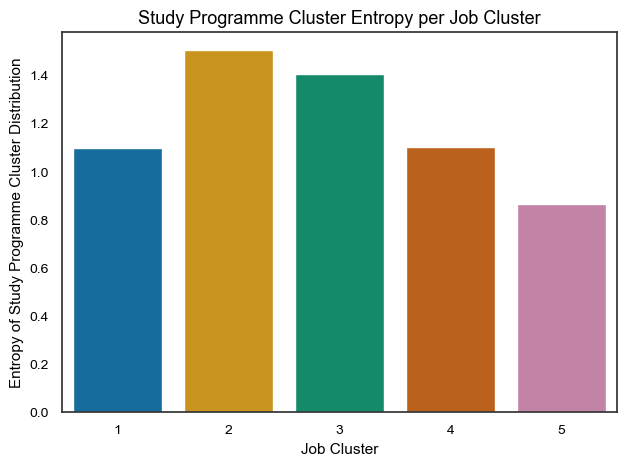

In [57]:
# Calculating the entropy of study cluster distribution for each job cluster.
study_entropy_per_job_cluster = (hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "predicted_cluster_job"])
                                                          .groupby("predicted_cluster_job")["matched_study_cluster"]
                                                          .value_counts(normalize=True)
                                                          .groupby(level=0)
                                                          .apply(lambda x: entropy(x))
                                                          .reset_index(name="study_cluster_entropy")
                                )

# Creating a bar plot of the entropy per job cluster.
sns.barplot(data=study_entropy_per_job_cluster, x="predicted_cluster_job", y="study_cluster_entropy", ci=None, palette=get_colorblind_palette(len(study_entropy_per_job_cluster["predicted_cluster_job"].unique())))
plt.title("Study Programme Cluster Entropy per Job Cluster")
plt.xlabel("Job Cluster")
plt.ylabel("Entropy of Study Programme Cluster Distribution")
plt.tight_layout()

# Saving the plot.
full_path = f"Analyzing_Predicted_Job_Classifications/study_cluster_entropy_per_job_cluster.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()

<br></br>

#### Mismatch Rate per Study Programme Cluster

In this section, the mismatch rate per study programme cluster is calculated by flagging whether a study and job belong to different clusters.

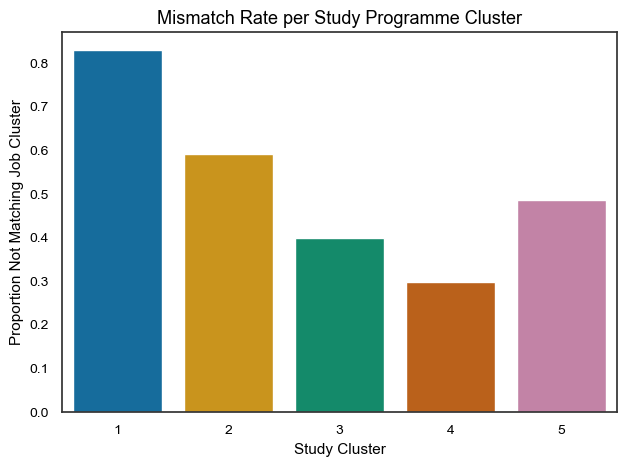

In [58]:
# Adding a mismatch column to the 'hbo_monitor_with_metadata' DataFrame.
hbo_monitor_with_metadata["mismatch"] = hbo_monitor_with_metadata["same_cluster"] == 0

# Grouping the mismatch rate by study programme cluster.
mismatch_by_cluster = (hbo_monitor_with_metadata.dropna(subset=["matched_study_cluster", "same_cluster"])
                                                .groupby("matched_study_cluster")["mismatch"]
                                                .mean()
                                                .reset_index(name="mismatch_rate")
                      )

# Creating a bar plot of the mismatch rate per study programme cluster.
sns.barplot(data=mismatch_by_cluster, x="matched_study_cluster", y="mismatch_rate", ci=None, palette=get_colorblind_palette(len(mismatch_by_cluster["matched_study_cluster"].unique())))
plt.title("Mismatch Rate per Study Programme Cluster")
plt.xlabel("Study Cluster")
plt.ylabel("Proportion Not Matching Job Cluster")
plt.tight_layout()

# Saving the plot.
full_path = f"Analyzing_Predicted_Job_Classifications/mismatch_rate_per_study_cluster.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

plt.show()
plt.close()

<br></br>

#### Mismatch Rate per Job Description Cluster

In this section, the mismatch rate per job description cluster is calculated by flagging whether a study and job belong to different clusters.


Mismatch rate per predicted job cluster:

Job cluster 1: mismatch_rate = 0.349, n_jobs = 284
Job cluster 2: mismatch_rate = 0.677, n_jobs = 725
Job cluster 3: mismatch_rate = 0.696, n_jobs = 1529
Job cluster 4: mismatch_rate = 0.396, n_jobs = 642
Job cluster 5: mismatch_rate = 0.279, n_jobs = 487


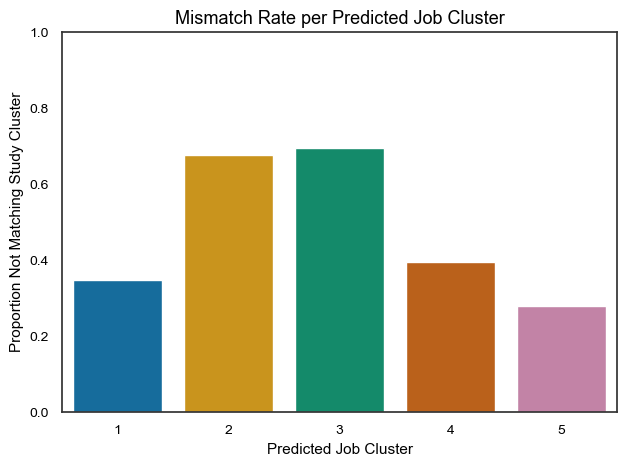

In [59]:
# Creating a new column within the 'hbo_monitor_with_metadata' DataFrame that indicates whether the predicted job cluster does not match the matched study programme cluster.
hbo_monitor_with_metadata["mismatch"] = hbo_monitor_with_metadata["same_cluster"] == 0


# Dropping rows for which either the predicted job cluster or the same-cluster indicator is missing, and grouping the remaining entries by the predicted job cluster in order to compute the average mismatch rate per job cluster.
mismatch_by_job_cluster = (
    hbo_monitor_with_metadata
        .dropna(subset=["predicted_cluster_job", "same_cluster"])
        .groupby("predicted_cluster_job")["mismatch"]
        .mean()
        .reset_index(name="mismatch_rate")
)


# Grouping the 'hbo_monitor_with_metadata' DataFrame by the predicted job cluster and counting the number of job descriptions associated with each job cluster.
job_cluster_counts = (
    hbo_monitor_with_metadata
        .dropna(subset=["predicted_cluster_job"])
        .groupby("predicted_cluster_job")
        .size()
        .reset_index(name="n_jobs")
)


# Merging the mismatch rates per predicted job cluster with the corresponding number of job descriptions in order to retain both the mismatch rate and the cluster size.
mismatch_by_job_cluster = mismatch_by_job_cluster.merge(
    job_cluster_counts,
    on="predicted_cluster_job",
    how="left"
)


# Printing the mismatch rate and the number of job descriptions for each predicted job cluster in a readable and interpretable format.
print("\nMismatch rate per predicted job cluster:\n")

for _, row in mismatch_by_job_cluster.iterrows():
    print(
        f"Job cluster {int(row['predicted_cluster_job'])}: "
        f"mismatch_rate = {row['mismatch_rate']:.3f}, "
        f"n_jobs = {int(row['n_jobs'])}"
    )


# Creating a bar plot that visualizes the mismatch rate per predicted job cluster.
sns.barplot(
    data=mismatch_by_job_cluster,
    x="predicted_cluster_job",
    y="mismatch_rate",
    ci=None,
    palette=get_colorblind_palette(len(mismatch_by_job_cluster["predicted_cluster_job"].unique()))
)


# Adding a title and axis labels to the bar plot in order to clarify the interpretation of the mismatch rates per predicted job cluster.
plt.title("Mismatch Rate per Predicted Job Cluster")
plt.xlabel("Predicted Job Cluster")
plt.ylabel("Proportion Not Matching Study Cluster")
plt.ylim(0, 1)


# Adjusting the layout of the plot to ensure that labels and titles are displayed properly.
plt.tight_layout()


# Defining the full path where the mismatch rate plot will be saved and creating the corresponding directory if it does not yet exist.
full_path = "Analyzing_Predicted_Job_Classifications/mismatch_rate_per_job_cluster.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")


# Displaying the plot and closing the figure to free memory.
plt.show()
plt.close()


<br></br>

#### Match Rate per Job Description Cluster

In this section, the match rate per job description cluster is calculated by flagging whether a study and job belong to the same cluster.

,cluster_1,cluster_2,match_rate_1,match_rate_2,difference,raw_pvalue,holm_pvalue,significant_holm_0_05
0,1,2,0.651408,0.322759,0.328650,0.000000,0.000000,True
1,1,3,0.651408,0.304120,0.347288,0.000000,0.000000,True
2,1,4,0.651408,0.604361,0.047047,0.174067,0.348133,False
3,1,5,0.651408,0.720739,-0.069331,0.043669,0.131007,False
4,2,3,0.322759,0.304120,0.018638,0.371526,0.371526,False
5,2,4,0.322759,0.604361,-0.281603,0.000000,0.000000,True
6,2,5,0.322759,0.720739,-0.397981,0.000000,0.000000,True
7,3,4,0.304120,0.604361,-0.300241,0.000000,0.000000,True
8,3,5,0.304120,0.720739,-0.416619,0.000000,0.000000,True
9,4,5,0.604361,0.720739,-0.116378,0.000046,0.000186,True


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:0.000e+00
3 vs. 4: Custom statistical test, P_val:0.000e+00
4 vs. 5: Custom statistical test, P_val:1.858e-04
1 vs. 3: Custom statistical test, P_val:0.000e+00
2 vs. 4: Custom statistical test, P_val:0.000e+00
3 vs. 5: Custom statistical test, P_val:0.000e+00
2 vs. 5: Custom statistical test, P_val:0.000e+00


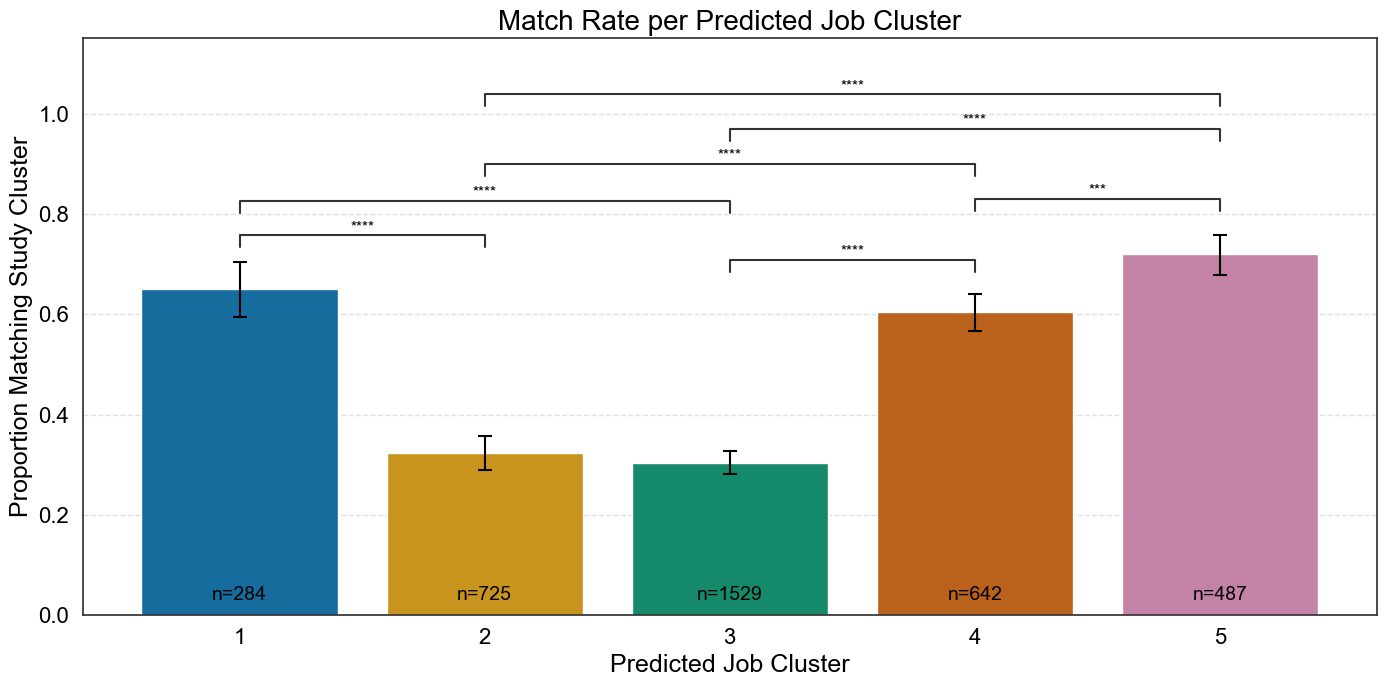

In [62]:
# Creating a new column within the 'hbo_monitor_with_metadata' DataFrame that indicates
# whether the predicted job cluster matches the matched study programme cluster.
hbo_monitor_with_metadata["match"] = hbo_monitor_with_metadata["same_cluster"] == 1


# Dropping rows for which either the predicted job cluster or the same-cluster indicator
# is missing, because both variables are required for the match-rate comparison.
match_rate_analysis_df = (
    hbo_monitor_with_metadata
        .dropna(subset=["predicted_cluster_job", "same_cluster"])
        .copy()
)


# Treating the predicted job cluster as an ordered categorical variable keeps the plot,
# pairwise tests, and annotation pairs aligned.
match_rate_analysis_df["predicted_cluster_job"] = (
    match_rate_analysis_df["predicted_cluster_job"].astype(int).astype(str)
)

# Defining the predicted job-cluster order numerically.
job_cluster_order = sorted(
    match_rate_analysis_df["predicted_cluster_job"].unique(),
    key=lambda value: int(value)
)

# Converting the predicted job cluster variable to an ordered categorical variable.
match_rate_analysis_df["predicted_cluster_job"] = pd.Categorical(
    match_rate_analysis_df["predicted_cluster_job"],
    categories=job_cluster_order,
    ordered=True
)

# Computing the match rate and sample size per predicted job cluster.
match_rate_by_job_cluster = (
    match_rate_analysis_df
        .groupby("predicted_cluster_job", observed=False)["match"]
        .agg(number_matching="sum", n_jobs="count", match_rate="mean")
        .reset_index()
)

# Sorting the match-rate summary table according to the predefined job-cluster order.
match_rate_by_job_cluster = (
    match_rate_by_job_cluster
        .sort_values("predicted_cluster_job")
        .reset_index(drop=True)
)

# Calculating Wilson 95% confidence intervals for each predicted job-cluster match rate.
match_rate_by_job_cluster[["ci_lower", "ci_upper"]] = match_rate_by_job_cluster.apply(
    lambda row: pd.Series(
        proportion_confint(
            count=row["number_matching"],
            nobs=row["n_jobs"],
            alpha=0.05,
            method="wilson"
        )
    ),
    axis=1
)

# Calculating the distance from the match rate to the lower confidence-interval bound.
match_rate_by_job_cluster["ci_lower_error"] = (
    match_rate_by_job_cluster["match_rate"] - match_rate_by_job_cluster["ci_lower"]
)

# Calculating the distance from the match rate to the upper confidence-interval bound.
match_rate_by_job_cluster["ci_upper_error"] = (
    match_rate_by_job_cluster["ci_upper"] - match_rate_by_job_cluster["match_rate"]
)


# Defining a two-proportion z-test for comparing match rates between two predicted job clusters.
def two_proportion_z_test(successes_1, total_1, successes_2, total_2):

    # Calculating the pooled match proportion across both compared job clusters.
    pooled_proportion = (successes_1 + successes_2) / (total_1 + total_2)

    # Calculating the standard error of the difference between two proportions.
    standard_error = np.sqrt(
        pooled_proportion *
        (1 - pooled_proportion) *
        ((1 / total_1) + (1 / total_2))
    )

    # Returning NaN if the standard error is zero, because no valid z-test can be computed.
    if standard_error == 0:
        return np.nan

    # Calculating the z-statistic for the difference between the two match rates.
    z_statistic = (
        (successes_1 / total_1) -
        (successes_2 / total_2)
    ) / standard_error

    # Calculating the two-sided p-value.
    pvalue = 2 * (1 - stats.norm.cdf(abs(z_statistic)))

    return pvalue


# Running all pairwise two-proportion tests between predicted job clusters.
pairwise_match_rate_results = []

# Looping over all possible pairs of predicted job clusters.
for cluster_1, cluster_2 in combinations(job_cluster_order, 2):

    # Retrieving the summary row for the first predicted job cluster.
    row_1 = match_rate_by_job_cluster.loc[
        match_rate_by_job_cluster["predicted_cluster_job"].astype(str) == str(cluster_1)
    ].iloc[0]

    # Retrieving the summary row for the second predicted job cluster.
    row_2 = match_rate_by_job_cluster.loc[
        match_rate_by_job_cluster["predicted_cluster_job"].astype(str) == str(cluster_2)
    ].iloc[0]

    # Computing the raw pairwise p-value using a two-proportion z-test.
    raw_pvalue = two_proportion_z_test(
        row_1["number_matching"],
        row_1["n_jobs"],
        row_2["number_matching"],
        row_2["n_jobs"]
    )

    # Storing the pairwise comparison result.
    pairwise_match_rate_results.append({
        "cluster_1": cluster_1,
        "cluster_2": cluster_2,
        "match_rate_1": row_1["match_rate"],
        "match_rate_2": row_2["match_rate"],
        "difference": row_1["match_rate"] - row_2["match_rate"],
        "raw_pvalue": raw_pvalue
    })

# Converting the pairwise test results to a DataFrame.
pairwise_match_rate_results_df = pd.DataFrame(pairwise_match_rate_results)

# Applying Holm-Bonferroni correction to the raw pairwise p-values.
reject_holm, corrected_pvalues_holm, _, _ = multipletests(
    pairwise_match_rate_results_df["raw_pvalue"],
    alpha=0.05,
    method="holm"
)

# Adding the Holm-corrected p-values to the pairwise results DataFrame.
pairwise_match_rate_results_df["holm_pvalue"] = corrected_pvalues_holm

# Adding a Boolean column indicating whether each comparison is significant after Holm correction.
pairwise_match_rate_results_df["significant_holm_0_05"] = reject_holm

# Displaying the pairwise Holm-Bonferroni results.
display(pairwise_match_rate_results_df)


# Creating a figure featuring a bar plot of the match rate per predicted job cluster.
plt.figure(figsize=(14, 7))

# Creating the bar plot.
ax = sns.barplot(
    data=match_rate_by_job_cluster,
    x="predicted_cluster_job",
    y="match_rate",
    order=job_cluster_order,
    palette=get_colorblind_palette(len(job_cluster_order)),
    ci=None
)

# Extracting the x-axis centre position of each bar.
bar_center_positions = [
    bar_patch.get_x() + bar_patch.get_width() / 2
    for bar_patch in ax.patches
]

# Adding Wilson 95% confidence intervals to the bars.
ax.errorbar(
    x=bar_center_positions,
    y=match_rate_by_job_cluster["match_rate"],
    yerr=[
        match_rate_by_job_cluster["ci_lower_error"],
        match_rate_by_job_cluster["ci_upper_error"]
    ],
    fmt="none",
    color="black",
    capsize=5,
    capthick=1.5,
    elinewidth=1.5,
    zorder=10
)

# Looping over the bars and job clusters in the exact plotted order.
for job_cluster, bar_patch in zip(job_cluster_order, ax.patches):

    # Selecting the summary row for the current predicted job cluster.
    current_cluster_row = match_rate_by_job_cluster.loc[
        match_rate_by_job_cluster["predicted_cluster_job"].astype(str) == str(job_cluster)
    ].iloc[0]

    # Extracting the sample size for the current predicted job cluster.
    current_n_jobs = int(current_cluster_row["n_jobs"])

    # Extracting the x-coordinate of the centre of the current bar.
    bar_center_x = bar_patch.get_x() + bar_patch.get_width() / 2

    # Writing the sample size inside the bar, positioned near the bottom of the bar.
    ax.annotate(
        f"n={current_n_jobs}",
        xy=(bar_center_x, 0),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color="white",
        fontsize=14,
        zorder=11
    )

# Annotating only Holm-significant pairwise differences. The corrected p-values are supplied directly, so statannotations does not run its own test.
significant_match_rate_pairs_holm = [
    (row["cluster_1"], row["cluster_2"])
    for _, row in pairwise_match_rate_results_df.iterrows()
    if row["significant_holm_0_05"]
]

# Storing the corresponding Holm-corrected p-values for the significant pairwise comparisons.
significant_match_rate_pvalues_holm = [
    row["holm_pvalue"]
    for _, row in pairwise_match_rate_results_df.iterrows()
    if row["significant_holm_0_05"]
]

# Creating an Annotator object to add significant brackets between predicted job clusters.
if len(significant_match_rate_pairs_holm) > 0:

    # Creating the annotation object.
    annotator = Annotator(
        ax,
        pairs=significant_match_rate_pairs_holm,
        data=match_rate_by_job_cluster,
        x="predicted_cluster_job",
        y="match_rate",
        order=job_cluster_order
    )

    # Configuring the annotation style to use custom p-values, so no internal test is run.
    annotator.configure(
        test=None,
        text_format="star",
        comparisons_correction=None,
        line_height=0.03,
        verbose=1
    )

    # Setting the externally computed Holm-corrected p-values and drawing the annotations.
    annotator.set_pvalues_and_annotate(significant_match_rate_pvalues_holm)

# Setting the title of the plot.
plt.title("Match Rate per Predicted Job Cluster", fontsize=20)

# Setting the x-axis label.
plt.xlabel("Predicted Job Cluster", fontsize=18)

# Setting the y-axis label.
plt.ylabel("Proportion Matching Study Cluster", fontsize=18)

# Increasing the size of the x-axis and y-axis tick labels.
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)


# Giving the plot enough vertical space for the confidence intervals and significance annotations.
plt.ylim(0, 1.15)


# Adding a horizontal grid for readability.
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Tightening the layout to avoid clipping.
plt.tight_layout()

# Defining the full path where the match rate plot will be saved and creating the
# corresponding directory if it does not yet exist.
full_path = "Analyzing_Predicted_Job_Classifications/match_rate_per_job_cluster_holm.png"
os.makedirs(os.path.dirname(full_path), exist_ok=True)

# Saving the figure.
save_manuscript_figure(full_path, bbox_inches="tight", dpi=300, facecolor="white")

# Displaying the plot.
plt.show()

# Closing the figure to free memory.
plt.close()